# Data Mining Final Project — Exploratory Data Analysis and Feature Engineering

This notebook explores the training dataset for the natural disaster severity prediction task and prepares a first feature engineering pipeline. The objective is to understand the structure of the data, identify useful signals, and create meaningful temporal features before training prediction models.


In [1]:
%pip install -q optuna optuna-integration statsmodels pytorch-lightning pytorch-forecasting tensorboard

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

We import the main libraries used for data manipulation, visualization, preprocessing and baseline modeling. The first part of the notebook focuses on data exploration, while the last part creates new time-based features for drought severity prediction.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## 2. Load the Dataset

The training dataset contains daily meteorological observations for each region. The target variable, `score`, represents drought severity and is only available once per week. The other days have missing target values by design.


In [3]:
import os
import shutil

csv_path = "train.csv"
csv_test_path = "test.csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")


Dataset loaded successfully.
Shape: 12319040 rows and 17 columns


## 3. First Look at the Data

This step checks the first rows, column names and data types. It helps confirm whether the dataset contains region identifiers, dates, meteorological variables and the target column.


In [4]:
display(df.head())

print("Column names:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes)

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,NaN
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,NaN
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,NaN
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,NaN
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,NaN


Column names:
['region_id', 'date', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'score']
Data types:


region_id         str
date              str
prec          float64
surf_pre      float64
humidity      float64
tmp           float64
dp_tmp        float64
wb_tmp        float64
tmp_max       float64
tmp_min       float64
tmp_range     float64
surf_tmp      float64
wind          float64
wind_max      float64
wind_min      float64
wind_range    float64
score         float64
dtype: object

## 4. Missing Values Analysis

Missing values are especially important in this dataset because the `score` column is expected to contain many NaN values. These NaN values should not automatically be interpreted as errors: the score is measured weekly, while weather features are measured daily.


In [5]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if missing_values.empty:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    display(missing_values.to_frame(name="missing_count"))

    missing_percentage = (missing_values / len(df) * 100).round(2)
    display(missing_percentage.to_frame(name="missing_percentage"))


Columns with missing values:


,missing_count
score,10561104


,missing_percentage
score,85.73


### Interpretation

A high number of missing values in `score` is expected because drought severity is recorded weekly. We should therefore avoid filling these missing target values with interpolation or averages. Instead, we will later use the daily meteorological variables to create rolling features, then keep only the rows where the weekly score is available.


## 5. General Dataset Information

This cell checks duplicate rows and basic descriptive statistics. It gives an overview of the scale, range and distribution of numerical variables.


In [6]:
print("General information:")
df.info()

print("Number of duplicated rows:")
print(df.duplicated().sum())

print("Basic statistics for numerical columns:")
display(df.describe())

General information:
<class 'pandas.DataFrame'>
RangeIndex: 12319040 entries, 0 to 12319039
Data columns (total 17 columns):
 #   Column      Dtype  
---  ------      -----  
 0   region_id   str    
 1   date        str    
 2   prec        float64
 3   surf_pre    float64
 4   humidity    float64
 5   tmp         float64
 6   dp_tmp      float64
 7   wb_tmp      float64
 8   tmp_max     float64
 9   tmp_min     float64
 10  tmp_range   float64
 11  surf_tmp    float64
 12  wind        float64
 13  wind_max    float64
 14  wind_min    float64
 15  wind_range  float64
 16  score       float64
dtypes: float64(15), str(2)
memory usage: 1.7 GB
Number of duplicated rows:
0
Basic statistics for numerical columns:


,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
count,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.757936e+06
mean,2.563559e+00,9.593641e+01,7.799983e+00,1.294916e+01,6.781904e+00,6.817224e+00,1.888239e+01,7.537493e+00,1.134490e+01,1.306818e+01,3.646797e+00,5.342148e+00,1.948686e+00,3.393461e+00,8.356595e-01
std,6.215294e+00,6.024206e+00,4.728641e+00,1.096413e+01,1.026720e+01,1.019635e+01,1.156382e+01,1.063924e+01,4.053179e+00,1.123523e+01,1.879692e+00,2.656599e+00,1.371303e+00,1.987169e+00,1.261490e+00
min,0.000000e+00,6.612000e+01,1.200000e-01,-3.734000e+01,-3.770000e+01,-3.746000e+01,-3.220000e+01,-4.596000e+01,2.000000e-02,-3.719000e+01,2.500000e-01,5.400000e-01,0.000000e+00,2.000000e-01,0.000000e+00
25%,0.000000e+00,9.450000e+01,3.770000e+00,4.680000e+00,-1.180000e+00,-1.150000e+00,1.056000e+01,-5.400000e-01,8.440000e+00,4.570000e+00,2.200000e+00,3.240000e+00,9.500000e-01,1.900000e+00,0.000000e+00
50%,1.400000e-01,9.786000e+01,6.760000e+00,1.420000e+01,7.280000e+00,7.280000e+00,2.067000e+01,8.180000e+00,1.130000e+01,1.427000e+01,3.250000e+00,4.850000e+00,1.680000e+00,2.940000e+00,0.000000e+00
75%,2.020000e+00,9.989000e+01,1.132000e+01,2.205000e+01,1.545000e+01,1.544000e+01,2.808000e+01,1.626000e+01,1.419000e+01,2.230000e+01,4.710000e+00,6.930000e+00,2.630000e+00,4.420000e+00,1.000000e+00
max,2.433200e+02,1.043200e+02,2.292000e+01,4.139000e+01,2.755000e+01,2.755000e+01,5.003000e+01,3.380000e+01,3.461000e+01,4.385000e+01,2.494000e+01,3.628000e+01,1.720000e+01,2.825000e+01,5.000000e+00


## 6. Categorical Variables

The main categorical variable is expected to be `region_id`. It identifies the geographic region. Region information can be useful because some regions may naturally be more exposed to drought than others.


In [7]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    display(df[col].value_counts(dropna=False).head(10))


Column: region_id
Number of unique values: 2248


/tmp/ipykernel_1031209/2457789855.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


region_id
R1     5480
R2     5480
R3     5480
R4     5480
R6     5480
R7     5480
R8     5480
R9     5480
R11    5480
R13    5480
Name: count, dtype: int64

Column: date
Number of unique values: 2487486


date
6018-12-31    9
6019-01-01    9
6019-01-02    9
6019-01-03    9
6019-01-04    9
6019-01-05    9
6019-01-06    9
6019-01-07    9
6019-01-08    9
6019-01-09    9
Name: count, dtype: int64

## 7. Numerical Distributions

The following histograms show the distribution of each numerical variable. This helps identify skewed variables, extreme values, or variables that may require aggregation over time rather than being used only as daily values.


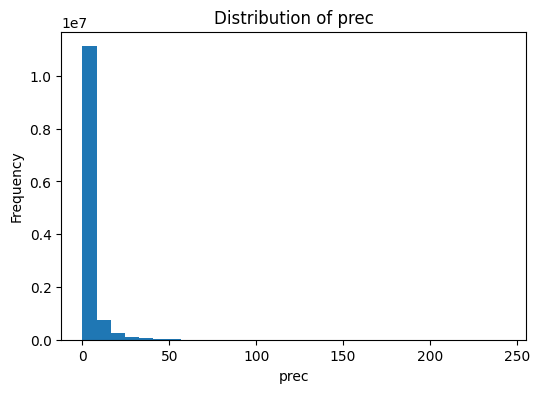

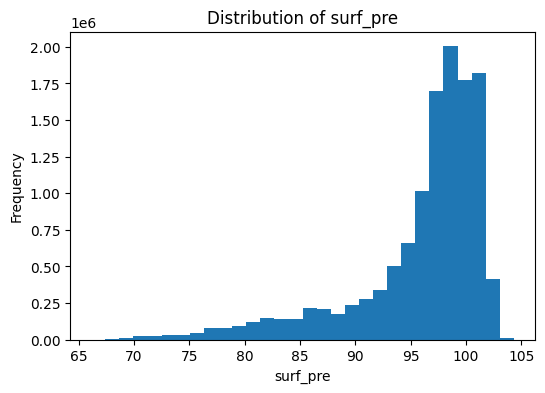

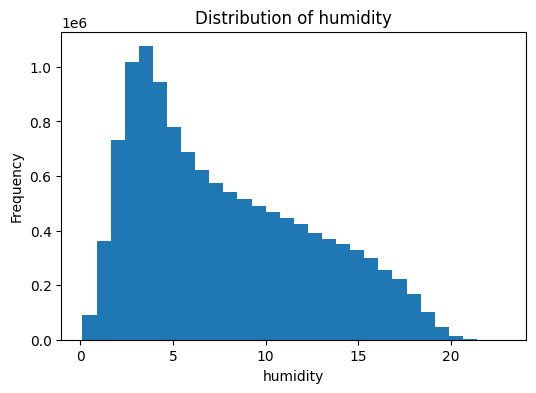

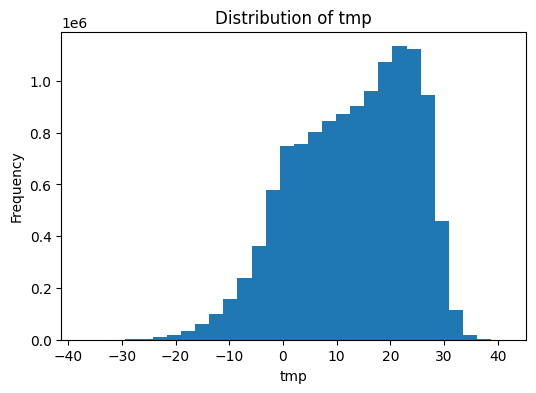

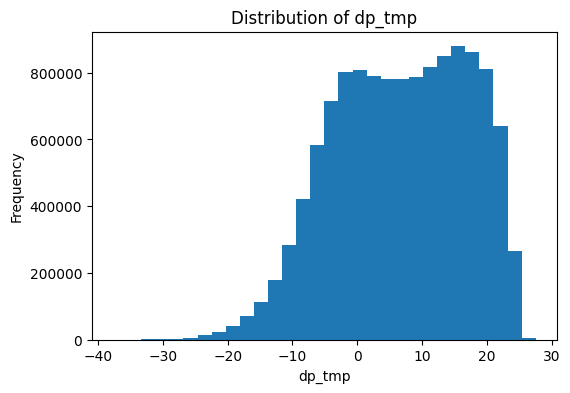

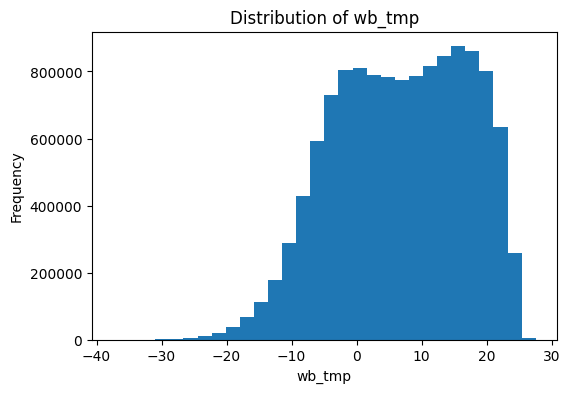

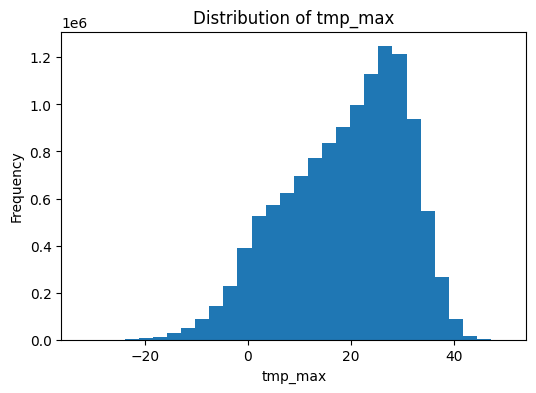

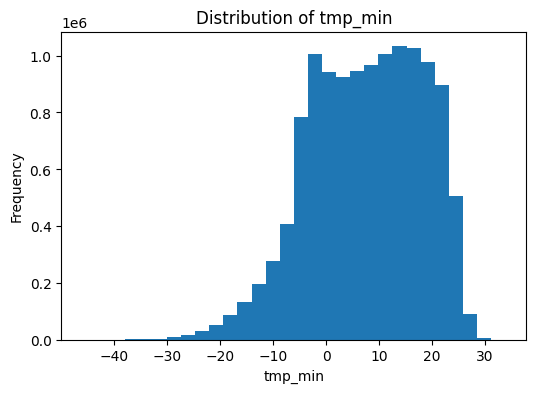

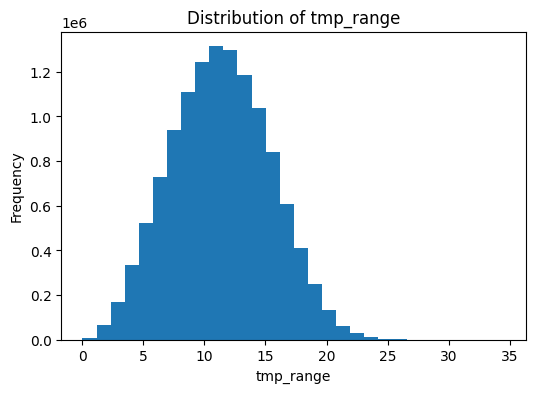

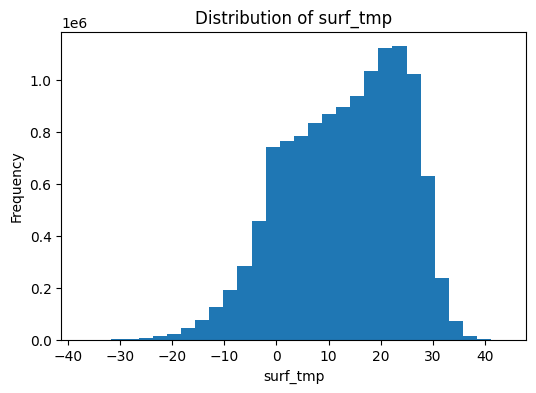

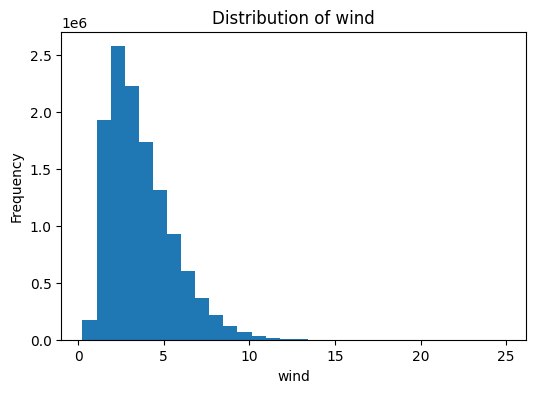

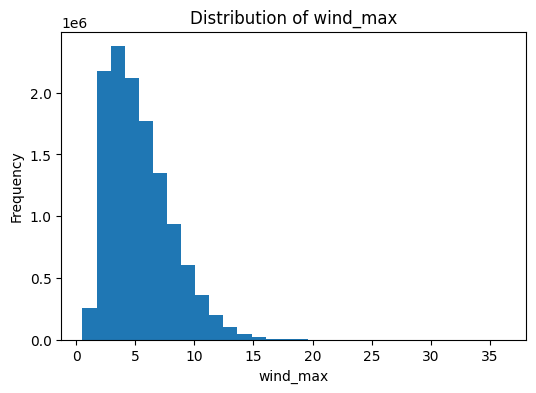

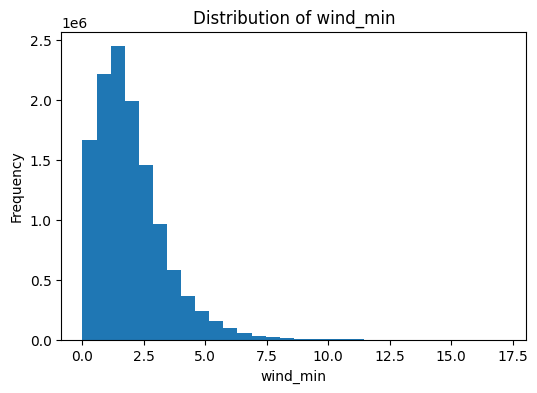

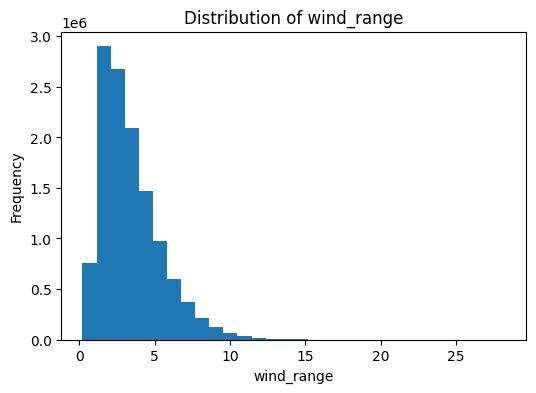

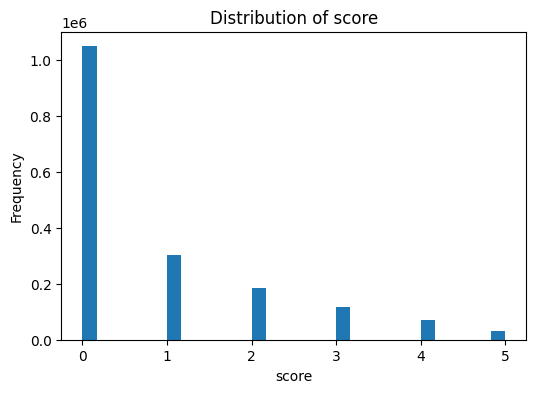

In [8]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## 8. Correlation Matrix

The correlation matrix gives a first view of linear relationships between numerical variables. However, drought is a temporal phenomenon, so weak daily correlations do not necessarily mean that a variable is useless. Rolling accumulations and trends can be more informative than raw daily values.


,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
prec,1.000000,0.079908,0.250843,0.096370,0.234087,0.234115,0.029204,0.149530,-0.309185,0.092360,0.057836,0.062826,0.037330,0.058231,-0.060676
surf_pre,0.079908,1.000000,0.318184,0.191335,0.379792,0.380226,0.133533,0.239834,-0.248570,0.190682,-0.081349,-0.143613,0.031541,-0.213759,-0.155524
humidity,0.250843,0.318184,1.000000,0.862800,0.958749,0.960273,0.793692,0.901626,-0.102267,0.854386,-0.209090,-0.244024,-0.094926,-0.260725,-0.052438
tmp,0.096370,0.191335,0.862800,1.000000,0.905690,0.906397,0.982924,0.981525,0.227889,0.997434,-0.187212,-0.198962,-0.113882,-0.187401,0.094285
dp_tmp,0.234087,0.379792,0.958749,0.905690,1.000000,0.999914,0.843636,0.934952,-0.047253,0.896861,-0.222965,-0.256969,-0.103238,-0.272294,-0.056445
wb_tmp,0.234115,0.380226,0.960273,0.906397,0.999914,1.000000,0.844239,0.935801,-0.047762,0.897617,-0.222755,-0.256794,-0.103150,-0.272121,-0.055573
tmp_max,0.029204,0.133533,0.793692,0.982924,0.843636,0.844239,1.000000,0.936709,0.394245,0.979773,-0.190429,-0.193338,-0.127612,-0.170407,0.133983
tmp_min,0.149530,0.239834,0.901626,0.981525,0.934952,0.935801,0.936709,1.000000,0.047541,0.978634,-0.190790,-0.210815,-0.103426,-0.210461,0.060863
tmp_range,-0.309185,-0.248570,-0.102267,0.227889,-0.047253,-0.047762,0.394245,0.047541,1.000000,0.226489,-0.042490,0.001773,-0.092594,0.066265,0.221477
surf_tmp,0.092360,0.190682,0.854386,0.997434,0.896861,0.897617,0.979773,0.978634,0.226489,1.000000,-0.169975,-0.181907,-0.100201,-0.174042,0.102556


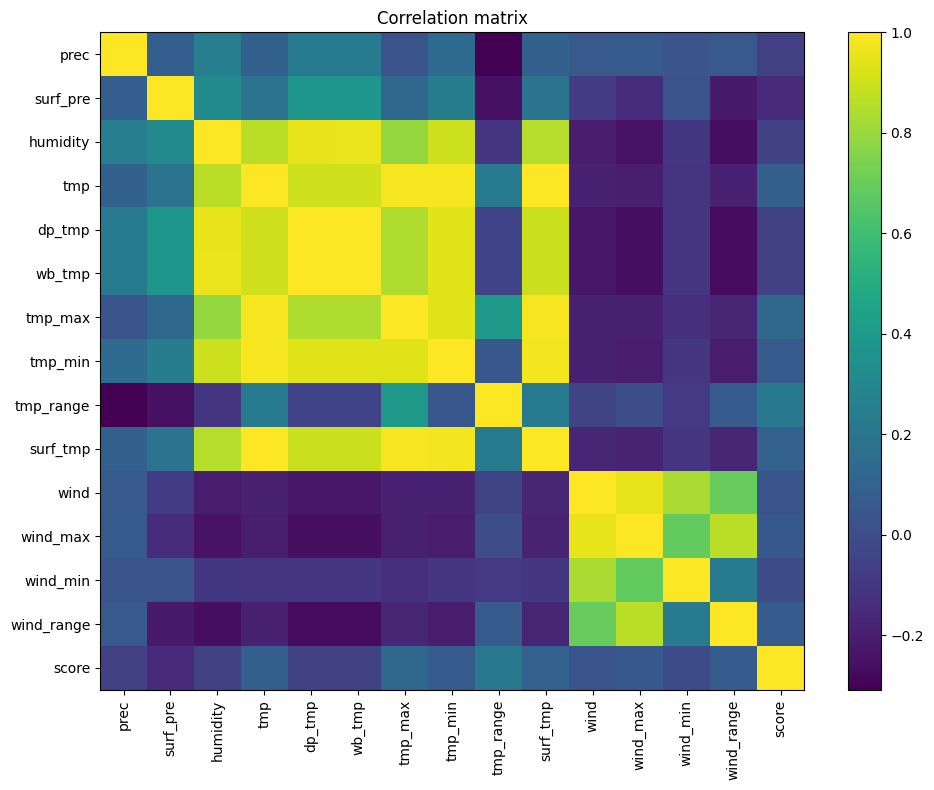

In [9]:
if len(numerical_cols) > 1:
    correlation_matrix = df[numerical_cols].corr()

    display(correlation_matrix)

    plt.figure(figsize=(10, 8))
    plt.imshow(correlation_matrix, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=90)
    plt.yticks(range(len(numerical_cols)), numerical_cols)
    plt.title("Correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns to compute correlations.")


## 9. Top Correlated Variable Pairs

This analysis identifies pairs of variables that contain similar information. Highly correlated variables may be redundant, but they can also reveal meaningful meteorological relationships, such as temperature-related variables moving together.


In [10]:
if len(numerical_cols) > 1:

    # Compute correlation matrix
    corr_matrix = df[numerical_cols].corr().abs()

    # Keep only upper triangle to avoid duplicates
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Convert to series and sort
    top_corr = (
        upper_triangle.stack()
        .sort_values(ascending=False)
        .head(10)
    )

    print("Top 10 most correlated variable pairs:")

    for i, ((var1, var2), corr_value) in enumerate(top_corr.items(), start=1):
        print(f"{i}. {var1} <-> {var2} : correlation = {corr_value:.4f}")

else:
    print("Not enough numerical columns to compute correlations.")


Top 10 most correlated variable pairs:
1. dp_tmp <-> wb_tmp : correlation = 0.9999
2. tmp <-> surf_tmp : correlation = 0.9974
3. tmp <-> tmp_max : correlation = 0.9829
4. tmp <-> tmp_min : correlation = 0.9815
5. tmp_max <-> surf_tmp : correlation = 0.9798
6. tmp_min <-> surf_tmp : correlation = 0.9786
7. humidity <-> wb_tmp : correlation = 0.9603
8. humidity <-> dp_tmp : correlation = 0.9587
9. wind <-> wind_max : correlation = 0.9508
10. tmp_max <-> tmp_min : correlation = 0.9367


## 10. Correlation with the Target Score

This cell ranks the variables according to their linear correlation with `score`. The objective is not to select features only from correlation values, but to identify useful directions for feature engineering. For example, if temperature range, pressure, precipitation or humidity show a relationship with drought severity, it makes sense to create rolling and trend-based features from them.


Variables most correlated with 'score':


,correlation_with_score
tmp_range,0.221477
surf_pre,-0.155524
tmp_max,0.133983
surf_tmp,0.102556
tmp,0.094285
wind_range,0.072626
tmp_min,0.060863
prec,-0.060676
dp_tmp,-0.056445
wb_tmp,-0.055573


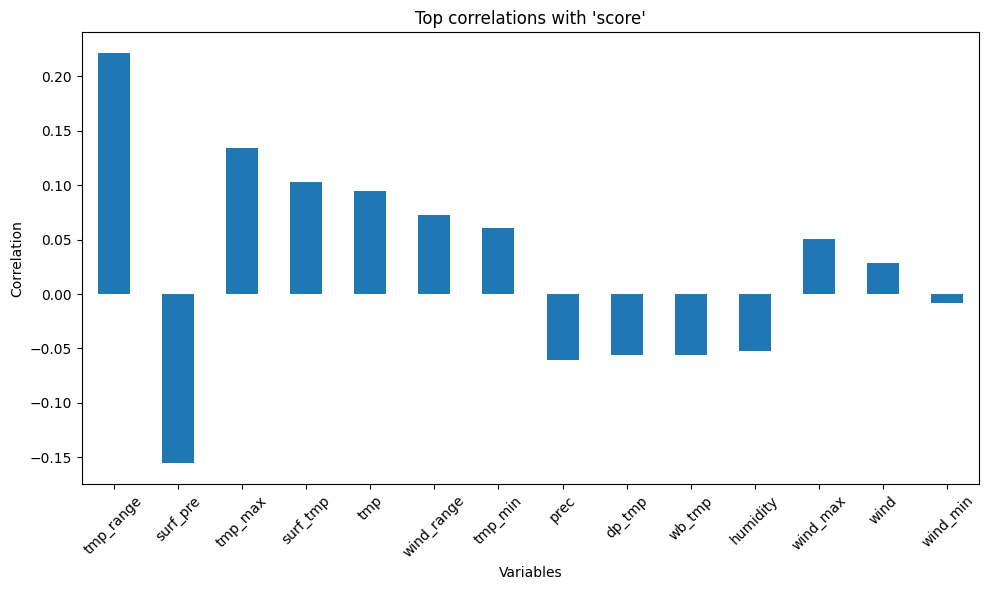

In [11]:
target_column = "score"

if target_column in df.columns:

    # Keep only numerical columns
    numerical_df = df.select_dtypes(include=["int64", "float64"])

    if target_column in numerical_df.columns:

        # Compute correlations with target
        target_corr = numerical_df.corr()[target_column]

        # Remove self-correlation
        target_corr = target_corr.drop(target_column)

        # Sort by absolute correlation value
        target_corr_sorted = target_corr.reindex(
            target_corr.abs().sort_values(ascending=False).index
        )

        print(f"Variables most correlated with '{target_column}':")

        display(target_corr_sorted.to_frame(name="correlation_with_score"))

        plt.figure(figsize=(10, 6))
        target_corr_sorted.head(15).plot(kind="bar")
        plt.title(f"Top correlations with '{target_column}'")
        plt.ylabel("Correlation")
        plt.xlabel("Variables")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print(f"'{target_column}' is not numerical.")

else:
    print(f"Column '{target_column}' not found in dataset.")


### Interpretation for Feature Engineering

The raw daily correlations with `score` are expected to be limited because drought severity is not determined by a single daily observation. Drought is usually linked to persistent conditions: low precipitation over several weeks, high temperatures, low humidity, and seasonal effects. Therefore, the next step is to create temporal features that summarize recent weather conditions before each weekly score.


# 11. Feature Engineering

The target score is observed weekly, while meteorological variables are available daily. We do not fill missing target values because they are not random missing values: they correspond to days where the score was not measured. Instead, we use all daily weather observations to create rolling statistics and then keep only the rows where `score` is available.


## 11.1 Date Handling and Temporal Order

The dates in this dataset use artificial years such as 3004 or 3005. These years are outside the normal range supported by pandas datetime, so we avoid `pd.to_datetime` for the full date. Since the format is `YYYY-MM-DD`, string sorting still preserves chronological order. We also extract year, month and day manually.


In [12]:
# Keep the original date as a string because years such as 3004 are out of pandas datetime range
if "date" not in df.columns:
    raise ValueError("The dataset must contain a 'date' column.")

# Extract date components manually from the YYYY-MM-DD string format
df["date_str"] = df["date"].astype(str)
df["year"] = df["date_str"].str.slice(0, 4).astype(int)
df["month"] = df["date_str"].str.slice(5, 7).astype(int)
df["day"] = df["date_str"].str.slice(8, 10).astype(int)

# Sort by region and date string. YYYY-MM-DD sorting is chronological.
df = df.sort_values(["region_id", "date_str"]).reset_index(drop=True)

# Create a sequential day index within each region
df["day_index_region"] = df.groupby("region_id").cumcount()

print("Date components created successfully.")
display(df[["region_id", "date", "year", "month", "day", "day_index_region"]].head())


Date components created successfully.


,region_id,date,year,month,day,day_index_region
0,R1,3004-12-31,3004,12,31,0
1,R1,3005-01-01,3005,1,1,1
2,R1,3005-01-02,3005,1,2,2
3,R1,3005-01-03,3005,1,3,3
4,R1,3005-01-04,3005,1,4,4


## 11.2 Meteorological Columns

We define the weather variables that will be used to build rolling features. The code automatically keeps only the variables that are present in the dataset, which makes the notebook more robust.


In [13]:
candidate_weather_cols = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp",
    "wind", "wind_max", "wind_min", "wind_range"
]

weather_cols = [col for col in candidate_weather_cols if col in df.columns]
print("Weather columns used for feature engineering:")
print(weather_cols)


Weather columns used for feature engineering:
['prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range']


## 11.3 Precipitation Features

Drought severity is strongly related to rainfall deficits accumulated over time. A single daily precipitation value can be noisy, while cumulative precipitation over 7, 14, 30 and 90 days better captures recent water availability.


In [14]:
if "prec" in df.columns:
    for window in [7, 14, 30, 90]:
        df[f"prec_sum_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    for window in [7, 14, 30]:
        df[f"prec_mean_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

    for window in [14, 30]:
        df[f"prec_std_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Precipitation features created.")
else:
    print("Column 'prec' not found. Precipitation features were skipped.")


Precipitation features created.


## 11.4 Dry Days Features

The number of consecutive or frequent dry days can be more informative than a single precipitation value. We create rolling counts of dry days, where a dry day is defined as a day with precipitation below 0.1.


In [15]:
if "prec" in df.columns:
    df["is_dry_day"] = (df["prec"] < 0.1).astype(int)

    for window in [7, 14, 30]:
        df[f"dry_days_{window}d"] = (
            df.groupby("region_id")["is_dry_day"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    print("Dry day features created.")


Dry day features created.


## 11.5 Temperature Features

High temperatures can increase evaporation and worsen drought conditions. Rolling temperature features capture persistent warm conditions, while temperature range features are included because the exploratory analysis suggested a relationship between `tmp_range` and the target score.


In [16]:
temperature_cols = [col for col in ["tmp", "tmp_max", "tmp_min", "surf_tmp", "tmp_range"] if col in df.columns]

for col in temperature_cols:
    for window in [7, 14, 30]:
        df[f"{col}_mean_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

for col in [c for c in ["tmp", "tmp_range"] if c in df.columns]:
    for window in [14, 30]:
        df[f"{col}_std_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

print("Temperature features created.")


Temperature features created.


## 11.6 Heatwave Features

Extreme heat may provide additional information beyond average temperature. We define hot days using a region-specific 90th percentile threshold, then count recent hot days over rolling windows.


In [17]:
if "tmp" in df.columns:
    df["tmp_90_region"] = (
        df.groupby("region_id")["tmp"]
        .transform(lambda x: x.quantile(0.90))
    )

    df["is_hot_day"] = (df["tmp"] > df["tmp_90_region"]).astype(int)

    for window in [7, 14, 30]:
        df[f"hot_days_{window}d"] = (
            df.groupby("region_id")["is_hot_day"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    print("Heatwave features created.")
else:
    print("Column 'tmp' not found. Heatwave features were skipped.")


Heatwave features created.


## 11.7 Humidity Features

Low humidity is directly related to dry atmospheric conditions. Rolling humidity means, minima and variability help describe whether the environment has been persistently dry.


In [18]:
if "humidity" in df.columns:
    for window in [7, 14, 30]:
        df[f"humidity_mean_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        df[f"humidity_min_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).min())
        )

    for window in [14, 30]:
        df[f"humidity_std_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Humidity features created.")
else:
    print("Column 'humidity' not found. Humidity features were skipped.")


Humidity features created.


## 11.8 Surface Pressure Features

Surface pressure showed a noticeable relationship with the target during the exploratory analysis. Rolling pressure statistics may capture stable weather patterns that can be associated with reduced rainfall.


In [19]:
if "surf_pre" in df.columns:
    for window in [7, 14, 30]:
        df[f"surf_pre_mean_{window}d"] = (
            df.groupby("region_id")["surf_pre"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

    for window in [14, 30]:
        df[f"surf_pre_std_{window}d"] = (
            df.groupby("region_id")["surf_pre"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Surface pressure features created.")
else:
    print("Column 'surf_pre' not found. Pressure features were skipped.")


Surface pressure features created.


## 11.9 Wind Features

Wind can influence evaporation and surface drying. Even if wind variables are not the strongest individual predictors, they may still add complementary information when combined with temperature, humidity and precipitation.


In [20]:
wind_cols = [col for col in ["wind", "wind_max", "wind_min", "wind_range"] if col in df.columns]

for col in wind_cols:
    for window in [7, 14, 30]:
        df[f"{col}_mean_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

if "wind" in df.columns:
    for window in [14, 30]:
        df[f"wind_std_{window}d"] = (
            df.groupby("region_id")["wind"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

print("Wind features created.")


Wind features created.


## 11.10 Seasonal Features

Drought severity is seasonal. The same meteorological value may have different meaning depending on the time of year. We therefore add month-based and yearly cycle features using sine and cosine encodings.


In [21]:
# Month is already extracted from the date string
# Create a day-of-year approximation using a reference leap year to support February 29 if present
ref_dates = pd.to_datetime(
    "2004-" + df["month"].astype(str).str.zfill(2) + "-" + df["day"].astype(str).str.zfill(2),
    errors="coerce"
)

df["day_of_year"] = ref_dates.dt.dayofyear.fillna(df["day_index_region"] % 365 + 1).astype(int)
df["week_of_year"] = ((df["day_of_year"] - 1) // 7 + 1).astype(int)

# Cyclical encoding of the yearly seasonality
df["sin_dayofyear"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["cos_dayofyear"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

display(df[["date", "month", "day", "day_of_year", "week_of_year", "sin_dayofyear", "cos_dayofyear"]].head())


,date,month,day,day_of_year,week_of_year,sin_dayofyear,cos_dayofyear
0,3004-12-31,12,31,366,53,0.012901,0.999917
1,3005-01-01,1,1,1,1,0.017202,0.999852
2,3005-01-02,1,2,2,1,0.034398,0.999408
3,3005-01-03,1,3,3,1,0.051584,0.998669
4,3005-01-04,1,4,4,1,0.068755,0.997634


## 11.11 Trend Features

Drought can develop progressively. Trend features compare short-term conditions with longer-term conditions. For example, if the last 7 days are hotter than the last 30 days, this may indicate a recent worsening of drought-related conditions.


In [22]:
if {"tmp_mean_7d", "tmp_mean_30d"}.issubset(df.columns):
    df["tmp_trend_7_30"] = df["tmp_mean_7d"] - df["tmp_mean_30d"]

if {"humidity_mean_7d", "humidity_mean_30d"}.issubset(df.columns):
    df["humidity_trend_7_30"] = df["humidity_mean_7d"] - df["humidity_mean_30d"]

if {"prec_sum_7d", "prec_sum_30d"}.issubset(df.columns):
    df["prec_trend_7_30"] = df["prec_sum_7d"] - (df["prec_sum_30d"] / 30 * 7)

if {"surf_pre_mean_7d", "surf_pre_mean_30d"}.issubset(df.columns):
    df["surf_pre_trend_7_30"] = df["surf_pre_mean_7d"] - df["surf_pre_mean_30d"]

print("Trend features created.")


Trend features created.


## 11.12 Drought Interaction Features

Drought is not caused by one variable alone. It often results from the combination of low rainfall, high temperature and low humidity. Interaction features help tree-based models capture these combined effects more directly.


In [23]:
epsilon = 1e-6

if {"tmp_mean_30d", "prec_sum_30d"}.issubset(df.columns):
    df["temp_prec_ratio_30d"] = df["tmp_mean_30d"] / (df["prec_sum_30d"] + 1)

if {"hot_days_30d", "dry_days_30d"}.issubset(df.columns):
    df["dry_hot_interaction_30d"] = df["hot_days_30d"] * df["dry_days_30d"]

if {"dry_days_30d", "humidity_mean_30d"}.issubset(df.columns):
    df["dry_humidity_interaction_30d"] = df["dry_days_30d"] / (df["humidity_mean_30d"] + epsilon)

if {"tmp_mean_30d", "humidity_mean_30d", "prec_sum_30d"}.issubset(df.columns):
    df["simple_drought_index_30d"] = (
        df["tmp_mean_30d"]
        * (1 / (df["humidity_mean_30d"] + epsilon))
        * (1 / (df["prec_sum_30d"] + 1))
    )

print("Interaction features created.")


Interaction features created.


## 11.13 Score Lag Features

Drought severity usually evolves slowly. Therefore, previous weekly drought scores are likely to be informative for future scores. These lag features are created only from previous observed weekly scores within the same region, which avoids using future information.


In [24]:
if "score" not in df.columns:
    raise ValueError("The dataset must contain a 'score' column.")

# Work only with valid weekly score rows to create weekly score lags
score_df = df[df["score"].notna()].copy()
score_df = score_df.sort_values(["region_id", "date_str"])

for lag in [1, 2, 3, 4, 5]:
    score_df[f"score_lag_{lag}w"] = (
        score_df.groupby("region_id")["score"].shift(lag)
    )

lag_cols = [f"score_lag_{lag}w" for lag in [1, 2, 3, 4, 5]]

df = df.merge(
    score_df[["region_id", "date_str"] + lag_cols],
    on=["region_id", "date_str"],
    how="left"
)

print("Score lag features created.")
display(df[["region_id", "date", "score"] + lag_cols].dropna(subset=["score"]).head(10))


Score lag features created.


,region_id,date,score,score_lag_1w,score_lag_2w,score_lag_3w,score_lag_4w,score_lag_5w
6,R1,3005-01-06,0.0,NaN,NaN,NaN,NaN,NaN
13,R1,3005-01-13,0.0,0.0,NaN,NaN,NaN,NaN
20,R1,3005-01-20,0.0,0.0,0.0,NaN,NaN,NaN
27,R1,3005-01-27,0.0,0.0,0.0,0.0,NaN,NaN
34,R1,3005-02-03,0.0,0.0,0.0,0.0,0.0,NaN
41,R1,3005-02-10,0.0,0.0,0.0,0.0,0.0,0.0
48,R1,3005-02-17,0.0,0.0,0.0,0.0,0.0,0.0
55,R1,3005-02-24,0.0,0.0,0.0,0.0,0.0,0.0
62,R1,3005-03-02,0.0,0.0,0.0,0.0,0.0,0.0
69,R1,3005-03-09,0.0,0.0,0.0,0.0,0.0,0.0


## 11.14 Final Weekly Training Dataset

After creating temporal features from the daily meteorological data, we -do not- keep only the rows where the weekly target score is available. This gives (no) one training sample per region and per week (it no longer does), while preserving information from previous daily observations through the engineered features.


In [25]:
# Keep only rows where the weekly target score exists
# weekly_df = df[df["score"].notna()].copy()

# NO THIS IS NOT HAPPENING I need THESE ENTRIES FOR THE TRANSFORMER.
# copying the dataframe to the one i shall be using instead

tft_df = df.copy()

# Keep only rows where the weekly target score exists
weekly_df = df[df["score"].notna()].copy()

# Helper columns were useful to build features but should not necessarily be used directly
helper_cols = ["is_dry_day", "tmp_90_region", "is_hot_day", "date_str"]
weekly_df = weekly_df.drop(columns=[col for col in helper_cols if col in weekly_df.columns])

weekly_df = weekly_df.reset_index(drop=True)

print("Original daily dataset shape:", df.shape)
print("Final weekly dataset shape:", weekly_df.shape)
print("Remaining missing values in target score:", weekly_df["score"].isna().sum())

display(weekly_df.head())


Original daily dataset shape: (12319040, 103)
Final weekly dataset shape: (1757936, 99)
Remaining missing values in target score: 0


,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,...,surf_pre_trend_7_30,temp_prec_ratio_30d,dry_hot_interaction_30d,dry_humidity_interaction_30d,simple_drought_index_30d,score_lag_1w,score_lag_2w,score_lag_3w,score_lag_4w,score_lag_5w
0,R1,3005-01-06,0.01,101.59,2.80,1.32,-3.97,-3.90,6.66,-4.29,...,0.000000,0.577406,0.0,0.654450,0.075577,NaN,NaN,NaN,NaN,NaN
1,R1,3005-01-13,0.00,101.06,6.16,7.83,6.80,6.80,15.79,2.86,...,0.204286,0.226662,0.0,1.773499,0.040198,0.0,NaN,NaN,NaN,NaN
2,R1,3005-01-20,0.15,100.69,2.63,-0.33,-4.86,-4.80,8.08,-5.89,...,-0.612381,0.149059,0.0,2.351016,0.026957,0.0,0.0,NaN,NaN,NaN
3,R1,3005-01-27,0.09,100.29,3.70,4.39,-1.33,-1.26,9.54,-2.59,...,-0.370357,0.098239,0.0,3.049131,0.017620,0.0,0.0,0.0,NaN,NaN
4,R1,3005-02-03,0.22,100.74,4.33,5.20,1.61,1.63,11.00,-0.69,...,-0.059190,0.075215,0.0,3.835226,0.016026,0.0,0.0,0.0,0.0,NaN


## 11.15 Check the Engineered Dataset

This final verification checks the number of generated features and the remaining missing values. Some NaN values may appear in lag features for the first weeks of each region because no previous score exists yet. These can be handled later during model training by dropping early rows, imputing lag values, or using models that support missing values.


In [26]:
print("Number of columns before feature engineering:", len(pd.read_csv(csv_path, nrows=1).columns))
print("Number of columns after feature engineering:", weekly_df.shape[1])

missing_after_fe = weekly_df.isna().sum()
missing_after_fe = missing_after_fe[missing_after_fe > 0].sort_values(ascending=False)

if missing_after_fe.empty:
    print("No missing values remain in the weekly dataset.")
else:
    print("Columns with remaining missing values after feature engineering:")
    display(missing_after_fe.to_frame(name="missing_count"))


Number of columns before feature engineering: 17
Number of columns after feature engineering: 99
Columns with remaining missing values after feature engineering:


,missing_count
score_lag_5w,11240
score_lag_4w,8992
score_lag_3w,6744
score_lag_2w,4496
score_lag_1w,2248


## Feature Engineering Summary

The final engineered dataset uses daily weather observations to build weekly predictors. This avoids filling missing target values and preserves useful meteorological information through rolling sums, rolling means, variability measures, dry-day counts, seasonal encodings, trend features, interaction features and previous-score lags.

This dataset is now ready for the next step: defining a validation strategy and training baseline models for the five prediction horizons.


In [27]:
corr_with_score = (
    weekly_df.corr(numeric_only=True)["score"]
    .drop("score")
    .sort_values(key=abs, ascending=False)
)

print(corr_with_score.head(20))

score_lag_1w               0.969958
score_lag_2w               0.940034
score_lag_3w               0.910728
score_lag_4w               0.881840
score_lag_5w               0.853604
prec_sum_90d              -0.398549
tmp_range_mean_30d         0.352095
tmp_range_mean_14d         0.326649
prec_mean_30d             -0.305958
prec_sum_30d              -0.305386
tmp_range_mean_7d          0.298688
prec_std_30d              -0.271997
dry_days_30d               0.260904
prec_mean_14d             -0.221785
prec_sum_14d              -0.221672
tmp_range                  0.221477
dry_hot_interaction_30d    0.213805
dry_days_14d               0.207656
prec_std_14d              -0.201990
temp_prec_ratio_30d        0.178810
Name: score, dtype: float64


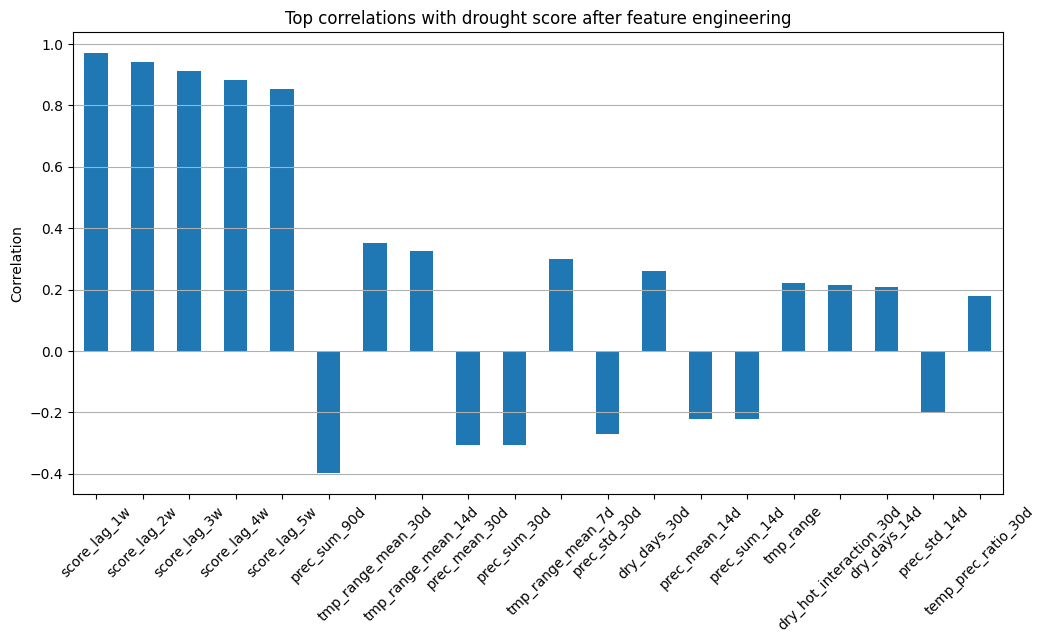

In [28]:
import matplotlib.pyplot as plt

top_corr = corr_with_score.head(20)

plt.figure(figsize=(12,6))
top_corr.plot(kind="bar")
plt.title("Top correlations with drought score after feature engineering")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

### Interpretation
The engineered temporal features showed stronger correlations with the drought score than the original daily meteorological variables, suggesting that aggregated temporal patterns are more informative for drought prediction than instantaneous observations.

# Final dataset rework for TFT

In [29]:
cols_to_drop = [
    'prec_sum_7d', 'prec_sum_14d', 'prec_sum_30d', 'prec_sum_90d',
    'prec_mean_7d', 'prec_mean_14d', 'prec_mean_30d', 'prec_std_14d', 'prec_std_30d',
    'dry_days_7d', 'dry_days_14d', 'dry_days_30d',
    'tmp_mean_7d', 'tmp_mean_14d', 'tmp_mean_30d',
    'tmp_max_mean_7d', 'tmp_max_mean_14d', 'tmp_max_mean_30d',
    'tmp_min_mean_7d', 'tmp_min_mean_14d', 'tmp_min_mean_30d',
    'surf_tmp_mean_7d', 'surf_tmp_mean_14d', 'surf_tmp_mean_30d',
    'tmp_range_mean_7d', 'tmp_range_mean_14d', 'tmp_range_mean_30d',
    'tmp_std_14d', 'tmp_std_30d', 'tmp_range_std_14d', 'tmp_range_std_30d',
    'hot_days_7d', 'hot_days_14d', 'hot_days_30d',
    'humidity_mean_7d', 'humidity_min_7d', 'humidity_mean_14d', 'humidity_min_14d',
    'humidity_mean_30d', 'humidity_min_30d', 'humidity_std_14d', 'humidity_std_30d',
    'surf_pre_mean_7d', 'surf_pre_mean_14d', 'surf_pre_mean_30d',
    'surf_pre_std_14d', 'surf_pre_std_30d',
    'wind_mean_7d', 'wind_mean_14d', 'wind_mean_30d',
    'wind_max_mean_7d', 'wind_max_mean_14d', 'wind_max_mean_30d',
    'wind_min_mean_7d', 'wind_min_mean_14d', 'wind_min_mean_30d',
    'wind_range_mean_7d', 'wind_range_mean_14d', 'wind_range_mean_30d',
    'wind_std_14d', 'wind_std_30d',
    'tmp_trend_7_30', 'humidity_trend_7_30', 'prec_trend_7_30', 'surf_pre_trend_7_30',
    'temp_prec_ratio_30d', 'dry_hot_interaction_30d', 'dry_humidity_interaction_30d',
    'simple_drought_index_30d',
    'score_lag_1w', 'score_lag_2w', 'score_lag_3w', 'score_lag_4w', 'score_lag_5w'
]

tft_df = tft_df.drop(columns=cols_to_drop, errors='ignore')

features = tft_df.columns.tolist()
print(f"Total features: {len(features)}")
print('\n'.join(features))

Total features: 29
region_id
date
prec
surf_pre
humidity
tmp
dp_tmp
wb_tmp
tmp_max
tmp_min
tmp_range
surf_tmp
wind
wind_max
wind_min
wind_range
score
date_str
year
month
day
day_index_region
is_dry_day
tmp_90_region
is_hot_day
day_of_year
week_of_year
sin_dayofyear
cos_dayofyear


In [30]:
import numpy as np

# Vapor pressure deficit (vpd)
e_s = 0.611 * np.exp((17.27 * tft_df['tmp']) / (tft_df['tmp'] + 237.3))
e_a = 0.611 * np.exp((17.27 * tft_df['dp_tmp']) / (tft_df['dp_tmp'] + 237.3))
tft_df['vpd'] = e_s - e_a

# precipitation is now log precipitation
tft_df['prec'] = np.log1p(tft_df['prec']) # np.log1p is ln(1+x)

# Month cyclical features
tft_df['sin_month'] = np.sin((2 * np.pi * tft_df['month']) / 12)
tft_df['cos_month'] = np.cos((2 * np.pi * tft_df['month']) / 12)

# Remove features
cols_to_drop_date = ['year', 'month', 'day', 'day_of_year', 'week_of_year', 'date', 'is_hot_day', 'is_dry_day', 'date_str', 'tmp_90_region']
tft_df = tft_df.drop(columns=cols_to_drop_date, errors='ignore')

In [31]:
features = tft_df.columns.tolist()
print(f"Dataset shape after updates: {tft_df.shape}")
print(f"Total features: {len(features)}")
print('\n'.join(features))

Dataset shape after updates: (12319040, 22)
Total features: 22
region_id
prec
surf_pre
humidity
tmp
dp_tmp
wb_tmp
tmp_max
tmp_min
tmp_range
surf_tmp
wind
wind_max
wind_min
wind_range
score
day_index_region
sin_dayofyear
cos_dayofyear
vpd
sin_month
cos_month


In [32]:
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm  # <--- Import this

# 1. Sort strictly by region_id and the engineered continuous integer time index
tft_df = tft_df.sort_values(by=['region_id', 'day_index_region']).reset_index(drop=True)

# 2. Identify continuous features to scale
continuous_features = [
    'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp',
    'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp',
    'wind', 'wind_max', 'wind_min', 'wind_range',
    'vpd', 'sin_month', 'cos_month', 'prec'
]
continuous_features = [c for c in continuous_features if c in tft_df.columns]

# 3. Foolproof Imputation & Scaling Loop
scaler = StandardScaler()

print("Imputing and scaling regions safely...")
for region, group_indices in tqdm(tft_df.groupby('region_id').groups.items()):
    
    # Extract the features for this specific region
    subset = tft_df.loc[group_indices, continuous_features]
    
    # Apply forward and backward fill (with a safety net of 0 if a feature is 100% empty)
    subset = subset.ffill().bfill().fillna(0)
    
    # Fit the scaler and overwrite the original DataFrame rows directly
    tft_df.loc[group_indices, continuous_features] = scaler.fit_transform(subset)

# Verification
remaining_nans = tft_df.isna().sum().sum()
print(f"Sequence Imputation and Scaling complete.")
print(f"Remaining NaN values in dataset: {remaining_nans}")
display(tft_df.head())

Imputing and scaling regions safely...


  0%|          | 0/2248 [00:00<?, ?it/s]

Sequence Imputation and Scaling complete.
Remaining NaN values in dataset: 10561104


,region_id,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,...,wind_max,wind_min,wind_range,score,day_index_region,sin_dayofyear,cos_dayofyear,vpd,sin_month,cos_month
0,R1,-0.751231,1.969728,-1.418740,-1.391809,-1.595757,-1.596777,-1.070244,-1.650483,1.617052,...,-0.340019,-1.554170,0.771412,NaN,0,0.012901,0.999917,-0.597244,0.006722,1.414025
1,R1,-0.751231,1.949908,-1.078849,-1.046442,-1.017278,-1.019088,-0.785976,-1.246684,1.279739,...,-0.526333,-0.027643,-0.701028,NaN,1,0.017202,0.999852,-0.679285,0.715236,1.224927
2,R1,-0.741920,1.057985,-0.244955,-0.540219,-0.020533,-0.020705,-0.774181,-0.433334,-0.857600,...,-0.423860,0.313390,-0.857394,NaN,2,0.034398,0.999408,-1.227471,0.715236,1.224927
3,R1,-0.732701,0.463370,0.194158,-0.194852,0.387949,0.388951,-0.554787,0.206302,-1.992198,...,-0.256177,0.881778,-1.065881,NaN,3,0.051584,0.998669,-1.319570,0.715236,1.224927
4,R1,0.254721,-0.230348,0.363048,0.038152,0.505357,0.506696,-0.128975,0.263824,-1.038522,...,1.215707,1.515124,0.471712,NaN,4,0.068755,0.997634,-1.043111,0.715236,1.224927


In [33]:
features = tft_df.columns.tolist()
print(f"Dataset shape after updates: {tft_df.shape}")
print(f"Total features: {len(features)}")
print('\n'.join(features))

Dataset shape after updates: (12319040, 22)
Total features: 22
region_id
prec
surf_pre
humidity
tmp
dp_tmp
wb_tmp
tmp_max
tmp_min
tmp_range
surf_tmp
wind
wind_max
wind_min
wind_range
score
day_index_region
sin_dayofyear
cos_dayofyear
vpd
sin_month
cos_month


In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm  # <--- Added the safe progress bar

# Load test data
test_df = pd.read_csv(csv_test_path)

# Add an empty score column if it doesn't exist
if 'score' not in test_df.columns:
    test_df['score'] = np.nan

# Date handling
test_df["date_str"] = test_df["date"].astype(str)
test_df["year"] = test_df["date_str"].str.slice(0, 4).astype(int)
test_df["month"] = test_df["date_str"].str.slice(5, 7).astype(int)
test_df["day"] = test_df["date_str"].str.slice(8, 10).astype(int)

# Sort chronologically by region
test_df = test_df.sort_values(["region_id", "date_str"]).reset_index(drop=True)

# Sequential day index
test_df["day_index_region"] = test_df.groupby("region_id").cumcount()

# Day of year
ref_dates = pd.to_datetime(
    "2004-" + test_df["month"].astype(str).str.zfill(2) + "-" + test_df["day"].astype(str).str.zfill(2),
    errors="coerce"
)
test_df["day_of_year"] = ref_dates.dt.dayofyear.fillna(test_df["day_index_region"] % 365 + 1).astype(int)

# Cyclical day of year
test_df["sin_dayofyear"] = np.sin(2 * np.pi * test_df["day_of_year"] / 365.25)
test_df["cos_dayofyear"] = np.cos(2 * np.pi * test_df["day_of_year"] / 365.25)

# Vapor pressure deficit (vpd)
e_s = 0.611 * np.exp((17.27 * test_df['tmp']) / (test_df['tmp'] + 237.3))
e_a = 0.611 * np.exp((17.27 * test_df['dp_tmp']) / (test_df['dp_tmp'] + 237.3))
test_df['vpd'] = e_s - e_a

# Log precipitation
test_df['prec'] = np.log1p(test_df['prec'])

# Cyclical month
test_df['sin_month'] = np.sin((2 * np.pi * test_df['month']) / 12)
test_df['cos_month'] = np.cos((2 * np.pi * test_df['month']) / 12)

# Keep only the final 22 features
final_cols = [
    'region_id', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp',
    'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max',
    'wind_min', 'wind_range', 'score', 'day_index_region', 'sin_dayofyear',
    'cos_dayofyear', 'vpd', 'sin_month', 'cos_month'
]
test_df = test_df[final_cols]

# ==========================================
# FOOLPROOF IMPUTATION & SCALING
# ==========================================
continuous_features = [
    'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp',
    'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp',
    'wind', 'wind_max', 'wind_min', 'wind_range',
    'vpd', 'sin_month', 'cos_month', 'prec'
]
continuous_features = [c for c in continuous_features if c in test_df.columns]

scaler = StandardScaler()

# 1. Sort strictly by region_id and the engineered continuous integer time index
test_df = test_df.sort_values(by=['region_id', 'day_index_region']).reset_index(drop=True)

print("Imputing and scaling Test regions safely...")
# 2. Iterate safely using .loc and tqdm for the progress bar
for region, group_indices in tqdm(test_df.groupby('region_id').groups.items()):
    
    # Extract the features for this specific region
    subset = test_df.loc[group_indices, continuous_features]
    
    # Apply forward and backward fill (with a safety net of 0)
    subset = subset.ffill().bfill().fillna(0)
    
    # Fit the scaler and overwrite the original DataFrame rows directly
    test_df.loc[group_indices, continuous_features] = scaler.fit_transform(subset)

print(f"Test dataset shape after updates: {test_df.shape}")
print(f"Total features: {len(test_df.columns)}")
display(test_df.head())

Imputing and scaling Test regions safely...


  0%|          | 0/2248 [00:00<?, ?it/s]

Test dataset shape after updates: (204568, 22)
Total features: 22


,region_id,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,...,wind_max,wind_min,wind_range,score,day_index_region,sin_dayofyear,cos_dayofyear,vpd,sin_month,cos_month
0,R1,-0.679391,-0.828610,1.487245,1.729393,1.298509,1.302732,1.850188,1.575647,0.910885,...,0.772888,-1.228914,2.139409,NaN,0,-0.978989,-0.203914,2.062135,-1.158971,-1.971666
1,R1,-0.679391,0.134488,1.190481,1.359034,1.120987,1.118203,1.296846,1.460971,-0.246891,...,1.238800,1.045147,0.781291,NaN,1,-0.982352,-0.187043,1.287649,-1.158971,-1.971666
2,R1,-0.679391,0.980135,0.006423,1.026212,0.186995,0.214648,1.098796,1.071577,0.200574,...,0.356542,0.998737,-0.386691,NaN,2,-0.985424,-0.170118,1.459272,-1.158971,-1.971666
3,R1,-0.679391,1.050605,0.507025,1.090024,0.630001,0.640973,1.212825,0.997227,0.685588,...,0.148368,0.673871,-0.386691,NaN,3,-0.988204,-0.153142,1.190316,-1.158971,-1.971666
4,R1,-0.679391,0.533821,0.429087,1.120053,0.558033,0.582115,1.274040,0.931698,1.011017,...,-0.694238,0.256187,-1.174399,NaN,4,-0.990692,-0.136120,1.328309,-1.158971,-1.971666


In [35]:
print("--- Column Alignment Check ---")
train_cols = set(tft_df.columns)
test_cols = set(test_df.columns)

print("Columns in Train but not Test:", train_cols - test_cols)
print("Columns in Test but not Train:", test_cols - train_cols)

print("\n--- Feature Distribution Comparison ---")
# Select a subset of representative features to display distributions side-by-side
features_to_compare = ['prec', 'tmp', 'humidity', 'vpd', 'sin_month']

print("\nTrain (tft_df) Statistics:")
display(tft_df[features_to_compare].describe())

print("\nTest (test_df) Statistics:")
display(test_df[features_to_compare].describe())


--- Column Alignment Check ---
Columns in Train but not Test: set()
Columns in Test but not Train: set()

--- Feature Distribution Comparison ---

Train (tft_df) Statistics:


,prec,tmp,humidity,vpd,sin_month
count,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07
mean,2.797692e-18,4.365103e-18,-2.239076e-18,7.186731e-19,-1.803696e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.214873e+00,-5.286827e+00,-3.563163e+00,-3.161308e+00,-1.722829e+00
25%,-6.888623e-01,-8.015719e-01,-8.405149e-01,-7.793380e-01,-1.220460e+00
50%,-5.183119e-01,6.617519e-02,-1.521047e-01,-3.054488e-01,5.804407e-01
75%,4.841854e-01,8.872202e-01,7.997022e-01,5.380230e-01,5.804407e-01
max,1.061622e+01,4.313718e+00,5.827581e+00,8.998652e+00,1.423750e+00



Test (test_df) Statistics:


,prec,tmp,humidity,vpd,sin_month
count,2.045680e+05,2.045680e+05,2.045680e+05,2.045680e+05,2.045680e+05
mean,4.298310e-18,-2.691871e-18,1.220894e-17,-1.172266e-18,-1.864338e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,7.945004e-01
min,-1.588979e+00,-5.681990e+00,-4.337082e+00,-3.328630e+00,-9.486833e+00
25%,-6.516612e-01,-6.567923e-01,-7.491021e-01,-7.617088e-01,-2.656845e-01
50%,-4.601909e-01,1.597921e-01,2.104127e-02,-8.638561e-02,0.000000e+00
75%,3.912846e-01,7.572108e-01,7.411964e-01,6.834225e-01,5.307449e-01
max,9.371752e+00,3.344298e+00,5.022596e+00,5.468676e+00,5.343458e+00


In [36]:
# Count entries per region in the processed dataset (tft_df)
region_counts = tft_df['region_id'].value_counts()

# Convert to a list of tuples: [(region, count), ...]
region_counts_list = list(region_counts.items())

print(f"Total unique regions: {len(region_counts_list)}")
print("\nList of entries per region (first 20 shown):")
for region, count in region_counts_list[:20]:
    print(f"Region: {region} -> {count} entries")


Total unique regions: 2248

List of entries per region (first 20 shown):
Region: R1 -> 5480 entries
Region: R1001 -> 5480 entries
Region: R1002 -> 5480 entries
Region: R1005 -> 5480 entries
Region: R1006 -> 5480 entries
Region: R1007 -> 5480 entries
Region: R1009 -> 5480 entries
Region: R1011 -> 5480 entries
Region: R1012 -> 5480 entries
Region: R1014 -> 5480 entries
Region: R1015 -> 5480 entries
Region: R1017 -> 5480 entries
Region: R1019 -> 5480 entries
Region: R1020 -> 5480 entries
Region: R1021 -> 5480 entries
Region: R1022 -> 5480 entries
Region: R1024 -> 5480 entries
Region: R1025 -> 5480 entries
Region: R1026 -> 5480 entries
Region: R1028 -> 5480 entries


# TFT IMPLEMENTATION, architecture and training

In [37]:
%pip install -q pytorch-lightning pytorch-forecasting

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters


Note: you may need to restart the kernel to use updated packages.


In [38]:
# ==========================================
# TARGET VARIABLE INTERPOLATION
# ==========================================
print(f"Missing scores before interpolation: {tft_df['score'].isna().sum()}")

# 1. Ensure the dataframe is strictly chronological per region to prevent cross-contamination
tft_df = tft_df.sort_values(by=['region_id', 'day_index_region']).reset_index(drop=True)

# 2. Linearly interpolate the weekly drought scores to create a smooth daily target
print("Applying linear interpolation to weekly drought scores...")
tft_df['score'] = tft_df.groupby('region_id')['score'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

print(f"Missing scores after interpolation: {tft_df['score'].isna().sum()}")

# Brief visual verification
display(tft_df.head(10))

Missing scores before interpolation: 10561104
Applying linear interpolation to weekly drought scores...
Missing scores after interpolation: 0


,region_id,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,...,wind_max,wind_min,wind_range,score,day_index_region,sin_dayofyear,cos_dayofyear,vpd,sin_month,cos_month
0,R1,-0.751231,1.969728,-1.418740,-1.391809,-1.595757,-1.596777,-1.070244,-1.650483,1.617052,...,-0.340019,-1.554170,0.771412,0.0,0,0.012901,0.999917,-0.597244,0.006722,1.414025
1,R1,-0.751231,1.949908,-1.078849,-1.046442,-1.017278,-1.019088,-0.785976,-1.246684,1.279739,...,-0.526333,-0.027643,-0.701028,0.0,1,0.017202,0.999852,-0.679285,0.715236,1.224927
2,R1,-0.741920,1.057985,-0.244955,-0.540219,-0.020533,-0.020705,-0.774181,-0.433334,-0.857600,...,-0.423860,0.313390,-0.857394,0.0,2,0.034398,0.999408,-1.227471,0.715236,1.224927
3,R1,-0.732701,0.463370,0.194158,-0.194852,0.387949,0.388951,-0.554787,0.206302,-1.992198,...,-0.256177,0.881778,-1.065881,0.0,3,0.051584,0.998669,-1.319570,0.715236,1.224927
4,R1,0.254721,-0.230348,0.363048,0.038152,0.505357,0.506696,-0.128975,0.263824,-1.038522,...,1.215707,1.515124,0.471712,0.0,4,0.068755,0.997634,-1.043111,0.715236,1.224927
5,R1,1.881655,0.126421,-0.390623,-0.640754,-0.265133,-0.264781,-0.718743,-1.022351,0.856564,...,1.038708,1.336488,0.367468,0.0,5,0.085906,0.996303,-1.008323,0.715236,1.224927
6,R1,-0.741920,2.603985,-1.621408,-1.932332,-2.064166,-2.061626,-2.038642,-1.871365,-0.311766,...,1.141181,1.304008,0.549894,0.0,6,0.103031,0.994678,-0.829620,0.715236,1.224927
7,R1,-0.751231,3.139139,-1.821964,-2.364040,-2.681780,-2.656485,-2.258036,-2.209590,0.019415,...,-0.526333,0.573224,-1.196185,0.0,7,0.120126,0.992759,-0.853109,0.715236,1.224927
8,R1,0.981436,1.771523,-1.536963,-2.047060,-1.883162,-1.882554,-2.525790,-1.798888,-1.771412,...,-0.954856,-0.969543,-0.544663,0.0,8,0.137185,0.990545,-1.044851,0.715236,1.224927
9,R1,0.752955,0.621934,-1.279406,-1.705241,-1.326697,-1.329396,-2.063413,-1.465265,-1.458630,...,0.619501,-1.667848,2.217791,0.0,9,0.154204,0.988039,-1.166538,0.715236,1.224927


### Train/val split

In [39]:
# 1. Data Slicing Logic
train_df = tft_df[tft_df['day_index_region'] <= 5114].copy()
val_df = tft_df[tft_df['day_index_region'] > 5023].copy()

print(f"Train DataFrame length: {len(train_df)}")
print(f"Validation DataFrame length: {len(val_df)}")

# 2. PyTorch Forecasting Initialization
max_encoder_length = 91
max_prediction_length = 35

# Define feature categories
static_categoricals = ["region_id"]
time_varying_known_reals = ["day_index_region", "sin_dayofyear", "cos_dayofyear", "sin_month", "cos_month"]
time_varying_unknown_reals = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind",
    "wind_max", "wind_min", "wind_range", "vpd", "score"
]

# Initialize Training Dataset
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx="day_index_region",
    target="score",
    group_ids=static_categoricals,
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Initialize Validation Dataset (inherits scalers and parameters from training)
validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    val_df,
    predict=True,
    stop_randomization=True
)

print(f"\nTraining TimeSeriesDataSet length: {len(training_dataset)}")
print(f"Validation TimeSeriesDataSet length: {len(validation_dataset)}")


Train DataFrame length: 11498520
Validation DataFrame length: 1025088

Training TimeSeriesDataSet length: 11217520
Validation TimeSeriesDataSet length: 2248


In [40]:
import os
import glob

# Search for all PyTorch Lightning checkpoints in the tuning directory
checkpoint_dir = "optuna_tuning"
checkpoints = glob.glob(os.path.join(checkpoint_dir, "**", "*.ckpt"), recursive=True)

if not checkpoints:
    print("No checkpoints found. The trials either hung or crashed before completing epoch 1.")
else:
    print(f"Found {len(checkpoints)} saved trials. Sorting by validation MAE...")

    # PyTorch Forecasting typically saves checkpoints with names like 'epoch=X-val_loss=Y.ckpt'
    # We can extract the val_loss to find the best one
    def extract_val_loss(filepath):
        try:
            # Extract the float value after 'val_loss='
            filename = os.path.basename(filepath)
            val_loss_str = filename.split("val_loss=")[-1].replace(".ckpt", "")
            return float(val_loss_str)
        except ValueError:
            return float('inf')

    sorted_checkpoints = sorted(checkpoints, key=extract_val_loss)

    best_checkpoint = sorted_checkpoints[0]
    best_mae = extract_val_loss(best_checkpoint)

    print(f"\nBest Checkpoint: {best_checkpoint}")
    print(f"Best Validation MAE: {best_mae}")

No checkpoints found. The trials either hung or crashed before completing epoch 1.


In [41]:
print("Missing values in Training Set:", train_df.isnull().sum().sum())
print("Missing values in Validation Set:", val_df.isnull().sum().sum())

Missing values in Training Set: 0
Missing values in Validation Set: 0


In [42]:
print(f"Total rows in train_df: {len(train_df)}")

Total rows in train_df: 11498520


In [43]:
# Verify if there are any duplicate rows per region and day
duplicates = tft_df.duplicated(subset=['region_id', 'day_index_region']).sum()
print(f"Number of duplicate (region_id, day_index_region) rows in tft_df: {duplicates}")

if duplicates == 0:
    print("Verification passed: No data multiplication occurred. Every row is a unique region-day combination.")
else:
    print("Warning: Data multiplication detected!")

Number of duplicate (region_id, day_index_region) rows in tft_df: 0
Verification passed: No data multiplication occurred. Every row is a unique region-day combination.


In [44]:
%pip install -q pyarrow

Note: you may need to restart the kernel to use updated packages.


In [45]:
import os

os.makedirs("data/checkpoints", exist_ok=True)

print("Saving processed data to disk...")
# Saving as Parquet is extremely fast and perfectly preserves all column data types
tft_df.to_parquet("data/checkpoints/processed_tft_df.parquet")
test_df.to_parquet("data/checkpoints/processed_test_df.parquet")

print("State saved! Completely safe from kernel restarts.")

Saving processed data to disk...


State saved! Completely safe from kernel restarts.


In [46]:
import pandas as pd

# Instantly loads your fully imputed and scaled 11.5M row dataset in ~3 seconds
tft_df = pd.read_parquet("data/checkpoints/processed_tft_df.parquet")
test_df = pd.read_parquet("data/checkpoints/processed_test_df.parquet")

In [47]:
%%writefile multi_gpu_sweep.py
import argparse
import os
import warnings
from dataclasses import dataclass
from datetime import timedelta

import lightning.pytorch as pl
import optuna
import pandas as pd
import torch
import torch.distributed as dist
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.strategies import DDPStrategy
from optuna_integration import TorchDistributedTrial
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import MAE


warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("medium")
optuna.logging.set_verbosity(optuna.logging.INFO)

# PyTorch Forecasting's default attention mask bias is -1e9, which overflows
# when the attention path is autocast to float16.
ATTENTION_MASK_BIAS = -1e4


@dataclass(frozen=True)
class RuntimeState:
    distributed: bool
    rank: int
    local_rank: int
    world_size: int


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="DDP-safe Optuna sweep for the TFT model."
    )
    parser.add_argument(
        "--data-path",
        default="data/checkpoints/processed_tft_df.parquet",
        help="Processed training parquet created by the notebook.",
    )
    parser.add_argument(
        "--model-path",
        default="optuna_tuning",
        help="Directory for trial checkpoints and the Optuna SQLite study.",
    )
    parser.add_argument("--study-name", default="tft_ddp_sweep")
    parser.add_argument("--n-trials", type=int, default=15)
    parser.add_argument("--max-epochs", type=int, default=10)
    parser.add_argument("--n-regions", type=int, default=300)
    parser.add_argument("--batch-size", type=int, default=2048)
    parser.add_argument("--num-workers", type=int, default=8)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--log-dir", default="lightning_logs")
    parser.add_argument(
        "--log-name",
        default=None,
        help="TensorBoard logger name. Defaults to the study name.",
    )
    parser.add_argument(
        "--precision",
        choices=("auto", "bf16-mixed", "16-mixed", "32-true"),
        default="auto",
        help="Lightning precision. Auto uses bf16 if CUDA reports support, else fp16 on GPU.",
    )
    parser.add_argument(
        "--single-gpu",
        action="store_true",
        help="Force one-process training even if multiple GPUs are visible.",
    )
    parser.add_argument(
        "--dry-run",
        action="store_true",
        help="Build the data module and model, then exit before training.",
    )
    return parser.parse_args()


def setup_runtime(args: argparse.Namespace) -> RuntimeState:
    os.environ.setdefault("PYTHONFAULTHANDLER", "1")
    os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
    os.environ.setdefault("TORCH_NCCL_ASYNC_ERROR_HANDLING", "1")
    os.environ.setdefault("NCCL_P2P_DISABLE", "0")
    os.environ.setdefault("NCCL_SHM_DISABLE", "0")

    world_size = int(os.environ.get("WORLD_SIZE", "1"))
    local_rank = int(os.environ.get("LOCAL_RANK", "0"))
    distributed = world_size > 1 and not args.single_gpu

    if distributed:
        if not torch.cuda.is_available():
            raise RuntimeError("Distributed training was requested, but CUDA is not available.")
        torch.cuda.set_device(local_rank)
        if not dist.is_initialized():
            dist.init_process_group(backend="nccl", init_method="env://")
        rank = dist.get_rank()
    else:
        rank = 0
        world_size = 1

    pl.seed_everything(args.seed, workers=True)
    return RuntimeState(
        distributed=distributed,
        rank=rank,
        local_rank=local_rank,
        world_size=world_size,
    )


def rank_zero_print(runtime: RuntimeState, *values: object) -> None:
    if runtime.rank == 0:
        print(*values, flush=True)


def select_precision(args: argparse.Namespace) -> str:
    if args.precision != "auto":
        return args.precision
    if not torch.cuda.is_available():
        return "32-true"
    if torch.cuda.is_bf16_supported():
        return "bf16-mixed"
    return "16-mixed"


def build_dataloaders(args: argparse.Namespace, runtime: RuntimeState):
    rank_zero_print(runtime, "Loading processed TFT data...")
    tft_df = pd.read_parquet(args.data_path)

    val_df = tft_df[tft_df["day_index_region"] > 5023].copy()
    train_df = tft_df[tft_df["day_index_region"] <= 5114].copy()

    unique_regions = pd.Series(train_df["region_id"].unique())
    sample_size = min(args.n_regions, len(unique_regions))
    sampled_regions = unique_regions.sample(n=sample_size, random_state=args.seed).tolist()

    tune_train_df = train_df[train_df["region_id"].isin(sampled_regions)].copy()
    tune_val_df = val_df[val_df["region_id"].isin(sampled_regions)].copy()

    rank_zero_print(
        runtime,
        f"Using {sample_size} regions, "
        f"{len(tune_train_df):,} training rows, "
        f"{len(tune_val_df):,} validation rows.",
    )

    static_categoricals = ["region_id"]
    time_varying_known_reals = [
        "day_index_region",
        "sin_dayofyear",
        "cos_dayofyear",
        "sin_month",
        "cos_month",
    ]
    time_varying_unknown_reals = [
        "prec",
        "surf_pre",
        "humidity",
        "tmp",
        "dp_tmp",
        "wb_tmp",
        "tmp_max",
        "tmp_min",
        "tmp_range",
        "surf_tmp",
        "wind",
        "wind_max",
        "wind_min",
        "wind_range",
        "vpd",
        "score",
    ]

    training_dataset = TimeSeriesDataSet(
        tune_train_df,
        time_idx="day_index_region",
        target="score",
        group_ids=static_categoricals,
        max_encoder_length=91,
        max_prediction_length=35,
        static_categoricals=static_categoricals,
        time_varying_known_reals=time_varying_known_reals,
        time_varying_unknown_reals=time_varying_unknown_reals,
    )
    validation_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset,
        tune_val_df,
        predict=True,
        stop_randomization=True,
    )

    loader_kwargs = {
        "num_workers": args.num_workers,
        "persistent_workers": args.num_workers > 0,
    }
    train_dataloader = training_dataset.to_dataloader(
        train=True,
        batch_size=args.batch_size,
        **loader_kwargs,
    )
    val_dataloader = validation_dataset.to_dataloader(
        train=False,
        batch_size=args.batch_size * 2,
        **loader_kwargs,
    )
    return training_dataset, train_dataloader, val_dataloader


def make_trial_model(training_dataset: TimeSeriesDataSet, trial) -> TemporalFusionTransformer:
    hidden_size = trial.suggest_int("hidden_size", 32, 128, log=True)
    hidden_continuous_size = trial.suggest_int(
        "hidden_continuous_size",
        16,
        min(64, hidden_size),
        log=True,
    )
    attention_head_size = trial.suggest_int("attention_head_size", 4, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    return TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=hidden_size,
        hidden_continuous_size=hidden_continuous_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        learning_rate=learning_rate,
        loss=MAE(),
        reduce_on_plateau_patience=2,
        log_interval=-1,
        mask_bias=ATTENTION_MASK_BIAS,
    )


def objective(
    optuna_trial,
    args: argparse.Namespace,
    runtime: RuntimeState,
    training_dataset: TimeSeriesDataSet,
    train_dataloader,
    val_dataloader,
) -> float:
    if optuna_trial is None and (not runtime.distributed or runtime.rank == 0):
        optuna_trial = optuna.trial.FixedTrial(
            {
                "gradient_clip_val": 0.1,
                "hidden_size": 64,
                "hidden_continuous_size": 32,
                "attention_head_size": 4,
                "dropout": 0.2,
                "learning_rate": 1e-3,
            }
        )

    trial = (
        TorchDistributedTrial(optuna_trial if runtime.rank == 0 else None)
        if runtime.distributed
        else optuna_trial
    )

    pl.seed_everything(args.seed + trial.number, workers=True)
    gradient_clip_val = trial.suggest_float("gradient_clip_val", 0.01, 2.0, log=True)

    model = make_trial_model(training_dataset, trial)
    if args.dry_run:
        rank_zero_print(
            runtime,
            f"Dry run model parameters: {sum(p.numel() for p in model.parameters()):,}",
        )
        return 0.0

    checkpoint_callback = ModelCheckpoint(
        dirpath=os.path.join(args.model_path, f"trial_{trial.number}"),
        filename="{epoch}-{val_loss:.4f}",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )
    callbacks = [
        LearningRateMonitor(logging_interval="epoch"),
        checkpoint_callback,
        EarlyStopping(monitor="val_loss", patience=3, min_delta=1e-4, mode="min"),
    ]

    logger = TensorBoardLogger(
        args.log_dir,
        name=args.log_name or args.study_name,
        version=trial.number,
    )
    strategy = (
        DDPStrategy(
            process_group_backend="nccl",
            timeout=timedelta(minutes=30),
        )
        if runtime.distributed
        else "auto"
    )

    trainer = pl.Trainer(
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=runtime.world_size if runtime.distributed else 1,
        strategy=strategy,
        precision=select_precision(args),
        max_epochs=args.max_epochs,
        gradient_clip_val=gradient_clip_val,
        callbacks=callbacks,
        logger=logger,
        enable_progress_bar=runtime.rank == 0,
        enable_model_summary=runtime.rank == 0,
        num_sanity_val_steps=0,
    )

    trainer.fit(
        model,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader,
    )
    val_loss = trainer.callback_metrics["val_loss"].detach().float().cpu().item()
    rank_zero_print(runtime, f"Trial {trial.number} val_loss={val_loss:.6f}")
    return val_loss


def run_sweep(
    args: argparse.Namespace,
    runtime: RuntimeState,
    training_dataset: TimeSeriesDataSet,
    train_dataloader,
    val_dataloader,
) -> optuna.Study | None:
    os.makedirs(args.model_path, exist_ok=True)

    if args.dry_run:
        objective(None, args, runtime, training_dataset, train_dataloader, val_dataloader)
        return None

    if runtime.distributed and runtime.rank != 0:
        for _ in range(args.n_trials):
            objective(None, args, runtime, training_dataset, train_dataloader, val_dataloader)
        return None

    storage = f"sqlite:///{os.path.join(args.model_path, 'tft_ddp_sweep.db')}"
    study = optuna.create_study(
        direction="minimize",
        study_name=args.study_name,
        storage=storage,
        load_if_exists=True,
    )
    study.optimize(
        lambda trial: objective(
            trial,
            args,
            runtime,
            training_dataset,
            train_dataloader,
            val_dataloader,
        ),
        n_trials=args.n_trials,
    )
    return study


def main() -> None:
    args = parse_args()
    runtime = setup_runtime(args)
    rank_zero_print(
        runtime,
        f"Runtime: distributed={runtime.distributed}, "
        f"rank={runtime.rank}, world_size={runtime.world_size}, "
        f"precision={select_precision(args)}",
    )

    training_dataset, train_dataloader, val_dataloader = build_dataloaders(args, runtime)
    study = run_sweep(args, runtime, training_dataset, train_dataloader, val_dataloader)

    if runtime.rank == 0 and study is not None:
        print("\nTuning complete!", flush=True)
        print("Best parameters:", study.best_trial.params, flush=True)
        print("Best val_loss:", study.best_value, flush=True)

    if runtime.distributed:
        dist.barrier()
        dist.destroy_process_group()


if __name__ == "__main__":
    main()


Overwriting multi_gpu_sweep.py


### GPU DDP smoke test


In [48]:
%%bash
set -euo pipefail

CUDA_VISIBLE_DEVICES=0,1 \
OMP_NUM_THREADS=1 \
NCCL_DEBUG=WARN \
NCCL_P2P_DISABLE=0 \
NCCL_SHM_DISABLE=0 \
PYTHONFAULTHANDLER=1 \
python -u -m torch.distributed.run --standalone --nproc_per_node=2 multi_gpu_sweep.py \
  --model-path optuna_tuning_gpu_smoke \
  --study-name tft_gpu_smoke \
  --log-name optuna_gpu_smoke \
  --n-trials 1 \
  --max-epochs 1 \
  --n-regions 8 \
  --batch-size 256 \
  --num-workers 2


[rank: 0] Seed set to 42


Runtime: distributed=True, rank=0, world_size=2, precision=bf16-mixed
Loading processed TFT data...


[rank: 1] Seed set to 42


Using 8 regions, 40,920 training rows, 3,648 validation rows.


[I 2026-06-09 03:55:59,265] Using an existing study with name 'tft_gpu_smoke' instead of creating a new one.
[rank: 0] Seed set to 48
[rank: 1] Seed set to 48
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Epoch 0: 100%|██████████| 77/77 [00:34<00:00,  2.23it/s, v_num=6, train_loss_step=0.247]]]]]]]]]]]]]]]]]47]96]96]12]12]16]16]50]50]84]84]31]31]44].244].290].290].297].297].300].300].331].331].300].300].287].287].323].323].303]=0.303]=0.277]=0.277]=0.278]=0.278]=0.286]=0.286]=0.287]=0.287]=0.286]=0.286]=0.293]=0.293]=0.294]=0.294]=0.293]ep=0.293]ep=0.279]ep=0.279]ep=0.240]ep=0.240]ep=0.247]ep=0.247]ep=0.285]ep=0.285]ep=0.273]ep=0.273]ep=0.253]ep=0.253]ep=0.310]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 77/77 [00:34<00:00,  2.22it/s, v_num=6, train_loss_st█| 77/77 [00:34<00:00,  2.22it/s, v_num=6, train_loss_step=0.310, val_loss=0.116]ep=0.310, val_loss=0.116, train_loss_epoch=0.355]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 77/77 [00:34<00:00,  2.22it/s, v_num=6, train_loss_step=0.310, val_loss=0.116, train_loss_epoch=0.355]
Trial 6 val_loss=0.115953


[I 2026-06-09 03:56:34,814] Trial 6 finished with value: 0.11595293134450912 and parameters: {'gradient_clip_val': 0.01327088505450397, 'hidden_size': 49, 'hidden_continuous_size': 30, 'attention_head_size': 4, 'dropout': 0.26877752746267536, 'learning_rate': 0.0013560590201590651}. Best is trial 2 with value: 7.047450623076656e-08.



Tuning complete!
Best parameters: {'gradient_clip_val': 0.057620037677628626, 'hidden_size': 33, 'hidden_continuous_size': 26, 'attention_head_size': 4, 'dropout': 0.19172551666183185, 'learning_rate': 0.00257137015544894}
Best val_loss: 7.047450623076656e-08


### Full GPU Optuna sweep


In [49]:
%%bash
set -euo pipefail

CUDA_VISIBLE_DEVICES=0,1 \
OMP_NUM_THREADS=1 \
NCCL_DEBUG=WARN \
NCCL_P2P_DISABLE=0 \
NCCL_SHM_DISABLE=0 \
PYTHONFAULTHANDLER=1 \
python -u -m torch.distributed.run --standalone --nproc_per_node=2 multi_gpu_sweep.py \
  --model-path optuna_tuning_gpu_full \
  --study-name tft_full_gpu_sweep \
  --log-name optuna_gpu_full \
  --n-trials 25 \
  --max-epochs 10 \
  --n-regions 300 \
  --batch-size 2048 \
  --num-workers 8


[rank: 0] Seed set to 42


Runtime: distributed=True, rank=0, world_size=2, precision=bf16-mixed
Loading processed TFT data...


[rank: 1] Seed set to 42


Using 300 regions, 1,534,500 training rows, 136,800 validation rows.


[I 2026-06-09 03:56:44,913] Using an existing study with name 'tft_full_gpu_sweep' instead of creating a new one.
[rank: 0] Seed set to 45
[rank: 1] Seed set to 45
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

TypeError: %d format: a real number is required, not NoneType

TypeError: %d format: a real number is required, not NoneType


Detected KeyboardInterrupt, attempting graceful shutdown ...


Epoch 0:  19%|█▉        | 70/365 [04:15<17:57,  0.27it/s, v_num=7, train_loss_step=0.263]


[rank0]:[W609 11:30:58.292350828 ProcessGroupNCCL.cpp:1250] Warning: WARNING: process group has NOT been destroyed before we destruct ProcessGroupNCCL. On normal program exit, the application should call destroy_process_group to ensure that any pending NCCL operations have finished in this process. In rare cases this process can exit before this point and block the progress of another member of the process group. This constraint has always been present,  but this warning has only been added since PyTorch 2.4 (function operator())
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/miniforge3/lib/python3.12/site-packages/torch/distributed/run.py", line 923, in <module>
    main()
  File "/opt/miniforge3/lib/python3.12/site-packages/torch/distributed/elastic/multiprocessing/errors/__init__.py", line 355, in wrapper
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "/opt/m

The code above got force stopped because running for 25 trials is madness, perhaps, even 15 was too much. Judgement was done after seeing that Trial 4 outperformed 2 subsequent trials.

In [2]:
%%writefile train_best_tft_trial4.py
import os
import warnings
from dataclasses import dataclass
from datetime import timedelta
from pathlib import Path

os.environ.setdefault("PYTHONFAULTHANDLER", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TORCH_NCCL_ASYNC_ERROR_HANDLING", "1")
os.environ.setdefault("NCCL_P2P_DISABLE", "0")
os.environ.setdefault("NCCL_SHM_DISABLE", "0")

import lightning.pytorch as pl
import optuna
import pandas as pd
import torch
import torch.distributed as dist
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.strategies import DDPStrategy
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import MAE


warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("medium")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


DATA_PATH = Path("data/checkpoints/processed_tft_df.parquet")
STUDY_DB = Path("optuna_tuning_gpu_full/tft_ddp_sweep.db")
STUDY_NAME = "tft_full_gpu_sweep"
EXPECTED_TRIAL_NUMBER = 4

CHECKPOINT_DIR = Path("tft_best_trial4_final")
LOG_DIR = "lightning_logs"
LOG_NAME = "tft_best_trial4_full"

SEED = 42
MAX_EPOCHS = 12
EARLY_STOP_PATIENCE = 4

# Per-process values. With torchrun --nproc_per_node=2, these are per 3090.
TRAIN_BATCH_SIZE = 2048
VAL_BATCH_SIZE = 1024
NUM_WORKERS = 6
PREFETCH_FACTOR = 2
PRECISION = "auto"

# PyTorch Forecasting's default attention mask bias is -1e9, which overflows
# when the attention path is autocast to float16.
ATTENTION_MASK_BIAS = -1e4

MAX_ENCODER_LENGTH = 91
MAX_PREDICTION_LENGTH = 35
TRAIN_CUTOFF = 5114
VAL_ENCODER_START = 5023


@dataclass(frozen=True)
class RuntimeState:
    distributed: bool
    rank: int
    local_rank: int
    world_size: int


def setup_runtime() -> RuntimeState:
    world_size = int(os.environ.get("WORLD_SIZE", "1"))
    local_rank = int(os.environ.get("LOCAL_RANK", "0"))
    distributed = world_size > 1

    if distributed:
        if not torch.cuda.is_available():
            raise RuntimeError("Distributed training was requested, but CUDA is not available.")
        torch.cuda.set_device(local_rank)
        if not dist.is_initialized():
            dist.init_process_group(
                backend="nccl",
                init_method="env://",
                timeout=timedelta(minutes=45),
            )
        rank = dist.get_rank()
    else:
        rank = 0
        world_size = 1

    pl.seed_everything(SEED + EXPECTED_TRIAL_NUMBER, workers=True)
    return RuntimeState(
        distributed=distributed,
        rank=rank,
        local_rank=local_rank,
        world_size=world_size,
    )


def rank_zero_print(runtime: RuntimeState, *values: object) -> None:
    if runtime.rank == 0:
        print(*values, flush=True)


def select_precision() -> str:
    if PRECISION != "auto":
        return PRECISION
    if not torch.cuda.is_available():
        return "32-true"
    if torch.cuda.is_bf16_supported():
        return "bf16-mixed"
    return "16-mixed"


def load_trial4_params(runtime: RuntimeState) -> dict[str, float | int]:
    if not STUDY_DB.exists():
        raise FileNotFoundError(f"Missing Optuna study database: {STUDY_DB}")

    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=f"sqlite:///{STUDY_DB.resolve().as_posix()}",
    )
    best_trial = study.best_trial
    if best_trial.number != EXPECTED_TRIAL_NUMBER:
        raise RuntimeError(
            f"Expected Optuna trial {EXPECTED_TRIAL_NUMBER} to be best, "
            f"but the best completed trial is {best_trial.number} "
            f"with value {best_trial.value}."
        )

    params = dict(best_trial.params)
    fixed_params = {
        "gradient_clip_val": float(params["gradient_clip_val"]),
        "hidden_size": int(params["hidden_size"]),
        "hidden_continuous_size": int(params["hidden_continuous_size"]),
        "attention_head_size": int(params["attention_head_size"]),
        "dropout": float(params["dropout"]),
        "learning_rate": float(params["learning_rate"]),
    }
    rank_zero_print(
        runtime,
        f"Loaded Optuna trial {best_trial.number} from {STUDY_DB} "
        f"(val_loss={best_trial.value:.8f}).",
    )
    rank_zero_print(runtime, "Trial parameters:", fixed_params)
    return fixed_params


def build_dataloaders(runtime: RuntimeState):
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Missing processed training data: {DATA_PATH}")

    rank_zero_print(runtime, "Loading processed TFT data...")
    tft_df = pd.read_parquet(DATA_PATH)
    train_df = tft_df[tft_df["day_index_region"] <= TRAIN_CUTOFF].copy()
    val_df = tft_df[tft_df["day_index_region"] > VAL_ENCODER_START].copy()
    del tft_df

    rank_zero_print(
        runtime,
        f"Using all {train_df['region_id'].nunique():,} regions, "
        f"{len(train_df):,} training rows, {len(val_df):,} validation rows.",
    )

    static_categoricals = ["region_id"]
    time_varying_known_reals = [
        "day_index_region",
        "sin_dayofyear",
        "cos_dayofyear",
        "sin_month",
        "cos_month",
    ]
    time_varying_unknown_reals = [
        "prec",
        "surf_pre",
        "humidity",
        "tmp",
        "dp_tmp",
        "wb_tmp",
        "tmp_max",
        "tmp_min",
        "tmp_range",
        "surf_tmp",
        "wind",
        "wind_max",
        "wind_min",
        "wind_range",
        "vpd",
        "score",
    ]

    training_dataset = TimeSeriesDataSet(
        train_df,
        time_idx="day_index_region",
        target="score",
        group_ids=static_categoricals,
        max_encoder_length=MAX_ENCODER_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=static_categoricals,
        time_varying_known_reals=time_varying_known_reals,
        time_varying_unknown_reals=time_varying_unknown_reals,
    )
    validation_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset,
        val_df,
        predict=True,
        stop_randomization=True,
    )

    loader_kwargs = {
        "num_workers": NUM_WORKERS,
        "persistent_workers": NUM_WORKERS > 0,
        "pin_memory": torch.cuda.is_available(),
    }
    if NUM_WORKERS > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    train_dataloader = training_dataset.to_dataloader(
        train=True,
        batch_size=TRAIN_BATCH_SIZE,
        **loader_kwargs,
    )
    val_dataloader = validation_dataset.to_dataloader(
        train=False,
        batch_size=VAL_BATCH_SIZE,
        **loader_kwargs,
    )

    rank_zero_print(
        runtime,
        f"Dataset samples: train={len(training_dataset):,}, "
        f"val={len(validation_dataset):,}. "
        f"Batch sizes per GPU: train={TRAIN_BATCH_SIZE}, val={VAL_BATCH_SIZE}; "
        f"workers per GPU={NUM_WORKERS}.",
    )
    return training_dataset, train_dataloader, val_dataloader


def build_model(training_dataset: TimeSeriesDataSet, params: dict[str, float | int]):
    return TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=int(params["hidden_size"]),
        hidden_continuous_size=int(params["hidden_continuous_size"]),
        attention_head_size=int(params["attention_head_size"]),
        dropout=float(params["dropout"]),
        learning_rate=float(params["learning_rate"]),
        loss=MAE(),
        reduce_on_plateau_patience=2,
        log_interval=-1,
        mask_bias=ATTENTION_MASK_BIAS,
    )


def train() -> None:
    runtime = setup_runtime()
    rank_zero_print(
        runtime,
        f"Runtime: distributed={runtime.distributed}, rank={runtime.rank}, "
        f"local_rank={runtime.local_rank}, world_size={runtime.world_size}, "
        f"precision={select_precision()}",
    )

    try:
        params = load_trial4_params(runtime)
        training_dataset, train_dataloader, val_dataloader = build_dataloaders(runtime)
        model = build_model(training_dataset, params)

        checkpoint_callback = ModelCheckpoint(
            dirpath=CHECKPOINT_DIR,
            filename="trial4-full-{epoch:02d}-{val_loss:.5f}",
            monitor="val_loss",
            mode="min",
            save_top_k=3,
            save_last=True,
        )
        callbacks = [
            LearningRateMonitor(logging_interval="epoch"),
            checkpoint_callback,
            EarlyStopping(
                monitor="val_loss",
                patience=EARLY_STOP_PATIENCE,
                min_delta=1e-4,
                mode="min",
            ),
        ]
        logger = TensorBoardLogger(LOG_DIR, name=LOG_NAME)
        strategy = (
            DDPStrategy(
                process_group_backend="nccl",
                timeout=timedelta(minutes=45),
            )
            if runtime.distributed
            else "auto"
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        trainer = pl.Trainer(
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=runtime.world_size if runtime.distributed else 1,
            strategy=strategy,
            precision=select_precision(),
            max_epochs=MAX_EPOCHS,
            gradient_clip_val=float(params["gradient_clip_val"]),
            accumulate_grad_batches=1,
            callbacks=callbacks,
            logger=logger,
            enable_progress_bar=runtime.rank == 0,
            enable_model_summary=runtime.rank == 0,
            num_sanity_val_steps=0,
            check_val_every_n_epoch=1,
            log_every_n_steps=50,
            deterministic=False,
        )
        trainer.fit(
            model,
            train_dataloaders=train_dataloader,
            val_dataloaders=val_dataloader,
        )

        if runtime.rank == 0:
            best_score = checkpoint_callback.best_model_score
            best_score_text = (
                f"{best_score.detach().float().cpu().item():.8f}"
                if best_score is not None
                else "n/a"
            )
            print("\nFinal training complete!", flush=True)
            print(f"Best checkpoint: {checkpoint_callback.best_model_path}", flush=True)
            print(f"Best val_loss: {best_score_text}", flush=True)
    finally:
        if runtime.distributed and dist.is_initialized():
            dist.destroy_process_group()


if __name__ == "__main__":
    train()


Overwriting train_best_tft_trial4.py


In [ ]:
%%bash
set -euo pipefail

SESSION="tft_trial4_train"
WORKDIR="/root"
LOG_LINK="${WORKDIR}/logs/tft_best_trial4_latest.log"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed. Install tmux or run the torchrun command manually."
  exit 1
fi

if [[ ! -f "${WORKDIR}/train_best_tft_trial4.py" ]]; then
  echo "Missing ${WORKDIR}/train_best_tft_trial4.py. Run the previous %%writefile cell first."
  exit 1
fi

read -r -d '' TRAIN_CMD <<'BASH' || true
set -uo pipefail
cd /root
mkdir -p logs
log_file="logs/tft_best_trial4_$(date +%Y%m%d_%H%M%S).log"
ln -sfn "$(basename "${log_file}")" logs/tft_best_trial4_latest.log

{
  echo "Logging to ${log_file}"
  echo "Starting TFT final training from Optuna trial 4 at $(date)"

  CUDA_VISIBLE_DEVICES=0,1 \
  OMP_NUM_THREADS=2 \
  MKL_NUM_THREADS=2 \
  OPENBLAS_NUM_THREADS=2 \
  NUMEXPR_NUM_THREADS=2 \
  NCCL_DEBUG=WARN \
  NCCL_P2P_DISABLE=0 \
  NCCL_SHM_DISABLE=0 \
  PYTHONFAULTHANDLER=1 \
  TOKENIZERS_PARALLELISM=false \
  TORCH_NCCL_ASYNC_ERROR_HANDLING=1 \
  python -u -m torch.distributed.run \
    --standalone \
    --nproc_per_node=2 \
    train_best_tft_trial4.py

  train_status=$?
  echo "Finished TFT final training with status ${train_status} at $(date)"
  exit ${train_status}
} 2>&1 | tee -a "${log_file}"

status=${PIPESTATUS[0]}
echo
echo "Training command exited with status ${status}."
echo "Logs were written under logs/."
exit "${status}"
BASH

if tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is already running. Not starting a duplicate training job."
else
  TMUX_COMMAND="bash -lc $(printf '%q' "${TRAIN_CMD}")"
  tmux new-session -d -s "${SESSION}" "${TMUX_COMMAND}"
  echo "Started detached tmux session '${SESSION}'."
fi

echo "Attach: tmux attach -t ${SESSION}"
echo "Detach from tmux: Ctrl-b then d"
echo "Live log: tail -f logs/tft_best_trial4_latest.log"
echo "Snapshot without attaching: tmux capture-pane -pt ${SESSION}"
echo
echo "Mirroring tmux log below. Interrupting this notebook cell stops only this monitor; tmux training keeps running."
echo

for _ in $(seq 1 120); do
  if [[ -e "${LOG_LINK}" ]]; then
    break
  fi
  if ! tmux has-session -t "${SESSION}" 2>/dev/null; then
    echo "tmux session '${SESSION}' exited before a log file appeared."
    exit 1
  fi
  sleep 1
done

if [[ ! -e "${LOG_LINK}" ]]; then
  echo "Timed out waiting for ${LOG_LINK}. Check tmux with: tmux capture-pane -pt ${SESSION}"
  exit 1
fi

tail -n +1 -F "${LOG_LINK}" &
TAIL_PID=$!

cleanup_monitor() {
  kill "${TAIL_PID}" 2>/dev/null || true
  wait "${TAIL_PID}" 2>/dev/null || true
}
trap cleanup_monitor EXIT INT TERM

while tmux has-session -t "${SESSION}" 2>/dev/null; do
  sleep 5
done

sleep 2


Started detached tmux session 'tft_trial4_train'.
Attach: tmux attach -t tft_trial4_train
Detach from tmux: Ctrl-b then d
Live log: tail -f logs/tft_best_trial4_latest.log
Snapshot without attaching: tmux capture-pane -pt tft_trial4_train

Mirroring tmux log below. Interrupting this notebook cell stops only this monitor; tmux training keeps running.

Logging to logs/tft_best_trial4_20260609_120956.log
Starting TFT final training from Optuna trial 4 at Tue Jun  9 12:09:56 CST 2026
[rank: 0] Seed set to 46
Runtime: distributed=True, rank=0, local_rank=0, world_size=2, precision=bf16-mixed
[rank: 1] Seed set to 46
Loaded Optuna trial 4 from optuna_tuning_gpu_full/tft_ddp_sweep.db (val_loss=0.04089380).
Trial parameters: {'gradient_clip_val': 0.7398208525035105, 'hidden_size': 34, 'hidden_continuous_size': 17, 'attention_head_size': 4, 'dropout': 0.2843862685409345, 'learning_rate': 0.004024066395504844}
Loading processed TFT data...
Using all 2,248 regions, 11,498,520 training rows, 1,025

tail: '/root/logs/tft_best_trial4_latest.log' has been replaced;  following new file


Logging to logs/tft_best_trial4_20260609_125216.log
Starting TFT final training from Optuna trial 4 at Tue Jun  9 12:52:16 CST 2026
[rank: 0] Seed set to 46
Runtime: distributed=True, rank=0, local_rank=0, world_size=2, precision=bf16-mixed
[rank: 1] Seed set to 46
Loaded Optuna trial 4 from optuna_tuning_gpu_full/tft_ddp_sweep.db (val_loss=0.04089380).
Trial parameters: {'gradient_clip_val': 0.7398208525035105, 'hidden_size': 34, 'hidden_continuous_size': 17, 'attention_head_size': 4, 'dropout': 0.2843862685409345, 'learning_rate': 0.004024066395504844}
Loading processed TFT data...
Using all 2,248 regions, 11,498,520 training rows, 1,025,088 validation rows.


above, my pipe to the server crashed. Thank God I am running the training process in a tmux process, so it can run autonomously, even if such a disgrace happens. creating a new cell to pipe the live tmux output below, in case any pipeline crash happens again.

In [1]:
%%bash
set -euo pipefail

SESSION="tft_trial4_train"
TARGET="${SESSION}:0.0"
PIPE="/tmp/${SESSION}_notebook_pipe_$$.fifo"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed."
  exit 1
fi

if ! tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is not running."
  exit 1
fi

rm -f "${PIPE}"
mkfifo "${PIPE}"

cleanup_monitor() {
  tmux pipe-pane -t "${TARGET}" 2>/dev/null || true
  if [[ -n "${CAT_PID:-}" ]]; then
    kill "${CAT_PID}" 2>/dev/null || true
    wait "${CAT_PID}" 2>/dev/null || true
  fi
  rm -f "${PIPE}"
}

stop_monitor() {
  cleanup_monitor
  exit 130
}
trap cleanup_monitor EXIT
trap stop_monitor INT TERM

echo "Recent output from tmux session '${SESSION}':"
echo
tmux capture-pane -p -t "${TARGET}" -S -120 || true
echo
echo "Live output follows. Interrupting this notebook cell stops only this monitor; tmux training keeps running."
echo

cat "${PIPE}" &
CAT_PID=$!

tmux pipe-pane -t "${TARGET}" "cat > '${PIPE}'"

while tmux has-session -t "${SESSION}" 2>/dev/null; do
  if ! kill -0 "${CAT_PID}" 2>/dev/null; then
    break
  fi
  sleep 2
done

tmux pipe-pane -t "${TARGET}" 2>/dev/null || true
wait "${CAT_PID}" 2>/dev/null || true


Recent output from tmux session 'tft_trial4_train':

Epoch 3:  66%|██████▌   | 1794/2738 [1:43:19<54:22,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1795/2738 [1:43:22<54:18,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1795/2738 [1:43:23<54:18,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1796/2738 [1:43:26<54:15,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1796/2738 [1:43:26<54:15,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1797/2738 [1:43:29<54:11,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1797/2738 [1:43:30<54:12,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1798/2738 [1:43:33<54:08,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1798/2738 [1:43:33<54:08,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1799/2738 [1:43:36<54:04,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1799/2738 [1:43:37<54:05,  0.29it/s, v_num=2, train_lo
Epoch 3:  66%|██████▌   | 1800/2738 [1:43:40<54:01,  0.2

# TFT Test Inference Cells

The trained TFT was built with `prec`, other weather variables, and `score` inside `time_varying_unknown_reals`. In PyTorch Forecasting those variables are still present in the decoder tensor when future rows exist, so test inference needs 35 synthetic future rows per region. Because `test.csv` has only the 91 observed input days, this inference script uses explicit approximations:

- future weather is filled with the last 28 observed test-day mean per region;
- missing test `score` history is filled with the last 91 interpolated training scores for that region, then repeated through the decoder;
- test `day_index_region` is continued after the 5,480 training rows instead of reset to zero;
- weather scaling is refit from raw `train.csv` per region, matching the feature-scaling rule used before training.

The outputs are diagnostic prediction files. The weekly file uses daily decoder positions `[6, 13, 20, 27, 34]`, corresponding to days `+7, +14, +21, +28, +35`.


In [25]:
%%writefile predict_tft_trial4_test.py
import argparse
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("medium")

TRAIN_CSV = Path("train.csv")
TEST_CSV = Path("test.csv")
PROCESSED_TRAIN_PATH = Path("data/checkpoints/processed_tft_df.parquet")
DEFAULT_CHECKPOINT = Path("tft_best_trial4_final/trial4-full-epoch=03-val_loss=0.04502.ckpt")
OUTPUT_DIR = Path("tft_trial4_inference_outputs")

MAX_ENCODER_LENGTH = 91
MAX_PREDICTION_LENGTH = 35
TRAIN_CUTOFF = 5114
WEEKLY_OFFSETS = [6, 13, 20, 27, 34]

WEATHER_COLS = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind",
    "wind_max", "wind_min", "wind_range",
]
CONTINUOUS_FEATURES = [
    "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp",
    "wind", "wind_max", "wind_min", "wind_range",
    "vpd", "sin_month", "cos_month", "prec",
]
FINAL_COLS = [
    "region_id", "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind", "wind_max",
    "wind_min", "wind_range", "score", "day_index_region", "sin_dayofyear",
    "cos_dayofyear", "vpd", "sin_month", "cos_month",
]
KNOWN_REALS = ["day_index_region", "sin_dayofyear", "cos_dayofyear", "sin_month", "cos_month"]
UNKNOWN_REALS = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind",
    "wind_max", "wind_min", "wind_range", "vpd", "score",
]
MONTH_LENGTHS = {1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Run TFT trial 4 inference on test.csv.")
    parser.add_argument("--checkpoint", default=str(DEFAULT_CHECKPOINT))
    parser.add_argument("--output-dir", default=str(OUTPUT_DIR))
    parser.add_argument("--batch-size", type=int, default=512)
    parser.add_argument("--num-workers", type=int, default=4)
    parser.add_argument("--future-weather-window", type=int, default=28)
    parser.add_argument("--limit-regions", type=int, default=0, help="Smoke-test on the first N test regions if > 0.")
    return parser.parse_args()


def split_date_parts(df: pd.DataFrame) -> pd.DataFrame:
    parts = df["date"].astype(str).str.extract(r"^(?P<year>\d+)-(?P<month>\d{2})-(?P<day>\d{2})$")
    if parts.isna().any().any():
        bad = df.loc[parts.isna().any(axis=1), "date"].head().tolist()
        raise ValueError(f"Unexpected date format examples: {bad}")
    df = df.copy()
    df["year"] = parts["year"].astype(int)
    df["month"] = parts["month"].astype(int)
    df["day"] = parts["day"].astype(int)
    return df


def day_of_year_from_month_day(month: pd.Series, day: pd.Series) -> pd.Series:
    offsets = {m: sum(MONTH_LENGTHS[i] for i in range(1, m)) for m in range(1, 13)}
    return month.map(offsets).astype(int) + day.astype(int)


def advance_one_day(year: int, month: int, day: int) -> tuple[int, int, int]:
    day += 1
    if day > MONTH_LENGTHS[month]:
        day = 1
        month += 1
        if month > 12:
            month = 1
            year += 1
    return year, month, day


def add_calendar_and_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    df = split_date_parts(df)
    day_of_year = day_of_year_from_month_day(df["month"], df["day"])
    df["sin_dayofyear"] = np.sin(2 * np.pi * day_of_year / 365.25)
    df["cos_dayofyear"] = np.cos(2 * np.pi * day_of_year / 365.25)

    e_s = 0.611 * np.exp((17.27 * df["tmp"]) / (df["tmp"] + 237.3))
    e_a = 0.611 * np.exp((17.27 * df["dp_tmp"]) / (df["dp_tmp"] + 237.3))
    df["vpd"] = e_s - e_a
    df["prec"] = np.log1p(df["prec"])

    df["sin_month"] = np.sin((2 * np.pi * df["month"]) / 12)
    df["cos_month"] = np.cos((2 * np.pi * df["month"]) / 12)
    return df


def load_raw_train() -> pd.DataFrame:
    usecols = ["region_id", "date", *WEATHER_COLS, "score"]
    train = pd.read_csv(TRAIN_CSV, usecols=usecols)
    train = split_date_parts(train)
    train = train.sort_values(["region_id", "year", "month", "day"]).reset_index(drop=True)
    train["day_index_region"] = train.groupby("region_id").cumcount()
    return train


def build_extended_test(train_raw: pd.DataFrame, limit_regions: int, future_weather_window: int) -> pd.DataFrame:
    test = pd.read_csv(TEST_CSV)
    test = split_date_parts(test)
    test = test.sort_values(["region_id", "year", "month", "day"]).reset_index(drop=True)

    if limit_regions > 0:
        keep_regions = test["region_id"].drop_duplicates().head(limit_regions).tolist()
        test = test[test["region_id"].isin(keep_regions)].copy()
        print(f"Smoke-test mode: keeping {len(keep_regions)} regions.", flush=True)

    train_counts = train_raw.groupby("region_id").size()
    test["observed_offset"] = test.groupby("region_id").cumcount()
    test["day_index_region"] = test["region_id"].map(train_counts).astype(int) + test["observed_offset"].astype(int)
    test["is_future"] = 0
    test["horizon_day"] = 0

    future_rows = []
    for region, group in test.groupby("region_id", sort=False):
        group = group.sort_values("day_index_region")
        last = group.iloc[-1]
        weather_tail = group[WEATHER_COLS].tail(future_weather_window)
        future_weather = weather_tail.mean(skipna=True)
        future_weather = future_weather.fillna(group[WEATHER_COLS].ffill().iloc[-1]).fillna(0.0)

        year, month, day = int(last["year"]), int(last["month"]), int(last["day"])
        for horizon_day in range(1, MAX_PREDICTION_LENGTH + 1):
            year, month, day = advance_one_day(year, month, day)
            row = {
                "region_id": region,
                "date": f"{year:04d}-{month:02d}-{day:02d}",
                "day_index_region": int(last["day_index_region"]) + horizon_day,
                "is_future": 1,
                "horizon_day": horizon_day,
            }
            for col in WEATHER_COLS:
                row[col] = float(future_weather[col])
            future_rows.append(row)

    future = pd.DataFrame(future_rows)
    extended = pd.concat([test.drop(columns=["observed_offset"]), future], ignore_index=True, sort=False)
    extended = split_date_parts(extended)
    extended = extended.sort_values(["region_id", "day_index_region"]).reset_index(drop=True)
    return extended


def attach_score_proxy(extended: pd.DataFrame, train_raw: pd.DataFrame) -> pd.DataFrame:
    # The trained model requires a non-null score column, and score is also part of decoder_cont.
    # We use the most recent interpolated training target path as a proxy for the unavailable test score history.
    train_score = train_raw[["region_id", "day_index_region", "score"]].copy()
    global_fill = float(train_score["score"].dropna().median())
    if not np.isfinite(global_fill):
        global_fill = 0.0
    train_score["score_proxy"] = train_score.groupby("region_id")["score"].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    ).fillna(global_fill)

    proxy_groups = {region: group.sort_values("day_index_region")["score_proxy"].to_numpy() for region, group in train_score.groupby("region_id")}
    extended = extended.copy()
    extended["score"] = np.nan

    for region, indices in extended.groupby("region_id").groups.items():
        group = extended.loc[indices].sort_values("day_index_region")
        observed_mask = group["is_future"].to_numpy() == 0
        n_observed = int(observed_mask.sum())
        history = proxy_groups.get(region, np.array([global_fill], dtype=float))
        observed_proxy = history[-n_observed:] if len(history) >= n_observed else np.pad(history, (n_observed - len(history), 0), constant_values=global_fill)
        if len(observed_proxy) == 0:
            observed_proxy = np.array([global_fill], dtype=float)
        filled = np.empty(len(group), dtype=float)
        filled[observed_mask] = observed_proxy[-n_observed:]
        filled[~observed_mask] = float(observed_proxy[-1])
        extended.loc[group.index, "score"] = filled

    extended["score"] = extended["score"].clip(0, 5)
    if extended["score"].isna().any():
        raise ValueError("Score proxy still contains NaNs after filling.")
    return extended


def apply_train_region_scaling(extended: pd.DataFrame, train_raw: pd.DataFrame) -> pd.DataFrame:
    train_features = add_calendar_and_weather_features(train_raw.copy())
    extended = add_calendar_and_weather_features(extended.copy())

    train_groups = train_features.groupby("region_id").groups
    missing_regions = []
    for region, test_indices in extended.groupby("region_id").groups.items():
        train_indices = train_groups.get(region)
        if train_indices is None:
            missing_regions.append(region)
            continue
        scaler = StandardScaler()
        train_subset = train_features.loc[train_indices, CONTINUOUS_FEATURES].ffill().bfill().fillna(0.0)
        test_subset = extended.loc[test_indices, CONTINUOUS_FEATURES].ffill().bfill().fillna(0.0)
        scaler.fit(train_subset)
        extended.loc[test_indices, CONTINUOUS_FEATURES] = scaler.transform(test_subset)

    if missing_regions:
        raise ValueError(f"Regions in test but missing from train: {missing_regions[:10]}")

    inference_df = extended[FINAL_COLS].copy()
    inference_df["region_id"] = inference_df["region_id"].astype(str)
    if inference_df.isna().sum().sum() != 0:
        missing = inference_df.isna().sum()
        missing = missing[missing > 0]
        raise ValueError(f"Inference dataframe still has missing values:\n{missing}")
    return inference_df


def build_training_dataset() -> TimeSeriesDataSet:
    print("Loading processed training parquet to rebuild the training dataset metadata...", flush=True)
    tft_df = pd.read_parquet(PROCESSED_TRAIN_PATH)
    train_df = tft_df[tft_df["day_index_region"] <= TRAIN_CUTOFF].copy()
    del tft_df

    return TimeSeriesDataSet(
        train_df,
        time_idx="day_index_region",
        target="score",
        group_ids=["region_id"],
        max_encoder_length=MAX_ENCODER_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=["region_id"],
        time_varying_known_reals=KNOWN_REALS,
        time_varying_unknown_reals=UNKNOWN_REALS,
    )


def prediction_output_to_tensor(prediction) -> torch.Tensor:
    output = getattr(prediction, "output", prediction)
    if isinstance(output, list):
        output = torch.cat([x.detach().cpu() for x in output], dim=0)
    elif isinstance(output, torch.Tensor):
        output = output.detach().cpu()
    else:
        output = torch.as_tensor(output)
    if output.ndim == 3 and output.shape[-1] == 1:
        output = output[..., 0]
    if output.ndim != 2 or output.shape[1] < MAX_PREDICTION_LENGTH:
        raise ValueError(f"Unexpected prediction tensor shape: {tuple(output.shape)}")
    return output[:, :MAX_PREDICTION_LENGTH]


def extract_prediction_regions(prediction, prediction_dataset: TimeSeriesDataSet, fallback_df: pd.DataFrame) -> list[str]:
    index = getattr(prediction, "index", None)
    if isinstance(index, pd.DataFrame) and "region_id" in index.columns:
        return index["region_id"].astype(str).tolist()
    try:
        decoded = prediction_dataset.decoded_index
        if isinstance(decoded, pd.DataFrame) and "region_id" in decoded.columns:
            return decoded["region_id"].astype(str).tolist()
    except Exception:
        pass
    return fallback_df.groupby("region_id", sort=False).size().index.astype(str).tolist()


def save_outputs(prediction, prediction_dataset: TimeSeriesDataSet, inference_df: pd.DataFrame, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    pred = prediction_output_to_tensor(prediction).numpy()
    regions = extract_prediction_regions(prediction, prediction_dataset, inference_df)
    if len(regions) != pred.shape[0]:
        raise ValueError(f"Region count {len(regions)} does not match prediction rows {pred.shape[0]}.")

    daily_cols = [f"day_{i:02d}" for i in range(1, MAX_PREDICTION_LENGTH + 1)]
    daily = pd.DataFrame(pred, columns=daily_cols)
    daily.insert(0, "region_id", regions)
    daily.to_csv(output_dir / "tft_trial4_daily_raw_predictions.csv", index=False)

    weekly = np.clip(pred[:, WEEKLY_OFFSETS], 0.0, 5.0)
    weekly_wide = pd.DataFrame(weekly, columns=[f"week_{i}" for i in range(1, 6)])
    weekly_wide.insert(0, "region_id", regions)
    weekly_wide.to_csv(output_dir / "tft_trial4_weekly_clipped_predictions_wide.csv", index=False)

    long_rows = []
    for row_region, row_values in zip(regions, weekly):
        for week_idx, value in enumerate(row_values, start=1):
            long_rows.append({
                "region_id": row_region,
                "horizon_week": week_idx,
                "day_offset": week_idx * 7,
                "prediction": float(value),
            })
    weekly_long = pd.DataFrame(long_rows)
    weekly_long.to_csv(output_dir / "tft_trial4_weekly_clipped_predictions_long.csv", index=False)

    print("Saved prediction files:", flush=True)
    print(f"  {output_dir / 'tft_trial4_daily_raw_predictions.csv'}", flush=True)
    print(f"  {output_dir / 'tft_trial4_weekly_clipped_predictions_wide.csv'}", flush=True)
    print(f"  {output_dir / 'tft_trial4_weekly_clipped_predictions_long.csv'}", flush=True)
    print("Weekly preview:", flush=True)
    print(weekly_wide.head().to_string(index=False), flush=True)


def main() -> None:
    args = parse_args()
    checkpoint = Path(args.checkpoint)
    output_dir = Path(args.output_dir)
    if not checkpoint.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint}")

    print(f"Using checkpoint: {checkpoint.resolve()}", flush=True)
    print("Loading raw train and test data...", flush=True)
    train_raw = load_raw_train()
    extended_test = build_extended_test(train_raw, args.limit_regions, args.future_weather_window)
    extended_test = attach_score_proxy(extended_test, train_raw)
    inference_df = apply_train_region_scaling(extended_test, train_raw)
    del train_raw, extended_test

    print(f"Inference dataframe shape: {inference_df.shape}", flush=True)
    print(f"Regions: {inference_df['region_id'].nunique()}, rows per region should be {MAX_ENCODER_LENGTH + MAX_PREDICTION_LENGTH}.", flush=True)
    print(inference_df.groupby("region_id").size().describe().to_string(), flush=True)

    training_dataset = build_training_dataset()
    prediction_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset,
        inference_df,
        predict=True,
        stop_randomization=True,
    )
    print(f"Prediction dataset samples: {len(prediction_dataset)}", flush=True)

    model = TemporalFusionTransformer.load_from_checkpoint(checkpoint)
    model.eval()

    trainer_kwargs = {
        "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
        "devices": 1,
        "logger": False,
        "enable_progress_bar": True,
        "precision": "32-true",
    }
    print("Running model.predict...", flush=True)
    prediction = model.predict(
        prediction_dataset,
        mode="prediction",
        return_index=True,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        trainer_kwargs=trainer_kwargs,
    )
    save_outputs(prediction, prediction_dataset, inference_df, output_dir)
    print("Inference complete.", flush=True)


if __name__ == "__main__":
    main()


Overwriting predict_tft_trial4_test.py


In [26]:
%%bash
set -euo pipefail

SESSION="tft_trial4_predict"
WORKDIR="/root"
LOG_LINK="${WORKDIR}/logs/tft_trial4_predict_latest.log"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed. Run predict_tft_trial4_test.py manually instead."
  exit 1
fi

if [[ ! -f "${WORKDIR}/predict_tft_trial4_test.py" ]]; then
  echo "Missing ${WORKDIR}/predict_tft_trial4_test.py. Run the previous %%writefile cell first."
  exit 1
fi

read -r -d '' PREDICT_CMD <<'BASH' || true
set -uo pipefail
cd /root
mkdir -p logs
log_file="logs/tft_trial4_predict_$(date +%Y%m%d_%H%M%S).log"
ln -sfn "$(basename "${log_file}")" logs/tft_trial4_predict_latest.log

{
  echo "Logging to ${log_file}"
  echo "Starting TFT trial 4 inference at $(date)"

  CUDA_VISIBLE_DEVICES=0 \
  OMP_NUM_THREADS=2 \
  MKL_NUM_THREADS=2 \
  OPENBLAS_NUM_THREADS=2 \
  NUMEXPR_NUM_THREADS=2 \
  PYTHONFAULTHANDLER=1 \
  TOKENIZERS_PARALLELISM=false \
  python -u predict_tft_trial4_test.py \
    --checkpoint tft_best_trial4_final/trial4-full-epoch=03-val_loss=0.04502.ckpt \
    --output-dir tft_trial4_inference_outputs \
    --batch-size 512 \
    --num-workers 4

  predict_status=$?
  echo "Finished TFT trial 4 inference with status ${predict_status} at $(date)"
  exit ${predict_status}
} 2>&1 | tee -a "${log_file}"

status=${PIPESTATUS[0]}
echo
echo "Inference command exited with status ${status}."
echo "Logs were written under logs/."
exit "${status}"
BASH

if tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is already running. Not starting a duplicate inference job."
else
  TMUX_COMMAND="bash -lc $(printf '%q' "${PREDICT_CMD}")"
  tmux new-session -d -s "${SESSION}" "${TMUX_COMMAND}"
  echo "Started detached tmux session '${SESSION}'."
fi

echo "Attach: tmux attach -t ${SESSION}"
echo "Detach from tmux: Ctrl-b then d"
echo "Live log: tail -f logs/tft_trial4_predict_latest.log"
echo "Snapshot without attaching: tmux capture-pane -pt ${SESSION}"
echo
echo "Mirroring tmux log below. Interrupting this notebook cell stops only this monitor; tmux inference keeps running."
echo

for _ in $(seq 1 120); do
  if [[ -e "${LOG_LINK}" ]]; then
    break
  fi
  if ! tmux has-session -t "${SESSION}" 2>/dev/null; then
    echo "tmux session '${SESSION}' exited before a log file appeared."
    exit 1
  fi
  sleep 1
done

if [[ ! -e "${LOG_LINK}" ]]; then
  echo "Timed out waiting for ${LOG_LINK}. Check tmux with: tmux capture-pane -pt ${SESSION}"
  exit 1
fi

tail -n +1 -F "${LOG_LINK}" &
TAIL_PID=$!

cleanup_monitor() {
  kill "${TAIL_PID}" 2>/dev/null || true
  wait "${TAIL_PID}" 2>/dev/null || true
}
trap cleanup_monitor EXIT INT TERM

while tmux has-session -t "${SESSION}" 2>/dev/null; do
  sleep 5
done

sleep 2


Started detached tmux session 'tft_trial4_predict'.
Attach: tmux attach -t tft_trial4_predict
Detach from tmux: Ctrl-b then d
Live log: tail -f logs/tft_trial4_predict_latest.log
Snapshot without attaching: tmux capture-pane -pt tft_trial4_predict

Mirroring tmux log below. Interrupting this notebook cell stops only this monitor; tmux inference keeps running.

Logging to logs/tft_trial4_predict_20260610_023415.log
Starting TFT trial 4 inference at Wed Jun 10 02:34:15 CST 2026
Using checkpoint: /root/tft_best_trial4_final/trial4-full-epoch=03-val_loss=0.04502.ckpt
Loading raw train and test data...
Inference dataframe shape: (283248, 22)
Regions: 2248, rows per region should be 126.
count    2248.0
mean      126.0
std         0.0
min       126.0
25%       126.0
50%       126.0
75%       126.0
max       126.0
Loading processed training parquet to rebuild the training dataset metadata...
Prediction dataset samples: 2248
Running model.predict...
GPU available: True (cuda), used: True
TPU a

tail: '/root/logs/tft_trial4_predict_latest.log' has been replaced;  following new file


Logging to logs/tft_trial4_predict_20260610_032431.log
Starting TFT trial 4 inference at Wed Jun 10 03:24:31 CST 2026
Using checkpoint: /root/tft_best_trial4_final/trial4-full-epoch=03-val_loss=0.04502.ckpt
Loading raw train and test data...
Process was interrupted.


CalledProcessError: Command 'b'set -euo pipefail\n\nSESSION="tft_trial4_predict"\nWORKDIR="/root"\nLOG_LINK="${WORKDIR}/logs/tft_trial4_predict_latest.log"\n\nif ! command -v tmux >/dev/null 2>&1; then\n  echo "tmux is not installed. Run predict_tft_trial4_test.py manually instead."\n  exit 1\nfi\n\nif [[ ! -f "${WORKDIR}/predict_tft_trial4_test.py" ]]; then\n  echo "Missing ${WORKDIR}/predict_tft_trial4_test.py. Run the previous %%writefile cell first."\n  exit 1\nfi\n\nread -r -d \'\' PREDICT_CMD <<\'BASH\' || true\nset -uo pipefail\ncd /root\nmkdir -p logs\nlog_file="logs/tft_trial4_predict_$(date +%Y%m%d_%H%M%S).log"\nln -sfn "$(basename "${log_file}")" logs/tft_trial4_predict_latest.log\n\n{\n  echo "Logging to ${log_file}"\n  echo "Starting TFT trial 4 inference at $(date)"\n\n  CUDA_VISIBLE_DEVICES=0 \\\n  OMP_NUM_THREADS=2 \\\n  MKL_NUM_THREADS=2 \\\n  OPENBLAS_NUM_THREADS=2 \\\n  NUMEXPR_NUM_THREADS=2 \\\n  PYTHONFAULTHANDLER=1 \\\n  TOKENIZERS_PARALLELISM=false \\\n  python -

In [ ]:
%%bash
set -euo pipefail

SESSION="tft_trial4_predict"
TARGET="${SESSION}:0.0"
PIPE="/tmp/${SESSION}_notebook_pipe_$$.fifo"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed."
  exit 1
fi

if ! tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is not running."
  exit 1
fi

rm -f "${PIPE}"
mkfifo "${PIPE}"

cleanup_monitor() {
  tmux pipe-pane -t "${TARGET}" 2>/dev/null || true
  if [[ -n "${CAT_PID:-}" ]]; then
    kill "${CAT_PID}" 2>/dev/null || true
    wait "${CAT_PID}" 2>/dev/null || true
  fi
  rm -f "${PIPE}"
}

stop_monitor() {
  cleanup_monitor
  exit 130
}
trap cleanup_monitor EXIT
trap stop_monitor INT TERM

echo "Recent output from tmux session '${SESSION}':"
echo
tmux capture-pane -p -t "${TARGET}" -S -120 || true
echo
echo "Live output follows. Interrupting this notebook cell stops only this monitor; tmux inference keeps running."
echo

cat "${PIPE}" &
CAT_PID=$!

tmux pipe-pane -t "${TARGET}" "cat > '${PIPE}'"

while tmux has-session -t "${SESSION}" 2>/dev/null; do
  if ! kill -0 "${CAT_PID}" 2>/dev/null; then
    break
  fi
  sleep 2
done

tmux pipe-pane -t "${TARGET}" 2>/dev/null || true
wait "${CAT_PID}" 2>/dev/null || true


tmux session 'tft_trial4_predict' is not running.


CalledProcessError: Command 'b'set -euo pipefail\n\nSESSION="tft_trial4_predict"\nTARGET="${SESSION}:0.0"\nPIPE="/tmp/${SESSION}_notebook_pipe_$$.fifo"\n\nif ! command -v tmux >/dev/null 2>&1; then\n  echo "tmux is not installed."\n  exit 1\nfi\n\nif ! tmux has-session -t "${SESSION}" 2>/dev/null; then\n  echo "tmux session \'${SESSION}\' is not running."\n  exit 1\nfi\n\nrm -f "${PIPE}"\nmkfifo "${PIPE}"\n\ncleanup_monitor() {\n  tmux pipe-pane -t "${TARGET}" 2>/dev/null || true\n  if [[ -n "${CAT_PID:-}" ]]; then\n    kill "${CAT_PID}" 2>/dev/null || true\n    wait "${CAT_PID}" 2>/dev/null || true\n  fi\n  rm -f "${PIPE}"\n}\n\nstop_monitor() {\n  cleanup_monitor\n  exit 130\n}\ntrap cleanup_monitor EXIT\ntrap stop_monitor INT TERM\n\necho "Recent output from tmux session \'${SESSION}\':"\necho\ntmux capture-pane -p -t "${TARGET}" -S -120 || true\necho\necho "Live output follows. Interrupting this notebook cell stops only this monitor; tmux inference keeps running."\necho\n\ncat "${P

In [ ]:
import pandas as pd

submission_path = "submission.csv"
submission_df = pd.read_csv(submission_path)

print("Current submission.csv head before rounding:")
display(submission_df.head(15))

prediction_cols = [col for col in submission_df.columns if col != "region_id"]
submission_df[prediction_cols] = submission_df[prediction_cols].round(1)
submission_df.to_csv(submission_path, index=False)

print(f"Rounded {len(prediction_cols)} prediction columns to one decimal place and saved {submission_path}.")


Current submission.csv head before rounding:


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,R2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,R3,1.983782e-10,1.130776e-10,5.450484e-11,0.000000e+00,0.000000e+00
3,R4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,R6,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,R7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,R8,1.408447e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,R9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,R11,1.105805e-09,1.105272e-09,7.390526e-10,0.000000e+00,0.000000e+00
9,R13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


Rounded 5 prediction columns to one decimal place and saved submission.csv.


In [ ]:
import pandas as pd

submission_df = pd.read_csv("submission.csv")

print("Final submission.csv head after rounding:")
display(submission_df.head(15))


Final submission.csv head after rounding:


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.0,0.0,0.0,0.0,0.0
1,R2,0.0,0.0,0.0,0.0,0.0
2,R3,0.0,0.0,0.0,0.0,0.0
3,R4,0.0,0.0,0.0,0.0,0.0
4,R6,0.0,0.0,0.0,0.0,0.0
5,R7,0.0,0.0,0.0,0.0,0.0
6,R8,0.0,0.0,0.0,0.0,0.0
7,R9,0.0,0.0,0.0,0.0,0.0
8,R11,0.0,0.0,0.0,0.0,0.0
9,R13,0.0,0.0,0.0,0.0,0.0


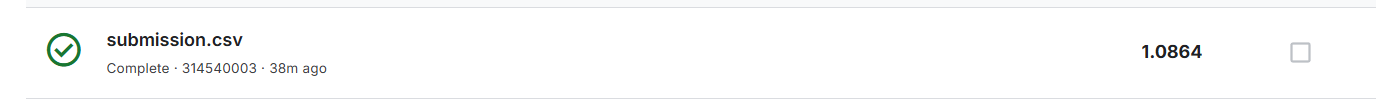

# Post-submission review: data pipeline and inference issues

The submitted TFT pipeline produced a public leaderboard MAE of `1.0864`, which indicates that the model was not solving the Kaggle task in the same form that the leaderboard evaluates. The project task is: for each region, use the 91 daily weather rows in `test.csv` to predict the next five weekly drought severity scores. The notebook pipeline instead trained a daily sequence model and then forced its outputs into the five-week submission format during inference.

## Pipeline that was actually used

1. Raw `train.csv` was loaded with daily meteorological observations and sparse weekly `score` labels. Each region has 5,480 training days, but only weekly score rows are originally labeled.
2. Initial EDA and feature engineering created rolling precipitation, dry-day, temperature, humidity, pressure, wind, trend, interaction, seasonal, and score-lag features.
3. For the final TFT dataset, most engineered rolling and lag features were dropped. The retained features were mostly raw daily weather columns plus calendar features, log precipitation, vapor pressure deficit, and cyclic month/day encodings.
4. The sparse weekly `score` target was linearly interpolated within each region to create a dense daily target. This was motivated by drought being physically smooth, but it changed the supervised task from five future weekly scores to 35 future daily interpolated values.
5. Weather variables were scaled per region. During training preprocessing this was done over each region's full available train timeline. Test-time scaling later had to be reconstructed separately.
6. The TFT was trained with a 91-day encoder and a 35-day decoder. The intended submission strategy was to predict 35 daily scores and extract decoder positions `[6, 13, 20, 27, 34]`, corresponding to days `+7, +14, +21, +28, +35`.
7. The model used `region_id` as a static categorical, calendar features as known real inputs, and weather variables plus `score` as time-varying unknown real inputs.
8. The final checkpoint used for inference was epoch 3, because epoch 4 worsened validation loss. A later inference script generated wide weekly predictions and formatted them to match `sample_submission.csv`.

## Main issues that likely caused the low leaderboard score

### 1. The training target did not match the leaderboard target

The leaderboard evaluates five weekly score values. The model was optimized over 35 daily interpolated score values. Even if interpolation is physically plausible, the loss function rewarded smooth daily reconstruction rather than accuracy at the five actual weekly evaluation points. The notebook did not validate MAE only on the five extracted weekly positions, so the reported validation loss was not aligned with Kaggle scoring.

### 2. Future weather leakage existed during training and validation

The TFT was trained with weather columns such as `prec`, `tmp`, `humidity`, `wind`, and `vpd` in `time_varying_unknown_reals`. In PyTorch Forecasting, these variables are still present in `decoder_cont` when future rows exist. This means the training and validation decoder windows had access to future weather rows from `train.csv`.

The Kaggle test set provides only the 91 input days and no future weather for the next 35 days. Therefore inference had to synthesize future weather. This created a major train-test mismatch: validation used real future weather, while test inference used approximate future weather.

### 3. Future weather had to be approximated during inference

To make inference run, the script created 35 synthetic future rows for each region and filled future weather with the last 28 observed test-day mean. This was only a compatibility patch. It does not represent actual future meteorological conditions, and drought scores are sensitive to future precipitation and heat. If the model learned to depend on decoder weather, then replacing real future weather with a crude average severely damages predictions.

### 4. The target `score` was also a decoder input

The trained dataset included `score` in `time_varying_unknown_reals`. Because PyTorch Forecasting requires non-null values in the dataframe used to build prediction samples, inference also needed a proxy `score` path for the 91 encoder days and 35 decoder days.

The patch filled the 91 test-history scores using the last 91 interpolated training scores from the same region, then repeated the last proxy score through the decoder. This is a weak assumption. The true recent test-period drought state is unknown, and using stale training-era score dynamics can make the model start from the wrong drought regime.

### 5. Test `day_index_region` and artificial dates were difficult to align

The original test preprocessing reset `day_index_region` to `0..90`, while training used long per-region indices up to 5,479. The inference script corrected this by continuing the index after the training rows, but this fix was applied after training and not validated in a clean Kaggle-like holdout. Artificial dates with unusual years also made calendar handling fragile.

### 6. Scaling was not originally saved as part of a reproducible preprocessing object

Training scaled each region's continuous features in place, but the fitted scalers were not saved. During inference, scaling had to be reconstructed from raw `train.csv`. This is better than independently scaling test, but still fragile because any mismatch in feature creation order, calendar handling, imputation, or grouping changes the model input distribution.

### 7. Validation was not a faithful simulation of the Kaggle setting

The validation dataset used the tail of `train.csv`, where future decoder weather and future interpolated targets existed. The model was not evaluated in a setting where only 91 history days were available and the next 35 days had to be generated without observed future weather or observed recent score history. This made the validation loss overly optimistic and not diagnostic of leaderboard performance.

### 8. The final predictions collapsed toward zero for many regions

The generated weekly predictions had many values extremely close to zero. This suggests the model, the proxy score inputs, the synthetic future weather, the target normalization, or some combination of these pushed inference toward a low-severity regime. If many public leaderboard regions had nonzero drought severity, this collapse alone would produce a large MAE.

## Summary of the failure

The submission was technically formatted correctly, but the modeling pipeline was not Kaggle-equivalent. The largest problems were not the TFT architecture itself. The largest problems were the mismatch between daily interpolated training and weekly scoring, future-weather leakage during validation, synthetic future-weather inference, proxy target filling, and an inference path that had to be retrofitted after training instead of designed before training.


# What the solution could have looked like if the pipeline had been correct

A stronger version of this approach would have designed training, validation, and inference around the Kaggle interface from the beginning: exactly 91 observed daily rows in, exactly five weekly scores out.

The model could still have used the physical smoothness of drought, but the supervised objective should have matched the final task. One option would be to train a multi-output model that predicts the five future weekly scores directly. Another option would be to keep a 35-day decoder, but compute validation and model-selection metrics only at days `+7`, `+14`, `+21`, `+28`, and `+35`. In that case, interpolation could remain an auxiliary representation, not the only objective used to select checkpoints.

The data split should have simulated Kaggle inference. For each validation region/window, the model should receive only a 91-day historical encoder. Future decoder weather should be unavailable, exactly as in `test.csv`. If future calendar features are needed, they are valid known features. Weather should either be encoder-only, summarized into history features, or generated by a separate forecast/climatology module that is also used consistently in validation and test.

A cleaner TFT setup would separate variables by availability:

- known future inputs: horizon index, day/month cyclic features, maybe region-level constants;
- encoder-only observed inputs: historical precipitation, temperature, humidity, pressure, wind, VPD, and historical score-derived features if available;
- prediction targets: the five future weekly drought scores.

If recent scores are unavailable in `test.csv`, the model should not require true recent score history at inference. It could use only weather-derived history, or a separate state-estimation step trained and validated under the same missing-score condition. Any imputation of recent score state should be part of the validation protocol, not added after training.

Preprocessing should also be fit once and reused. Scalers, imputers, feature lists, categorical encoders, and target normalizers should be saved alongside the model checkpoint. Validation and test should pass through the exact same transform objects. This would avoid reconstructing scaling behavior after the fact.

The ideal workflow would have been:

1. Build a Kaggle-shaped dataset generator that creates many samples per region: 91 observed days as input and the next five real weekly labels as output.
2. Create rolling and aggregate weather features only from the 91-day history window, avoiding future leakage.
3. Fit preprocessing on training windows only and save the transforms.
4. Validate on later time windows using the exact same information available in `test.csv`.
5. Select checkpoints by five-week validation MAE, not daily interpolated MAE.
6. Run final inference on `test.csv` without synthetic variables the model was not validated against.
7. Format predictions directly into `region_id,pred_week1,...,pred_week5`.

Had this gone right, the TFT or another temporal model could have learned regional seasonality, cumulative rainfall deficits, heat and humidity stress, and drought persistence from historical daily weather. The validation score would have been a meaningful estimate of public leaderboard behavior, and the final submission would not have depended on emergency assumptions about future weather or hidden score history.


# Kaggle-shaped TFT retry: weekly direct forecasting

This section implements the cleaner workflow described above while still using a TFT architecture. The goal is to align training, validation, and inference with the Kaggle interface:

- use only historical weather available before prediction;
- convert daily observations into weekly rows using trailing 91-day weather summaries;
- train with a 13-week encoder, equivalent to 91 days, and a 5-week decoder;
- predict the five weekly scores directly instead of predicting 35 interpolated daily scores;
- keep future decoder inputs limited to calendar/relative-time features;
- aggressively subsample training windows while keeping all regions in the categorical encoder.

The implementation below writes a standalone script with `train` and `predict` modes. Training uses the last five weekly labels of each region as a Kaggle-shaped validation target. Prediction writes `weekly_tft_direct_submission.csv` in the same format as `sample_submission.csv`.


In [8]:
%%writefile weekly_tft_direct.py
import argparse
import os
import shutil
import warnings
from dataclasses import dataclass
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.distributed as dist
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.strategies import DDPStrategy
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import MAE

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("medium")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

WEATHER_COLS = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind",
    "wind_max", "wind_min", "wind_range",
]
KNOWN_REALS = ["week_sin", "week_cos"]
MAX_ENCODER_LENGTH = 13
MAX_PREDICTION_LENGTH = 5
ENCODER_ENDPOINT_OFFSETS = [6, 13, 20, 27, 34, 41, 48, 55, 62, 69, 76, 83, 90]
MONTH_LENGTHS = {1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
OUTPUT_COLUMNS = ["region_id", "pred_week1", "pred_week2", "pred_week3", "pred_week4", "pred_week5"]

FEATURE_COLS = [
    "prec_log",
    "prec_sum_7", "prec_sum_28", "prec_sum_91",
    "dry_days_28", "dry_days_91",
    "tmp", "tmp_mean_7", "tmp_mean_28", "tmp_mean_91", "tmp_std_28",
    "tmp_max_mean_7", "tmp_min_mean_7",
    "humidity", "humidity_mean_7", "humidity_mean_28", "humidity_mean_91",
    "humidity_min_28", "humidity_min_91",
    "vpd", "vpd_mean_7", "vpd_mean_28", "vpd_mean_91",
    "wind", "wind_mean_28", "wind_mean_91",
    "surf_pre", "surf_pre_mean_28", "surf_pre_mean_91",
    "tmp_range", "tmp_range_mean_28", "tmp_range_mean_91",
    "tmp_trend_7_28", "humidity_trend_7_28", "prec_trend_7_28",
]


@dataclass(frozen=True)
class RuntimeState:
    distributed: bool
    rank: int
    local_rank: int
    world_size: int


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Kaggle-shaped direct weekly TFT workflow.")
    subparsers = parser.add_subparsers(dest="mode", required=True)

    common = argparse.ArgumentParser(add_help=False)
    common.add_argument("--train-csv", default="train.csv")
    common.add_argument("--test-csv", default="test.csv")
    common.add_argument("--sample-submission", default="sample_submission.csv")
    common.add_argument("--output-dir", default="weekly_tft_direct_outputs")
    common.add_argument("--seed", type=int, default=42)
    common.add_argument("--batch-size", type=int, default=2048)
    common.add_argument("--num-workers", type=int, default=6)
    common.add_argument("--precision", choices=("auto", "bf16-mixed", "16-mixed", "32-true"), default="auto")

    train = subparsers.add_parser("train", parents=[common])
    train.add_argument("--max-epochs", type=int, default=8)
    train.add_argument("--max-train-samples", type=int, default=500_000)
    train.add_argument("--hidden-size", type=int, default=64)
    train.add_argument("--hidden-continuous-size", type=int, default=32)
    train.add_argument("--attention-head-size", type=int, default=4)
    train.add_argument("--dropout", type=float, default=0.20)
    train.add_argument("--learning-rate", type=float, default=1e-3)
    train.add_argument("--gradient-clip-val", type=float, default=0.5)
    train.add_argument("--early-stop-patience", type=int, default=2)

    predict = subparsers.add_parser("predict", parents=[common])
    predict.add_argument("--checkpoint", default="weekly_tft_direct_outputs/checkpoints/best.ckpt")
    predict.add_argument("--submission-name", default="weekly_tft_direct_submission.csv")

    return parser.parse_args()


def setup_runtime(seed: int) -> RuntimeState:
    os.environ.setdefault("PYTHONFAULTHANDLER", "1")
    os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
    os.environ.setdefault("TORCH_NCCL_ASYNC_ERROR_HANDLING", "1")
    os.environ.setdefault("NCCL_P2P_DISABLE", "0")
    os.environ.setdefault("NCCL_SHM_DISABLE", "0")

    world_size = int(os.environ.get("WORLD_SIZE", "1"))
    local_rank = int(os.environ.get("LOCAL_RANK", "0"))
    distributed = world_size > 1
    if distributed:
        if not torch.cuda.is_available():
            raise RuntimeError("Distributed training requested but CUDA is unavailable.")
        torch.cuda.set_device(local_rank)
        if not dist.is_initialized():
            dist.init_process_group(backend="nccl", init_method="env://", timeout=timedelta(minutes=45))
        rank = dist.get_rank()
    else:
        rank = 0
        world_size = 1
    pl.seed_everything(seed, workers=True)
    return RuntimeState(distributed=distributed, rank=rank, local_rank=local_rank, world_size=world_size)


def rank_zero_print(runtime: RuntimeState, *values: object) -> None:
    if runtime.rank == 0:
        print(*values, flush=True)


def select_precision(precision: str) -> str:
    if precision != "auto":
        return precision
    if not torch.cuda.is_available():
        return "32-true"
    if torch.cuda.is_bf16_supported():
        return "bf16-mixed"
    return "16-mixed"


def split_date_parts(df: pd.DataFrame) -> pd.DataFrame:
    parts = df["date"].astype(str).str.extract(r"^(?P<year>\d+)-(?P<month>\d{2})-(?P<day>\d{2})$")
    if parts.isna().any().any():
        bad = df.loc[parts.isna().any(axis=1), "date"].head().tolist()
        raise ValueError(f"Unexpected date examples: {bad}")
    df = df.copy()
    df["year"] = parts["year"].astype(int)
    df["month"] = parts["month"].astype(int)
    df["day"] = parts["day"].astype(int)
    return df


def day_of_year(month: pd.Series, day: pd.Series) -> pd.Series:
    offsets = {m: sum(MONTH_LENGTHS[i] for i in range(1, m)) for m in range(1, 13)}
    return month.map(offsets).astype(int) + day.astype(int)


def advance_one_day(year: int, month: int, day: int) -> tuple[int, int, int]:
    day += 1
    if day > MONTH_LENGTHS[month]:
        day = 1
        month += 1
        if month > 12:
            month = 1
            year += 1
    return year, month, day


def advance_days(year: int, month: int, day: int, n_days: int) -> tuple[int, int, int]:
    for _ in range(n_days):
        year, month, day = advance_one_day(year, month, day)
    return year, month, day


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    doy = day_of_year(df["month"], df["day"])
    df["week_sin"] = np.sin(2 * np.pi * doy / 366.0)
    df["week_cos"] = np.cos(2 * np.pi * doy / 366.0)
    return df


def load_daily_csv(path: str, require_score: bool) -> pd.DataFrame:
    usecols = ["region_id", "date", *WEATHER_COLS]
    if require_score:
        usecols.append("score")
    df = pd.read_csv(path, usecols=usecols)
    if not require_score:
        df["score"] = np.nan
    df = split_date_parts(df)
    df = df.sort_values(["region_id", "year", "month", "day"]).reset_index(drop=True)
    df["day_index_region"] = df.groupby("region_id", sort=False).cumcount()
    return df


def rolling_by_region(df: pd.DataFrame, source: str, window: int, stat: str) -> pd.Series:
    grouped = df.groupby("region_id", sort=False)[source]
    if stat == "mean":
        return grouped.transform(lambda x: x.rolling(window, min_periods=1).mean())
    if stat == "sum":
        return grouped.transform(lambda x: x.rolling(window, min_periods=1).sum())
    if stat == "min":
        return grouped.transform(lambda x: x.rolling(window, min_periods=1).min())
    if stat == "std":
        return grouped.transform(lambda x: x.rolling(window, min_periods=2).std()).fillna(0.0)
    raise ValueError(stat)


def add_trailing_weather_features(daily: pd.DataFrame) -> pd.DataFrame:
    daily = daily.copy()
    daily["prec_raw"] = daily["prec"].clip(lower=0)
    daily["prec_log"] = np.log1p(daily["prec_raw"])
    daily["is_dry_day"] = (daily["prec_raw"] < 0.1).astype(float)

    e_s = 0.611 * np.exp((17.27 * daily["tmp"]) / (daily["tmp"] + 237.3))
    e_a = 0.611 * np.exp((17.27 * daily["dp_tmp"]) / (daily["dp_tmp"] + 237.3))
    daily["vpd"] = e_s - e_a

    for window in [7, 28, 91]:
        daily[f"prec_sum_{window}"] = rolling_by_region(daily, "prec_raw", window, "sum")
        daily[f"tmp_mean_{window}"] = rolling_by_region(daily, "tmp", window, "mean")
        daily[f"humidity_mean_{window}"] = rolling_by_region(daily, "humidity", window, "mean")
        daily[f"vpd_mean_{window}"] = rolling_by_region(daily, "vpd", window, "mean")

    for window in [28, 91]:
        daily[f"dry_days_{window}"] = rolling_by_region(daily, "is_dry_day", window, "sum")
        daily[f"humidity_min_{window}"] = rolling_by_region(daily, "humidity", window, "min")
        daily[f"wind_mean_{window}"] = rolling_by_region(daily, "wind", window, "mean")
        daily[f"surf_pre_mean_{window}"] = rolling_by_region(daily, "surf_pre", window, "mean")
        daily[f"tmp_range_mean_{window}"] = rolling_by_region(daily, "tmp_range", window, "mean")

    daily["tmp_std_28"] = rolling_by_region(daily, "tmp", 28, "std")
    daily["tmp_max_mean_7"] = rolling_by_region(daily, "tmp_max", 7, "mean")
    daily["tmp_min_mean_7"] = rolling_by_region(daily, "tmp_min", 7, "mean")
    daily["tmp_trend_7_28"] = daily["tmp_mean_7"] - daily["tmp_mean_28"]
    daily["humidity_trend_7_28"] = daily["humidity_mean_7"] - daily["humidity_mean_28"]
    daily["prec_trend_7_28"] = daily["prec_sum_7"] - (daily["prec_sum_28"] / 4.0)
    daily = add_calendar_features(daily)
    return daily


def fill_weekly_features(df: pd.DataFrame, medians: pd.Series | None = None) -> tuple[pd.DataFrame, pd.Series]:
    df = df.copy()
    fill_cols = FEATURE_COLS + KNOWN_REALS
    df[fill_cols] = df.groupby("region_id", sort=False)[fill_cols].transform(lambda x: x.ffill().bfill())
    if medians is None:
        medians = df[FEATURE_COLS].median(numeric_only=True).fillna(0.0)
    df[FEATURE_COLS] = df[FEATURE_COLS].fillna(medians)
    df[KNOWN_REALS] = df[KNOWN_REALS].fillna(0.0)
    return df, medians


def make_train_weekly(train_csv: str) -> pd.DataFrame:
    daily = load_daily_csv(train_csv, require_score=True)
    daily = add_trailing_weather_features(daily)
    weekly = daily[daily["score"].notna()].copy()
    weekly["week_idx"] = weekly.groupby("region_id", sort=False).cumcount()
    keep_cols = ["region_id", "week_idx", "score", *KNOWN_REALS, *FEATURE_COLS]
    weekly = weekly[keep_cols].reset_index(drop=True)
    weekly, _ = fill_weekly_features(weekly)
    weekly["score"] = weekly["score"].astype(float).clip(0, 5)
    return weekly


def split_train_val(weekly: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    weekly = weekly.copy()
    max_week = weekly.groupby("region_id", sort=False)["week_idx"].transform("max")
    val_start = max_week - (MAX_ENCODER_LENGTH + MAX_PREDICTION_LENGTH) + 1
    train_cutoff = max_week - MAX_PREDICTION_LENGTH
    train_df = weekly[weekly["week_idx"] <= train_cutoff].copy()
    val_df = weekly[weekly["week_idx"] >= val_start].copy()
    return train_df, val_df


def build_training_dataset(train_df: pd.DataFrame, max_train_samples: int = 0, seed: int = 42) -> TimeSeriesDataSet:
    dataset = TimeSeriesDataSet(
        train_df,
        time_idx="week_idx",
        target="score",
        group_ids=["region_id"],
        min_encoder_length=MAX_ENCODER_LENGTH,
        max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=MAX_PREDICTION_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=["region_id"],
        time_varying_known_reals=KNOWN_REALS,
        time_varying_unknown_reals=FEATURE_COLS,
        target_normalizer=None,
        add_relative_time_idx=True,
        add_encoder_length=True,
    )
    if max_train_samples and len(dataset) > max_train_samples:
        dataset.index = dataset.index.sample(n=max_train_samples, random_state=seed).reset_index(drop=True)
    return dataset


def build_model(training_dataset: TimeSeriesDataSet, args: argparse.Namespace) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=args.hidden_size,
        hidden_continuous_size=args.hidden_continuous_size,
        attention_head_size=args.attention_head_size,
        dropout=args.dropout,
        learning_rate=args.learning_rate,
        loss=MAE(),
        output_size=1,
        reduce_on_plateau_patience=2,
        log_interval=-1,
    )


def make_loader(dataset: TimeSeriesDataSet, train: bool, batch_size: int, num_workers: int):
    kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "persistent_workers": num_workers > 0,
        "pin_memory": torch.cuda.is_available(),
    }
    if num_workers > 0:
        kwargs["prefetch_factor"] = 2
    return dataset.to_dataloader(train=train, **kwargs)


def train_mode(args: argparse.Namespace) -> None:
    runtime = setup_runtime(args.seed)
    out_dir = Path(args.output_dir)
    ckpt_dir = out_dir / "checkpoints"
    log_dir = out_dir / "lightning_logs"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    try:
        rank_zero_print(runtime, "Building weekly direct TFT dataset...")
        weekly = make_train_weekly(args.train_csv)
        train_df, val_df = split_train_val(weekly)
        del weekly
        rank_zero_print(runtime, f"Training rows: {len(train_df):,}; validation rows: {len(val_df):,}; regions: {train_df['region_id'].nunique():,}")

        training_dataset = build_training_dataset(train_df, args.max_train_samples, args.seed)
        validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, val_df, predict=True, stop_randomization=True)
        rank_zero_print(runtime, f"Training samples after index subsampling: {len(training_dataset):,}; validation samples: {len(validation_dataset):,}")

        train_loader = make_loader(training_dataset, train=True, batch_size=args.batch_size, num_workers=args.num_workers)
        val_loader = make_loader(validation_dataset, train=False, batch_size=args.batch_size * 2, num_workers=args.num_workers)
        model = build_model(training_dataset, args)
        if runtime.rank == 0:
            print("Encoder variables:", model.encoder_variables, flush=True)
            print("Decoder variables:", model.decoder_variables, flush=True)

        checkpoint_callback = ModelCheckpoint(
            dirpath=ckpt_dir,
            filename="weekly-direct-{epoch:02d}-{val_loss:.5f}",
            monitor="val_loss",
            mode="min",
            save_top_k=2,
            save_last=True,
        )
        callbacks = [
            LearningRateMonitor(logging_interval="epoch"),
            checkpoint_callback,
            EarlyStopping(monitor="val_loss", patience=args.early_stop_patience, min_delta=1e-4, mode="min"),
        ]
        strategy = DDPStrategy(process_group_backend="nccl", timeout=timedelta(minutes=45)) if runtime.distributed else "auto"
        trainer = pl.Trainer(
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=runtime.world_size if runtime.distributed else 1,
            strategy=strategy,
            precision=select_precision(args.precision),
            max_epochs=args.max_epochs,
            gradient_clip_val=args.gradient_clip_val,
            callbacks=callbacks,
            logger=TensorBoardLogger(str(log_dir), name="weekly_direct_tft"),
            enable_progress_bar=runtime.rank == 0,
            enable_model_summary=runtime.rank == 0,
            num_sanity_val_steps=0,
            check_val_every_n_epoch=1,
            log_every_n_steps=50,
        )
        trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

        if runtime.rank == 0:
            best_path = Path(checkpoint_callback.best_model_path)
            best_copy = ckpt_dir / "best.ckpt"
            if best_path.exists():
                shutil.copy2(best_path, best_copy)
            print("Training complete.", flush=True)
            print(f"Best checkpoint: {best_path}", flush=True)
            print(f"Best checkpoint copy: {best_copy}", flush=True)
            print(f"Best val_loss: {checkpoint_callback.best_model_score}", flush=True)
    finally:
        if runtime.distributed and dist.is_initialized():
            dist.destroy_process_group()


def build_test_weekly(test_csv: str, train_weekly: pd.DataFrame) -> pd.DataFrame:
    daily = load_daily_csv(test_csv, require_score=False)
    daily = add_trailing_weather_features(daily)
    train_max_week = train_weekly.groupby("region_id", sort=False)["week_idx"].max()
    feature_medians = train_weekly[FEATURE_COLS].median(numeric_only=True).fillna(0.0)

    rows = []
    for region, group in daily.groupby("region_id", sort=False):
        group = group.sort_values("day_index_region").reset_index(drop=True)
        if len(group) < 91:
            raise ValueError(f"Region {region} has only {len(group)} test rows; expected 91.")
        start_week = int(train_max_week.loc[region]) + 1
        encoder = group.iloc[ENCODER_ENDPOINT_OFFSETS].copy()
        for j, (_, row) in enumerate(encoder.iterrows()):
            out = {"region_id": region, "week_idx": start_week + j, "score": 0.0}
            for col in KNOWN_REALS + FEATURE_COLS:
                out[col] = row[col]
            rows.append(out)

        last = group.iloc[90]
        year, month, day = int(last["year"]), int(last["month"]), int(last["day"])
        for h in range(1, MAX_PREDICTION_LENGTH + 1):
            fy, fm, fd = advance_days(year, month, day, h * 7)
            doy = sum(MONTH_LENGTHS[i] for i in range(1, fm)) + fd
            out = {
                "region_id": region,
                "week_idx": start_week + MAX_ENCODER_LENGTH + h - 1,
                "score": 0.0,
                "week_sin": float(np.sin(2 * np.pi * doy / 366.0)),
                "week_cos": float(np.cos(2 * np.pi * doy / 366.0)),
            }
            for col in FEATURE_COLS:
                out[col] = float(feature_medians[col])
            rows.append(out)

    pred_df = pd.DataFrame(rows)
    pred_df, _ = fill_weekly_features(pred_df, medians=feature_medians)
    pred_df["score"] = 0.0
    pred_df = pred_df[["region_id", "week_idx", "score", *KNOWN_REALS, *FEATURE_COLS]].reset_index(drop=True)
    if pred_df.isna().sum().sum() != 0:
        missing = pred_df.isna().sum()
        raise ValueError(f"Prediction dataframe has missing values:\n{missing[missing > 0]}")
    return pred_df


def prediction_output_to_array(prediction) -> np.ndarray:
    output = getattr(prediction, "output", prediction)
    if isinstance(output, list):
        output = torch.cat([x.detach().cpu() for x in output], dim=0)
    elif isinstance(output, torch.Tensor):
        output = output.detach().cpu()
    else:
        output = torch.as_tensor(output)
    if output.ndim == 3 and output.shape[-1] == 1:
        output = output[..., 0]
    if output.ndim != 2 or output.shape[1] != MAX_PREDICTION_LENGTH:
        raise ValueError(f"Unexpected prediction shape: {tuple(output.shape)}")
    return output.numpy()


def extract_regions(prediction, prediction_dataset: TimeSeriesDataSet, pred_df: pd.DataFrame) -> list[str]:
    index = getattr(prediction, "index", None)
    if isinstance(index, pd.DataFrame) and "region_id" in index.columns:
        return index["region_id"].astype(str).tolist()
    try:
        decoded = prediction_dataset.decoded_index
        if isinstance(decoded, pd.DataFrame) and "region_id" in decoded.columns:
            return decoded["region_id"].astype(str).tolist()
    except Exception:
        pass
    return pred_df.groupby("region_id", sort=False).size().index.astype(str).tolist()


def predict_mode(args: argparse.Namespace) -> None:
    pl.seed_everything(args.seed, workers=True)
    out_dir = Path(args.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    checkpoint = Path(args.checkpoint)
    if not checkpoint.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint}")

    print("Rebuilding training dataset metadata...", flush=True)
    train_weekly = make_train_weekly(args.train_csv)
    train_df, _ = split_train_val(train_weekly)
    training_dataset = build_training_dataset(train_df, max_train_samples=0, seed=args.seed)
    pred_df = build_test_weekly(args.test_csv, train_weekly)
    prediction_dataset = TimeSeriesDataSet.from_dataset(training_dataset, pred_df, predict=True, stop_randomization=True)
    print(f"Prediction samples: {len(prediction_dataset):,}", flush=True)

    model = TemporalFusionTransformer.load_from_checkpoint(checkpoint)
    model.eval()
    prediction = model.predict(
        prediction_dataset,
        mode="prediction",
        return_index=True,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        trainer_kwargs={
            "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
            "devices": 1,
            "precision": "32-true",
            "logger": False,
            "enable_progress_bar": True,
        },
    )
    pred = np.clip(prediction_output_to_array(prediction), 0.0, 5.0)
    regions = extract_regions(prediction, prediction_dataset, pred_df)
    if len(regions) != pred.shape[0]:
        raise ValueError(f"Region count mismatch: {len(regions)} vs {pred.shape[0]}")

    wide = pd.DataFrame(pred, columns=OUTPUT_COLUMNS[1:])
    wide.insert(0, "region_id", regions)
    sample = pd.read_csv(args.sample_submission)
    submission = sample[["region_id"]].merge(wide, on="region_id", how="left", validate="one_to_one")
    submission = submission[OUTPUT_COLUMNS]
    if submission.isna().sum().sum() != 0:
        missing = submission.isna().sum()
        raise ValueError(f"Submission has missing values:\n{missing[missing > 0]}")
    if not submission["region_id"].equals(sample["region_id"]):
        raise ValueError("Submission region order does not match sample_submission.csv")

    pred_path = out_dir / "weekly_tft_direct_predictions_wide.csv"
    sub_path = out_dir / args.submission_name
    wide.to_csv(pred_path, index=False)
    submission.to_csv(sub_path, index=False)
    print(f"Saved predictions: {pred_path}", flush=True)
    print(f"Saved submission: {sub_path}", flush=True)
    print(submission.head(15).to_string(index=False), flush=True)


def main() -> None:
    args = parse_args()
    if args.mode == "train":
        train_mode(args)
    elif args.mode == "predict":
        predict_mode(args)
    else:
        raise ValueError(args.mode)


if __name__ == "__main__":
    main()


Writing weekly_tft_direct.py


In [9]:
%%bash
set -euo pipefail

SESSION="weekly_tft_direct_train"
WORKDIR="/root"
LOG_LINK="${WORKDIR}/logs/weekly_tft_direct_train_latest.log"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed. Run the torchrun command manually instead."
  exit 1
fi

if [[ ! -f "${WORKDIR}/weekly_tft_direct.py" ]]; then
  echo "Missing ${WORKDIR}/weekly_tft_direct.py. Run the previous %%writefile cell first."
  exit 1
fi

read -r -d '' TRAIN_CMD <<'BASH' || true
set -uo pipefail
cd /root
mkdir -p logs
log_file="logs/weekly_tft_direct_train_$(date +%Y%m%d_%H%M%S).log"
ln -sfn "$(basename "${log_file}")" logs/weekly_tft_direct_train_latest.log

{
  echo "Logging to ${log_file}"
  echo "Starting weekly direct TFT training at $(date)"

  CUDA_VISIBLE_DEVICES=0,1 \
  OMP_NUM_THREADS=2 \
  MKL_NUM_THREADS=2 \
  OPENBLAS_NUM_THREADS=2 \
  NUMEXPR_NUM_THREADS=2 \
  NCCL_DEBUG=WARN \
  PYTHONFAULTHANDLER=1 \
  TOKENIZERS_PARALLELISM=false \
  python -u -m torch.distributed.run \
    --standalone \
    --nproc_per_node=2 \
    weekly_tft_direct.py train \
      --output-dir weekly_tft_direct_outputs \
      --max-train-samples 500000 \
      --max-epochs 8 \
      --batch-size 2048 \
      --num-workers 6 \
      --hidden-size 64 \
      --hidden-continuous-size 32 \
      --attention-head-size 4 \
      --dropout 0.20 \
      --learning-rate 0.001 \
      --gradient-clip-val 0.5 \
      --early-stop-patience 2

  train_status=$?
  echo "Finished weekly direct TFT training with status ${train_status} at $(date)"
  exit ${train_status}
} 2>&1 | tee -a "${log_file}"

status=${PIPESTATUS[0]}
echo
echo "Training command exited with status ${status}."
exit "${status}"
BASH

if tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is already running. Not starting a duplicate training job."
else
  TMUX_COMMAND="bash -lc $(printf '%q' "${TRAIN_CMD}")"
  tmux new-session -d -s "${SESSION}" "${TMUX_COMMAND}"
  echo "Started detached tmux session '${SESSION}'."
fi

echo "Attach: tmux attach -t ${SESSION}"
echo "Live log: tail -f logs/weekly_tft_direct_train_latest.log"
echo "Best checkpoint will be copied to weekly_tft_direct_outputs/checkpoints/best.ckpt"


Started detached tmux session 'weekly_tft_direct_train'.
Attach: tmux attach -t weekly_tft_direct_train
Live log: tail -f logs/weekly_tft_direct_train_latest.log
Best checkpoint will be copied to weekly_tft_direct_outputs/checkpoints/best.ckpt


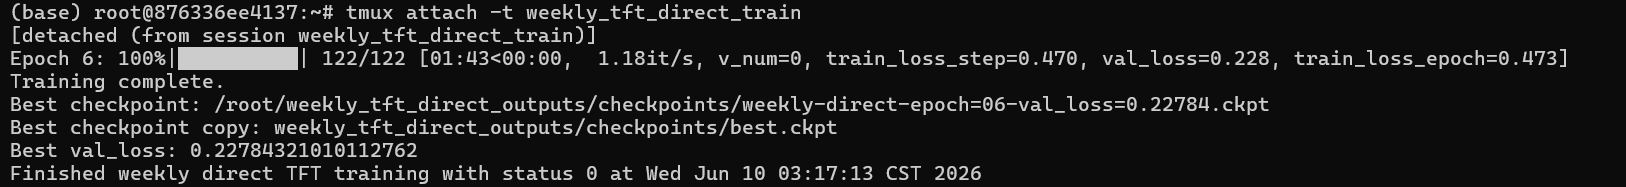

In [20]:
%%bash
set -euo pipefail

SESSION="weekly_tft_direct_predict"
WORKDIR="/root"
LOG_LINK="${WORKDIR}/logs/weekly_tft_direct_predict_latest.log"

if ! command -v tmux >/dev/null 2>&1; then
  echo "tmux is not installed. Run weekly_tft_direct.py predict manually instead."
  exit 1
fi

if [[ ! -f "${WORKDIR}/weekly_tft_direct.py" ]]; then
  echo "Missing ${WORKDIR}/weekly_tft_direct.py. Run the %%writefile cell first."
  exit 1
fi

if [[ ! -f "${WORKDIR}/weekly_tft_direct_outputs/checkpoints/best.ckpt" ]]; then
  echo "Missing best checkpoint. Run the weekly direct TFT training cell first."
  exit 1
fi

read -r -d '' PREDICT_CMD <<'BASH' || true
set -uo pipefail
cd /root
mkdir -p logs
log_file="logs/weekly_tft_direct_predict_$(date +%Y%m%d_%H%M%S).log"
ln -sfn "$(basename "${log_file}")" logs/weekly_tft_direct_predict_latest.log

{
  echo "Logging to ${log_file}"
  echo "Starting weekly direct TFT inference at $(date)"

  CUDA_VISIBLE_DEVICES=0 \
  OMP_NUM_THREADS=2 \
  MKL_NUM_THREADS=2 \
  OPENBLAS_NUM_THREADS=2 \
  NUMEXPR_NUM_THREADS=2 \
  PYTHONFAULTHANDLER=1 \
  TOKENIZERS_PARALLELISM=false \
  python -u weekly_tft_direct.py predict \
    --checkpoint weekly_tft_direct_outputs/checkpoints/best.ckpt \
    --output-dir weekly_tft_direct_outputs \
    --submission-name weekly_tft_direct_submission.csv \
    --batch-size 512 \
    --num-workers 4

  predict_status=$?
  echo "Finished weekly direct TFT inference with status ${predict_status} at $(date)"
  exit ${predict_status}
} 2>&1 | tee -a "${log_file}"

status=${PIPESTATUS[0]}
echo
echo "Inference command exited with status ${status}."
exit "${status}"
BASH

if tmux has-session -t "${SESSION}" 2>/dev/null; then
  echo "tmux session '${SESSION}' is already running. Not starting a duplicate inference job."
else
  TMUX_COMMAND="bash -lc $(printf '%q' "${PREDICT_CMD}")"
  tmux new-session -d -s "${SESSION}" "${TMUX_COMMAND}"
  echo "Started detached tmux session '${SESSION}'."
fi

echo "Attach: tmux attach -t ${SESSION}"
echo "Live log: tail -f logs/weekly_tft_direct_predict_latest.log"
echo "Submission will be written to weekly_tft_direct_outputs/weekly_tft_direct_submission.csv"


Started detached tmux session 'weekly_tft_direct_predict'.
Attach: tmux attach -t weekly_tft_direct_predict
Live log: tail -f logs/weekly_tft_direct_predict_latest.log
Submission will be written to weekly_tft_direct_outputs/weekly_tft_direct_submission.csv


In [ ]:
import pandas as pd

submission_path = "weekly_tft_direct_outputs/weekly_tft_direct_submission.csv"
submission_df = pd.read_csv(submission_path)

print("Current weekly_tft_direct_submission.csv head before rounding:")
display(submission_df.head(15))

prediction_cols = [col for col in submission_df.columns if col != "region_id"]
submission_df[prediction_cols] = submission_df[prediction_cols].round(1)
submission_df.to_csv(submission_path, index=False)

print(f"Rounded {len(prediction_cols)} prediction columns to one decimal place and saved {submission_path}.")


Current submission.csv head before rounding:


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.064320,0.039365,0.028134,0.024472,0.024107
1,R2,0.011353,0.012136,0.012342,0.012437,0.012579
2,R3,4.026216,4.010609,3.897710,3.764739,3.620165
3,R4,3.305493,3.201287,3.111864,3.055872,3.017438
4,R6,3.554452,3.441202,3.284691,3.135448,2.986015
5,R7,0.015080,0.014990,0.015180,0.015788,0.016463
6,R8,4.257871,4.304187,4.279530,4.222882,4.146362
7,R9,3.642996,3.493804,3.290034,3.152652,3.061894
8,R11,0.011634,0.012099,0.012334,0.012020,0.011494
9,R13,0.012255,0.012375,0.012275,0.012176,0.012153


Rounded 5 prediction columns to one decimal place and saved weekly_tft_direct_outputs/weekly_tft_direct_submission.csv.


In [24]:
import pandas as pd

submission_df = pd.read_csv("weekly_tft_direct_outputs/weekly_tft_direct_submission.csv")

print("Final weekly_tft_direct_submission.csv head after rounding:")
display(submission_df.head(15))

Final weekly_tft_direct_submission.csv head after rounding:


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.1,0.0,0.0,0.0,0.0
1,R2,0.0,0.0,0.0,0.0,0.0
2,R3,4.0,4.0,3.9,3.8,3.6
3,R4,3.3,3.2,3.1,3.1,3.0
4,R6,3.6,3.4,3.3,3.1,3.0
5,R7,0.0,0.0,0.0,0.0,0.0
6,R8,4.3,4.3,4.3,4.2,4.1
7,R9,3.6,3.5,3.3,3.2,3.1
8,R11,0.0,0.0,0.0,0.0,0.0
9,R13,0.0,0.0,0.0,0.0,0.0


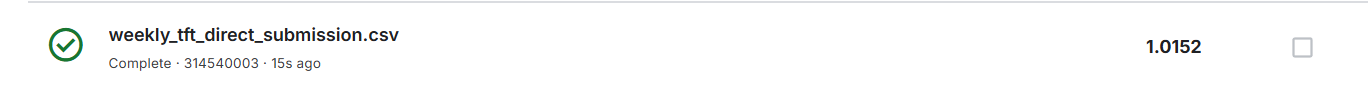

# Post-submission review: weekly-direct TFT result

The weekly-direct TFT submission improved only slightly, with public leaderboard MAE around `1.0152`. This is still very poor, which suggests that aligning the output format alone was not enough. The model was closer to the Kaggle task than the first interpolated-daily TFT, but several important issues likely remained.

## Likely causes

1. **The model still had weak drought state information.**  
   The test set does not provide recent `score` values, and the weekly-direct retry intentionally avoided using `score` as an input. That removed leakage, but it also forced the model to infer current drought state only from weather. Since drought severity is highly persistent, missing recent severity state is a major disadvantage.

2. **Weekly aggregation may have discarded useful daily structure.**  
   The retry converted 91 daily observations into 13 weekly rows using trailing summary features. This is cleaner, but it may be too compressed. Extreme dry spells, timing of rain, heat waves, and short-term transitions can be weakened by weekly endpoint summaries.

3. **Validation was more task-shaped, but still limited.**  
   The validation setup used the final five weekly labels per region. That is closer to Kaggle, but it is only one temporal validation slice. If public test conditions differ seasonally or distributionally, the selected checkpoint can still generalize poorly.

4. **Aggressive subsampling may have hurt the TFT.**  
   The retry sampled training windows for speed. This made the attempt practical, but TFTs usually need many examples and stable training. A fixed architecture trained quickly on a subsample may underfit region-specific drought behavior.

5. **The architecture may be mismatched to the available information.**  
   TFT is powerful when it has meaningful time-varying covariates and enough signal. Here, future weather is unavailable, recent target history is unavailable, and the decoder has mostly calendar information. A simpler tabular model over robust 91-day summary features may be better suited to this constrained inference setting.

6. **Feature scaling and representation were still imperfect.**  
   The retry used engineered rolling weather summaries, but the chosen features and normalization were not tuned. Drought may require stronger region-normalized anomalies, long-term climatology, precipitation deficits against seasonal baselines, and explicit persistence proxies.

## Summary

The second TFT was a better experimental design, but it likely lacked the strongest predictors: recent drought state, high-quality region/season baselines, and future-relevant weather signals. The result suggests the bottleneck is not just architecture or GPU time. The bigger issue is representing drought persistence and regional climatology from the information actually available at test time.


In [27]:
%pip install -q torchview torchviz graphviz

from pathlib import Path
import warnings

import torch
from pytorch_forecasting import TemporalFusionTransformer
from torchview import draw_graph
from torchviz import make_dot

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("medium")

RENDER_DIR = Path("architecture_renders")
RENDER_DIR.mkdir(parents=True, exist_ok=True)

ARCHITECTURES = [
    {
        "name": "initial_daily_interpolated_tft",
        "label": "Initial architecture - daily interpolated TFT",
        "checkpoint": Path("tft_best_trial4_final/trial4-full-epoch=03-val_loss=0.04502.ckpt"),
        "encoder_length": 91,
        "decoder_length": 35,
    },
    {
        "name": "final_weekly_direct_tft",
        "label": "Final architecture - weekly direct TFT",
        "checkpoint": Path("weekly_tft_direct_outputs/checkpoints/best.ckpt"),
        "encoder_length": 13,
        "decoder_length": 5,
    },
]


def load_tft_from_checkpoint_cpu(checkpoint_path: Path) -> TemporalFusionTransformer:
    """Reconstruct on CPU without Lightning's load_from_checkpoint CUDA side effects."""
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = TemporalFusionTransformer(**checkpoint["hyper_parameters"].copy())
    model.load_state_dict(checkpoint["state_dict"], strict=True)
    model.eval()
    model.cpu()
    return model


def make_dummy_tft_batch(model: TemporalFusionTransformer, encoder_length: int, decoder_length: int) -> dict:
    n_cat = len(model.hparams.x_categoricals)
    n_real = len(model.hparams.x_reals)
    return {
        "encoder_cat": torch.zeros((1, encoder_length, n_cat), dtype=torch.long),
        "decoder_cat": torch.zeros((1, decoder_length, n_cat), dtype=torch.long),
        "encoder_cont": torch.zeros((1, encoder_length, n_real), dtype=torch.float32),
        "decoder_cont": torch.zeros((1, decoder_length, n_real), dtype=torch.float32),
        "encoder_lengths": torch.tensor([encoder_length], dtype=torch.long),
        "decoder_lengths": torch.tensor([decoder_length], dtype=torch.long),
        "groups": torch.zeros((1, max(n_cat, 1)), dtype=torch.long),
        "target_scale": torch.tensor([[0.0, 1.0]], dtype=torch.float32),
    }


def render_graphviz(dot, output_prefix: Path, label: str) -> None:
    dot.attr(label=label, labelloc="t")
    dot.save(str(output_prefix.with_suffix(".dot")))
    try:
        dot.render(str(output_prefix), format="png", cleanup=True)
        print(f"Saved PNG: {output_prefix.with_suffix('.png')}")
    except Exception as exc:
        print(f"Could not render PNG for {label}: {exc}")
        print(f"Saved DOT instead: {output_prefix.with_suffix('.dot')}")


def render_with_torchview(model: TemporalFusionTransformer, batch: dict, name: str, label: str) -> None:
    output_prefix = RENDER_DIR / f"{name}__torchview"
    graph = draw_graph(
        model,
        input_data=(batch,),
        graph_name=label,
        expand_nested=True,
        depth=4,
        device="cpu",
    )
    render_graphviz(graph.visual_graph, output_prefix, f"Torchview: {label}")


def render_with_torchviz(model: TemporalFusionTransformer, batch: dict, name: str, label: str) -> None:
    output_prefix = RENDER_DIR / f"{name}__torchviz"
    model.zero_grad(set_to_none=True)
    output = model(batch)
    scalar_output = output["prediction"].sum()
    dot = make_dot(scalar_output, params=dict(model.named_parameters()))
    render_graphviz(dot, output_prefix, f"Torchviz: {label}")


for spec in ARCHITECTURES:
    print(f"\n=== {spec['label']} ===")
    model = load_tft_from_checkpoint_cpu(spec["checkpoint"])
    batch = make_dummy_tft_batch(model, spec["encoder_length"], spec["decoder_length"])

    print("x_reals:", model.hparams.x_reals)
    print("x_categoricals:", model.hparams.x_categoricals)
    print("encoder variables:", model.encoder_variables)
    print("decoder variables:", model.decoder_variables)

    render_with_torchview(model, batch, spec["name"], spec["label"])
    render_with_torchviz(model, batch, spec["name"], spec["label"])

print(f"\nArchitecture renders written under: {RENDER_DIR.resolve()}")
print("Expected files:")
for path in sorted(RENDER_DIR.glob("*")):
    print("-", path)


Note: you may need to restart the kernel to use updated packages.

=== Initial architecture - daily interpolated TFT ===
x_reals: ['day_index_region', 'sin_dayofyear', 'cos_dayofyear', 'sin_month', 'cos_month', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'vpd', 'score']
x_categoricals: ['region_id']
encoder variables: ['day_index_region', 'sin_dayofyear', 'cos_dayofyear', 'sin_month', 'cos_month', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'vpd', 'score']
decoder variables: ['day_index_region', 'sin_dayofyear', 'cos_dayofyear', 'sin_month', 'cos_month']
Could not render PNG for Torchview: Initial architecture - daily interpolated TFT: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH
Saved DOT instead: architecture_renders/ini

The cell above generates and attempts to render diagrams of both TFT models for down-the-line analysis. The torchviz representations of each diagram ended up being over 10000 lines long, so the idea was abandoned.

# LightGBM direct weekly drought model

This appended section implements the handoff plan as a tabular, five-horizon LightGBM pipeline. It rebuilds features from the raw CSV files, avoids pandas datetime parsing for synthetic years, nowcasts the unlabeled recent drought state, trains direct horizon models, validates on rolling late origins, and writes `lgbm_outputs/lgbm_submission.csv`.


In [32]:
%pip install -q lightgbm


Note: you may need to restart the kernel to use updated packages.


In [33]:
%%writefile lgbm_drought_pipeline.py
from __future__ import annotations

import argparse
import json
import math
import os
import resource
import time
import warnings
from contextlib import contextmanager
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning
from sklearn.metrics import mean_absolute_error

try:
    import lightgbm as lgb
except ImportError as exc:
    raise SystemExit(
        "LightGBM is required. Run `%pip install -q lightgbm` in the notebook first."
    ) from exc


WEATHER_COLS = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "wind",
    "wind_max", "wind_min", "wind_range",
]
WINDOWS = [7, 14, 28, 56, 91]
TEST_WEEKLY_OFFSETS = [6, 13, 20, 27, 34, 41, 48, 55, 62, 69, 76, 83, 90]
OLDER_TRUE_LAGS = [13, 26, 52, 104]
MONTH_OFFSETS = np.array([0, 0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], dtype=np.int16)
RANDOM_SEED = 42
warnings.filterwarnings("ignore", category=PerformanceWarning)


def log(message: str) -> None:
    print(f"[{time.strftime('%H:%M:%S')}] {message}", flush=True)


def memory_gb() -> float:
    usage_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return usage_kb / 1024 / 1024


@contextmanager
def timed_step(name: str):
    start = time.perf_counter()
    log(f"START {name}")
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        log(f"DONE  {name} in {elapsed:,.1f}s; peak RSS {memory_gb():.2f} GB")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Leakage-aware LightGBM drought forecasting pipeline")
    parser.add_argument("--mode", choices=["smoke", "full"], default="full")
    parser.add_argument("--train-path", default="train.csv")
    parser.add_argument("--test-path", default="test.csv")
    parser.add_argument("--sample-path", default="sample_submission.csv")
    parser.add_argument("--out-dir", default="lgbm_outputs")
    parser.add_argument("--max-regions", type=int, default=None, help="Limit to the first N sample regions for smoke testing")
    parser.add_argument("--num-boost-round", type=int, default=1000)
    parser.add_argument("--early-stopping-rounds", type=int, default=150)
    parser.add_argument("--nowcast-rounds", type=int, default=700)
    parser.add_argument("--min-forecast-week", type=int, default=100)
    parser.add_argument("--valid-origin-offsets", default="25,20,15,10,5")
    parser.add_argument("--no-sample-weights", action="store_true")
    parser.add_argument(
        "--sort-input",
        action="store_true",
        help="Force a full region/date sort. Slow; only use if the CSV row order is not already region-local chronological.",
    )
    return parser.parse_args()


def compact_float_frame(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include=["int64"]).columns:
        if col not in {"year"}:
            df[col] = pd.to_numeric(df[col], downcast="integer")
    return df


def read_csv_maybe_filtered(path: str, *, has_score: bool, region_filter: set[str] | None) -> pd.DataFrame:
    usecols = ["region_id", "date"] + WEATHER_COLS + (["score"] if has_score else [])
    dtype = {"region_id": "string", "date": "string"}
    dtype.update({col: "float32" for col in WEATHER_COLS})
    if has_score:
        dtype["score"] = "float32"

    if region_filter is None:
        return pd.read_csv(path, usecols=usecols, dtype=dtype)

    chunks: list[pd.DataFrame] = []
    for chunk in pd.read_csv(path, usecols=usecols, dtype=dtype, chunksize=500_000):
        keep = chunk["region_id"].isin(region_filter)
        if keep.any():
            chunks.append(chunk.loc[keep].copy())
    if not chunks:
        raise ValueError(f"No rows from {path} matched the selected regions")
    return pd.concat(chunks, ignore_index=True)


def parse_date_parts_fast(df: pd.DataFrame) -> pd.DataFrame:
    date_str = df["date"].astype("string")
    # Synthetic years can have more than four digits. Month/day are fixed at the right side.
    df["year"] = date_str.str[:-6].astype("int32")
    df["month"] = date_str.str[-5:-3].astype("int16")
    df["day"] = date_str.str[-2:].astype("int16")
    month_values = df["month"].to_numpy(dtype=np.int16)
    df["doy"] = (MONTH_OFFSETS[month_values] + df["day"].to_numpy(dtype=np.int16)).astype("int16")
    df["week_of_year"] = (((df["doy"].astype("int16") - 1) // 7) + 1).astype("int16")
    df["month_sin"] = np.sin(2 * np.pi * df["month"].astype("float32") / 12.0).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * df["month"].astype("float32") / 12.0).astype("float32")
    df["doy_sin"] = np.sin(2 * np.pi * df["doy"].astype("float32") / 366.0).astype("float32")
    df["doy_cos"] = np.cos(2 * np.pi * df["doy"].astype("float32") / 366.0).astype("float32")
    df["season_bin"] = ((df["month"].astype("int16") % 12) // 3).astype("int8")
    return df


def prepare_daily_order(df: pd.DataFrame, region_order: list[str], *, label: str, sort_input: bool) -> pd.DataFrame:
    log(f"{label}: assigning region codes")
    region_cat = pd.Categorical(df["region_id"], categories=region_order, ordered=True)
    if (region_cat.codes < 0).any():
        missing = pd.Series(df.loc[region_cat.codes < 0, "region_id"]).astype(str).unique()[:5].tolist()
        raise ValueError(f"{label}: region ids not found in sample submission order: {missing}")
    df["region_id"] = region_cat
    df["region_idx"] = region_cat.codes.astype("int32")

    log(f"{label}: parsing synthetic date parts with fixed-width string slicing")
    df = parse_date_parts_fast(df)

    date_key = (
        df["year"].to_numpy(dtype=np.int64) * 10_000
        + df["month"].to_numpy(dtype=np.int64) * 100
        + df["day"].to_numpy(dtype=np.int64)
    )
    codes = df["region_idx"].to_numpy(dtype=np.int32)
    same_region = codes[1:] == codes[:-1]
    block_starts = np.r_[0, np.flatnonzero(~same_region) + 1]
    block_codes = codes[block_starts]
    regions_are_contiguous = len(block_codes) == len(np.unique(block_codes))
    dates_are_ordered_within_region = bool(np.all(date_key[1:][same_region] >= date_key[:-1][same_region]))

    if sort_input or not (regions_are_contiguous and dates_are_ordered_within_region):
        reason = "--sort-input was provided" if sort_input else "CSV order failed the region/date sanity check"
        log(f"{label}: sorting by region/date because {reason}")
        df = df.sort_values(["region_id", "year", "month", "day"], kind="mergesort").reset_index(drop=True)
    else:
        log(f"{label}: CSV order verified; skipping expensive full-frame sort")
        df = df.reset_index(drop=True)

    log(f"{label}: creating region-local day index")
    df["day_idx"] = df.groupby("region_id", observed=True, sort=False).cumcount().astype("int32")
    return df


def add_daily_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    eps = np.float32(1e-6)
    df["prec_clip"] = df["prec"].clip(lower=0).astype("float32")
    df["prec_log1p"] = np.log1p(df["prec_clip"]).astype("float32")
    df["is_dry_day"] = (df["prec_clip"] < 0.1).astype("float32")
    df["is_wet_day_1mm"] = (df["prec_clip"] >= 1.0).astype("float32")
    df["is_wet_day_5mm"] = (df["prec_clip"] >= 5.0).astype("float32")
    df["is_heavy_precip"] = (df["prec_clip"] >= 10.0).astype("float32")

    df["diurnal_range"] = (df["tmp_max"] - df["tmp_min"]).astype("float32")
    df["heat_day_30"] = (df["tmp_max"] >= 30.0).astype("float32")
    df["heat_day_35"] = (df["tmp_max"] >= 35.0).astype("float32")
    df["cold_day_0"] = (df["tmp_min"] <= 0.0).astype("float32")

    tmp_safe = df["tmp"].clip(lower=-80, upper=80).astype("float32")
    dew_safe = df["dp_tmp"].clip(lower=-80, upper=80).astype("float32")
    e_s = 0.611 * np.exp((17.27 * tmp_safe) / (tmp_safe + 237.3))
    e_a = 0.611 * np.exp((17.27 * dew_safe) / (dew_safe + 237.3))
    df["vpd"] = np.maximum(e_s - e_a, 0).astype("float32")
    df["humidity_deficit"] = (100.0 - df["humidity"]).astype("float32")
    df["temp_dewpoint_spread"] = (df["tmp"] - df["dp_tmp"]).astype("float32")
    df["tmp_minus_wb"] = (df["tmp"] - df["wb_tmp"]).astype("float32")
    df["surf_tmp_minus_tmp"] = (df["surf_tmp"] - df["tmp"]).astype("float32")
    df["wind_stress"] = (df["wind"] * df["vpd"]).astype("float32")
    df["evap_proxy"] = (df["vpd"] * (1.0 + df["wind"].clip(lower=0))).astype("float32")
    df["water_balance"] = (df["prec_clip"] - df["evap_proxy"]).astype("float32")
    df["stress_daily"] = (
        df["vpd"].fillna(0) + 0.03 * df["tmp"].fillna(0) + 0.01 * df["humidity_deficit"].fillna(0)
        - df["prec_log1p"].fillna(0)
    ).astype("float32")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


def train_endpoint_rows(daily: pd.DataFrame) -> pd.DataFrame:
    endpoints = daily.loc[daily["score"].notna(), [
        "region_id", "region_idx", "date", "year", "month", "day", "doy", "week_of_year",
        "month_sin", "month_cos", "doy_sin", "doy_cos", "season_bin", "day_idx", "score",
    ]].copy()
    endpoints["daily_row_pos"] = endpoints.index.astype("int64")
    endpoints["source"] = "train"
    endpoints["week_idx"] = endpoints.groupby("region_id", observed=True).cumcount().astype("int16")
    endpoints["endpoint_seq"] = endpoints["week_idx"].astype("int16")
    return endpoints.reset_index(drop=True)


def test_endpoint_rows(daily: pd.DataFrame) -> pd.DataFrame:
    pieces: list[pd.DataFrame] = []
    for seq, offset in enumerate(TEST_WEEKLY_OFFSETS):
        part = daily.groupby("region_id", observed=True, sort=False).nth(offset).reset_index()
        part = part[[
            "region_id", "region_idx", "date", "year", "month", "day", "doy", "week_of_year",
            "month_sin", "month_cos", "doy_sin", "doy_cos", "season_bin", "day_idx",
        ]].copy()
        part["daily_row_pos"] = daily.groupby("region_id", observed=True, sort=False).nth(offset).index.to_numpy(dtype="int64")
        part["source"] = "test"
        part["score"] = np.nan
        part["week_idx"] = seq
        part["endpoint_seq"] = seq
        pieces.append(part)
    endpoints = pd.concat(pieces, ignore_index=True)
    endpoints = endpoints.sort_values(["region_id", "endpoint_seq"], kind="mergesort").reset_index(drop=True)
    return endpoints


def rolling_plan() -> dict[str, dict[int, list[str]]]:
    plan: dict[str, dict[int, list[str]]] = {}

    def add(col: str, windows: Iterable[int], aggs: Iterable[str]) -> None:
        spec = plan.setdefault(col, {})
        for window in windows:
            existing = spec.setdefault(window, [])
            for agg in aggs:
                if agg not in existing:
                    existing.append(agg)

    add("prec_clip", WINDOWS, ["sum", "mean", "max", "std"])
    for col in ["is_dry_day", "is_wet_day_1mm", "is_wet_day_5mm", "is_heavy_precip", "heat_day_30", "heat_day_35"]:
        add(col, WINDOWS, ["sum"])
    for col in ["tmp", "tmp_max", "tmp_min", "tmp_range", "surf_tmp", "humidity", "surf_pre", "wind", "wind_max", "vpd", "humidity_deficit", "wind_stress", "water_balance", "stress_daily"]:
        add(col, WINDOWS, ["mean"])
    for col in ["tmp", "humidity", "vpd", "wind", "water_balance", "stress_daily"]:
        add(col, [28, 91], ["std"])
    for col in ["humidity"]:
        add(col, [28, 91], ["min"])
    for col in ["tmp_max", "vpd", "wind_max"]:
        add(col, [28, 91], ["max"])
    return plan


def build_weekly_weather_features(daily: pd.DataFrame, endpoints: pd.DataFrame, label: str) -> pd.DataFrame:
    log(f"Building weekly weather features for {label}: {len(daily):,} daily rows -> {len(endpoints):,} endpoints")
    weekly = endpoints.copy()
    endpoint_pos = weekly["daily_row_pos"].to_numpy(dtype=np.int64)
    new_features: dict[str, np.ndarray] = {}

    current_cols = [
        "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp", "tmp_max", "tmp_min", "tmp_range",
        "surf_tmp", "wind", "wind_max", "wind_min", "wind_range", "prec_clip", "prec_log1p", "vpd",
        "humidity_deficit", "temp_dewpoint_spread", "tmp_minus_wb", "surf_tmp_minus_tmp", "wind_stress",
        "water_balance", "stress_daily",
    ]
    for col in current_cols:
        if col in daily.columns:
            new_features[f"{col}_current"] = daily[col].iloc[endpoint_pos].to_numpy(dtype=np.float32)

    for col, specs in rolling_plan().items():
        if col not in daily.columns:
            continue
        group = daily.groupby("region_id", observed=True, sort=False)[col]
        for window, aggs in specs.items():
            rolled = group.rolling(window=window, min_periods=1).agg(aggs)
            rolled.index = rolled.index.droplevel(0)
            if isinstance(rolled, pd.Series):
                agg = aggs[0]
                new_features[f"{col}_{agg}_{window}d"] = rolled.reindex(endpoint_pos).to_numpy(dtype=np.float32)
            else:
                aligned = rolled.reindex(endpoint_pos)
                for agg in aggs:
                    new_features[f"{col}_{agg}_{window}d"] = aligned[agg].to_numpy(dtype=np.float32)
            del rolled
        log(f"  finished rolling features for {col}")

    for halflife in [7, 30, 90]:
        col = f"stress_ewm_h{halflife}d"
        ewm = daily.groupby("region_id", observed=True, sort=False)["stress_daily"].transform(
            lambda s: s.ewm(halflife=halflife, adjust=False, min_periods=1).mean()
        )
        new_features[col] = ewm.iloc[endpoint_pos].to_numpy(dtype=np.float32)
        del ewm

    if new_features:
        weekly = pd.concat([weekly.reset_index(drop=True), pd.DataFrame(new_features)], axis=1)
    add_weather_trend_features(weekly)
    return compact_float_frame(weekly.copy())


def add_weather_trend_features(df: pd.DataFrame) -> None:
    pairs = [
        ("prec_clip_sum_7d", "prec_clip_sum_28d", 7 / 28, "prec_sum_7_vs_28"),
        ("prec_clip_sum_28d", "prec_clip_sum_91d", 28 / 91, "prec_sum_28_vs_91"),
        ("tmp_mean_7d", "tmp_mean_28d", 1.0, "tmp_mean_7_minus_28"),
        ("tmp_mean_28d", "tmp_mean_91d", 1.0, "tmp_mean_28_minus_91"),
        ("vpd_mean_7d", "vpd_mean_28d", 1.0, "vpd_mean_7_minus_28"),
        ("humidity_mean_7d", "humidity_mean_28d", 1.0, "humidity_mean_7_minus_28"),
        ("water_balance_mean_28d", "water_balance_mean_91d", 1.0, "water_balance_28_minus_91"),
        ("stress_daily_mean_28d", "stress_daily_mean_91d", 1.0, "stress_28_minus_91"),
    ]
    for recent, longer, scale, out in pairs:
        if recent in df.columns and longer in df.columns:
            df[out] = (df[recent] - df[longer] * scale).astype("float32")
    for window in [28, 56, 91]:
        sum_col = f"prec_clip_sum_{window}d"
        wet_col = f"is_wet_day_1mm_sum_{window}d"
        if sum_col in df.columns and wet_col in df.columns:
            df[f"prec_intensity_{window}d"] = (df[sum_col] / np.maximum(df[wet_col], 1)).astype("float32")


def add_weather_climatology(train_weekly: pd.DataFrame, frames: list[pd.DataFrame]) -> list[pd.DataFrame]:
    selected = [
        "prec_clip_sum_28d", "prec_clip_sum_91d", "tmp_mean_28d", "vpd_mean_28d",
        "humidity_mean_28d", "water_balance_mean_91d", "stress_daily_mean_91d",
    ]
    selected = [col for col in selected if col in train_weekly.columns]
    if not selected:
        return frames
    grouped = train_weekly.groupby(["region_id", "month"], observed=True)[selected].agg(["mean", "std"])
    grouped.columns = [f"{feat}_{stat}" for feat, stat in grouped.columns]

    updated: list[pd.DataFrame] = []
    for frame in frames:
        out = frame.copy()
        keys = pd.MultiIndex.from_frame(out[["region_id", "month"]])
        stats = grouped.reindex(keys).reset_index(drop=True)
        for feat in selected:
            mean_col = f"{feat}_mean"
            std_col = f"{feat}_std"
            if mean_col not in stats:
                continue
            mean_values = stats[mean_col].to_numpy(dtype=np.float32)
            std_values = stats[std_col].fillna(0).to_numpy(dtype=np.float32)
            out[f"{feat}_anom_rmonth"] = (out[feat].to_numpy(dtype=np.float32) - mean_values).astype("float32")
            out[f"{feat}_z_rmonth"] = ((out[feat].to_numpy(dtype=np.float32) - mean_values) / (std_values + 1e-3)).astype("float32")
        updated.append(out)
    return updated


def add_targets(weekly: pd.DataFrame) -> pd.DataFrame:
    weekly = weekly.sort_values(["region_id", "week_idx"], kind="mergesort").copy()
    group = weekly.groupby("region_id", observed=True, sort=False)["score"]
    for horizon in range(1, 6):
        weekly[f"target_h{horizon}"] = group.shift(-horizon).astype("float32")
    return weekly


def numeric_feature_columns(frame: pd.DataFrame, extra_exclude: Iterable[str] = ()) -> list[str]:
    exclude = {
        "score", "daily_row_pos", "target_h1", "target_h2", "target_h3", "target_h4", "target_h5",
        *extra_exclude,
    }
    cols = []
    for col in frame.columns:
        if col in exclude or col.startswith("target_h"):
            continue
        if pd.api.types.is_numeric_dtype(frame[col]):
            cols.append(col)
    return cols


def lgb_params(task: str, rows: int) -> dict:
    min_leaf = 50 if rows < 150_000 else 200
    leaves = 63 if rows < 150_000 else 127
    return {
        "objective": "regression_l1",
        "metric": "l1",
        "boosting_type": "gbdt",
        "learning_rate": 0.03 if task == "forecast" else 0.04,
        "num_leaves": leaves,
        "max_depth": -1,
        "min_data_in_leaf": min_leaf,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.0,
        "lambda_l2": 5.0,
        "max_bin": 255,
        "verbosity": -1,
        "seed": RANDOM_SEED,
        "feature_pre_filter": False,
        "num_threads": max(1, min(os.cpu_count() or 1, 20)),
    }


def train_lgb(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_valid: pd.DataFrame | None,
    y_valid: np.ndarray | None,
    params: dict,
    num_boost_round: int,
    early_stopping_rounds: int,
    categorical_cols: list[str],
    weights: np.ndarray | None = None,
    log_period: int = 100,
) -> lgb.Booster:
    train_set = lgb.Dataset(
        X_train,
        label=y_train,
        weight=weights,
        feature_name=list(X_train.columns),
        categorical_feature=[col for col in categorical_cols if col in X_train.columns],
        free_raw_data=False,
    )
    callbacks = [lgb.log_evaluation(period=log_period)]
    valid_sets = None
    valid_names = None
    if X_valid is not None and y_valid is not None and len(X_valid) > 0:
        valid_set = lgb.Dataset(
            X_valid,
            label=y_valid,
            reference=train_set,
            feature_name=list(X_train.columns),
            categorical_feature=[col for col in categorical_cols if col in X_train.columns],
            free_raw_data=False,
        )
        valid_sets = [valid_set]
        valid_names = ["valid"]
        callbacks.append(lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=True))
    return lgb.train(
        params,
        train_set,
        num_boost_round=num_boost_round,
        valid_sets=valid_sets,
        valid_names=valid_names,
        callbacks=callbacks,
    )


def make_nowcast_predictions(
    weekly: pd.DataFrame,
    test_history: pd.DataFrame,
    args: argparse.Namespace,
) -> tuple[pd.DataFrame, pd.DataFrame, lgb.Booster, list[str]]:
    log("Training stage-1 nowcast models")
    nowcast_cols = numeric_feature_columns(weekly, extra_exclude={"week_idx", "endpoint_seq"})
    categorical_cols = ["region_idx", "season_bin"]
    X_all = weekly[nowcast_cols]
    y_all = weekly["score"].to_numpy(dtype=np.float32)
    params = lgb_params("nowcast", len(weekly))

    weeks = np.array(sorted(weekly["week_idx"].unique()))
    max_week = int(weeks.max())
    first_val_week = max(40, min(args.min_forecast_week - 20, int(max_week * 0.12)))
    boundaries = np.unique(np.linspace(first_val_week, max_week + 1, 6, dtype=int))
    score_hat = np.full(len(weekly), np.nan, dtype=np.float32)
    best_iterations: list[int] = []

    for start, end in zip(boundaries[:-1], boundaries[1:]):
        train_mask = weekly["week_idx"].to_numpy() < start
        valid_mask = (weekly["week_idx"].to_numpy() >= start) & (weekly["week_idx"].to_numpy() < end)
        if train_mask.sum() == 0 or valid_mask.sum() == 0:
            continue
        log(f"  nowcast fold weeks [{start}, {end}) with {train_mask.sum():,} train / {valid_mask.sum():,} valid rows")
        model = train_lgb(
            X_all.loc[train_mask], y_all[train_mask],
            X_all.loc[valid_mask], y_all[valid_mask],
            params, args.nowcast_rounds, max(20, args.early_stopping_rounds // 2), categorical_cols,
            log_period=200,
        )
        pred = model.predict(X_all.loc[valid_mask], num_iteration=model.best_iteration)
        score_hat[valid_mask] = np.clip(pred, 0, 5).astype(np.float32)
        if model.best_iteration:
            best_iterations.append(int(model.best_iteration))

    final_rounds = int(np.median(best_iterations)) if best_iterations else max(100, args.nowcast_rounds // 2)
    final_rounds = max(50, final_rounds)
    log(f"  fitting final nowcast model for {final_rounds} rounds on all weekly labels")
    final_nowcast = train_lgb(
        X_all, y_all, None, None, params, final_rounds, args.early_stopping_rounds, categorical_cols, log_period=0
    )
    missing = np.isnan(score_hat)
    if missing.any():
        score_hat[missing] = np.clip(final_nowcast.predict(X_all.loc[missing]), 0, 5).astype(np.float32)
    weekly = weekly.copy()
    weekly["score_hat"] = score_hat.astype("float32")
    weekly["score_hat_filled_by_final"] = missing.astype("int8")

    test_history = test_history.copy()
    for col in nowcast_cols:
        if col not in test_history.columns:
            test_history[col] = np.nan
    test_pred = final_nowcast.predict(test_history[nowcast_cols], num_iteration=final_nowcast.best_iteration)
    test_history["score_hat"] = np.clip(test_pred, 0, 5).astype("float32")
    test_history["score_hat_filled_by_final"] = 0
    return weekly, test_history, final_nowcast, nowcast_cols


def add_training_score_state(weekly: pd.DataFrame) -> pd.DataFrame:
    weekly = weekly.sort_values(["region_id", "week_idx"], kind="mergesort").copy()
    group = weekly.groupby("region_id", observed=True, sort=False)
    for lag in range(13):
        weekly[f"score_hat_lag_{lag}"] = group["score_hat"].shift(lag).astype("float32")
    for window in [4, 8, 13]:
        weekly[f"score_hat_mean_{window}"] = group["score_hat"].transform(
            lambda s: s.rolling(window, min_periods=1).mean()
        ).astype("float32")
        weekly[f"score_hat_max_{window}"] = group["score_hat"].transform(
            lambda s: s.rolling(window, min_periods=1).max()
        ).astype("float32")
    weekly["score_hat_slope_4"] = (weekly["score_hat_lag_0"] - weekly["score_hat_lag_3"]).astype("float32")
    weekly["score_hat_last_minus_mean_13"] = (weekly["score_hat_lag_0"] - weekly["score_hat_mean_13"]).astype("float32")

    for lag in OLDER_TRUE_LAGS:
        col = f"true_score_lag_{lag}"
        weekly[col] = group["score"].shift(lag).astype("float32")
        weekly[f"{col}_missing"] = weekly[col].isna().astype("int8")
    weekly["last_known_train_score"] = weekly["true_score_lag_13"].astype("float32")
    weekly["true_score_mean_lag13_26"] = group["score"].transform(
        lambda s: s.shift(13).rolling(14, min_periods=1).mean()
    ).astype("float32")
    weekly["true_score_mean_lag13_52"] = group["score"].transform(
        lambda s: s.shift(13).rolling(40, min_periods=1).mean()
    ).astype("float32")
    weekly["true_score_hist_mean_lag13"] = group["score"].transform(
        lambda s: s.shift(13).expanding(min_periods=1).mean()
    ).astype("float32")
    weekly["true_score_hist_zero_rate_lag13"] = group["score"].transform(
        lambda s: (s.shift(13) == 0).expanding(min_periods=1).mean()
    ).astype("float32")
    weekly["true_score_hist_severe_rate_lag13"] = group["score"].transform(
        lambda s: (s.shift(13) >= 2).expanding(min_periods=1).mean()
    ).astype("float32")
    return weekly


def add_test_score_state(test_history: pd.DataFrame, train_weekly: pd.DataFrame) -> pd.DataFrame:
    test_history = test_history.sort_values(["region_id", "endpoint_seq"], kind="mergesort").copy()
    group = test_history.groupby("region_id", observed=True, sort=False)
    for lag in range(13):
        test_history[f"score_hat_lag_{lag}"] = group["score_hat"].shift(lag).astype("float32")
    for window in [4, 8, 13]:
        test_history[f"score_hat_mean_{window}"] = group["score_hat"].transform(
            lambda s: s.rolling(window, min_periods=1).mean()
        ).astype("float32")
        test_history[f"score_hat_max_{window}"] = group["score_hat"].transform(
            lambda s: s.rolling(window, min_periods=1).max()
        ).astype("float32")
    test_history["score_hat_slope_4"] = (test_history["score_hat_lag_0"] - test_history["score_hat_lag_3"]).astype("float32")
    test_history["score_hat_last_minus_mean_13"] = (test_history["score_hat_lag_0"] - test_history["score_hat_mean_13"]).astype("float32")

    score_matrix = train_weekly.pivot(index="region_id", columns="week_idx", values="score").sort_index(axis=1)
    max_week = int(score_matrix.columns.max())
    for lag in OLDER_TRUE_LAGS:
        train_week_for_lag = max_week + 13 - lag
        col = f"true_score_lag_{lag}"
        if train_week_for_lag in score_matrix.columns:
            mapping = score_matrix[train_week_for_lag]
            test_history[col] = test_history["region_id"].map(mapping).astype("float32")
        else:
            test_history[col] = np.nan
        test_history[f"{col}_missing"] = test_history[col].isna().astype("int8")

    last_14 = score_matrix.loc[:, max(max_week - 13, 0):max_week]
    last_40 = score_matrix.loc[:, max(max_week - 39, 0):max_week]
    test_history["last_known_train_score"] = test_history["true_score_lag_13"].astype("float32")
    test_history["true_score_mean_lag13_26"] = test_history["region_id"].map(last_14.mean(axis=1)).astype("float32")
    test_history["true_score_mean_lag13_52"] = test_history["region_id"].map(last_40.mean(axis=1)).astype("float32")
    test_history["true_score_hist_mean_lag13"] = test_history["region_id"].map(score_matrix.mean(axis=1)).astype("float32")
    test_history["true_score_hist_zero_rate_lag13"] = test_history["region_id"].map((score_matrix == 0).mean(axis=1)).astype("float32")
    test_history["true_score_hist_severe_rate_lag13"] = test_history["region_id"].map((score_matrix >= 2).mean(axis=1)).astype("float32")
    return test_history


def sample_weights(frame: pd.DataFrame, target: np.ndarray, max_week: int) -> np.ndarray:
    recency = 1.0 + 0.30 * (frame["week_idx"].to_numpy(dtype=np.float32) / max(max_week, 1))
    severity = 1.0 + 0.20 * (target >= 1) + 0.45 * (target >= 2) + 0.70 * (target >= 3)
    return (recency * severity).astype("float32")


def train_forecast_models(
    weekly: pd.DataFrame,
    test_final: pd.DataFrame,
    args: argparse.Namespace,
    out_dir: Path,
) -> tuple[dict[int, lgb.Booster], pd.DataFrame, pd.DataFrame, list[str]]:
    feature_cols = numeric_feature_columns(weekly)
    for col in feature_cols:
        if col not in test_final.columns:
            test_final[col] = np.nan
    categorical_cols = [col for col in ["region_idx", "season_bin"] if col in feature_cols]
    max_week = int(weekly["week_idx"].max())
    valid_offsets = [int(x) for x in args.valid_origin_offsets.split(",") if x.strip()]
    valid_origins = sorted({max_week - offset for offset in valid_offsets if max_week - offset >= args.min_forecast_week})
    if not valid_origins:
        valid_origins = [max_week - 5]
    min_valid_origin = min(valid_origins)
    log(f"Forecast validation origins: {valid_origins}")

    models: dict[int, lgb.Booster] = {}
    valid_rows: list[pd.DataFrame] = []
    pred_frame = test_final[["region_id"]].copy()
    params = lgb_params("forecast", len(weekly))

    model_dir = out_dir / "models"
    model_dir.mkdir(parents=True, exist_ok=True)

    for horizon in range(1, 6):
        target_col = f"target_h{horizon}"
        y = weekly[target_col].to_numpy(dtype=np.float32)
        valid_mask = weekly["week_idx"].isin(valid_origins).to_numpy() & np.isfinite(y)
        train_mask = (
            (weekly["week_idx"].to_numpy() >= args.min_forecast_week)
            & (weekly["week_idx"].to_numpy() < min_valid_origin)
            & np.isfinite(y)
        )
        final_mask = (weekly["week_idx"].to_numpy() >= args.min_forecast_week) & np.isfinite(y)
        log(f"Training horizon {horizon}: {train_mask.sum():,} train / {valid_mask.sum():,} valid / {final_mask.sum():,} final rows")

        weights = None
        if not args.no_sample_weights:
            weights = sample_weights(weekly.loc[train_mask], y[train_mask], max_week)
        model_valid = train_lgb(
            weekly.loc[train_mask, feature_cols], y[train_mask],
            weekly.loc[valid_mask, feature_cols], y[valid_mask],
            params, args.num_boost_round, args.early_stopping_rounds, categorical_cols, weights=weights,
        )
        valid_pred = np.clip(model_valid.predict(weekly.loc[valid_mask, feature_cols], num_iteration=model_valid.best_iteration), 0, 5)
        fold = weekly.loc[valid_mask, ["region_id", "week_idx", "month", target_col]].copy()
        fold = fold.rename(columns={target_col: "target"})
        fold["horizon"] = horizon
        fold["prediction"] = valid_pred.astype("float32")
        fold["abs_error"] = np.abs(fold["target"] - fold["prediction"]).astype("float32")
        fold["baseline_zero"] = 0.0
        if "score_hat_lag_0" in weekly.columns:
            fold["baseline_nowcast"] = weekly.loc[valid_mask, "score_hat_lag_0"].to_numpy(dtype=np.float32)
        if "true_score_lag_13" in weekly.columns:
            fold["baseline_last_known"] = weekly.loc[valid_mask, "true_score_lag_13"].to_numpy(dtype=np.float32)
        valid_rows.append(fold)

        best_iter = int(model_valid.best_iteration or args.num_boost_round)
        best_iter = max(best_iter, 50)
        final_weights = None
        if not args.no_sample_weights:
            final_weights = sample_weights(weekly.loc[final_mask], y[final_mask], max_week)
        log(f"  fitting final horizon {horizon} model for {best_iter} rounds")
        model_final = train_lgb(
            weekly.loc[final_mask, feature_cols], y[final_mask],
            None, None, params, best_iter, args.early_stopping_rounds, categorical_cols, weights=final_weights, log_period=0,
        )
        models[horizon] = model_final
        model_final.save_model(str(model_dir / f"lgbm_h{horizon}.txt"))
        importance = pd.DataFrame({
            "feature": feature_cols,
            "gain": model_final.feature_importance(importance_type="gain"),
            "split": model_final.feature_importance(importance_type="split"),
        }).sort_values("gain", ascending=False)
        importance.to_csv(out_dir / f"feature_importance_h{horizon}.csv", index=False)
        pred = np.clip(model_final.predict(test_final[feature_cols], num_iteration=model_final.best_iteration), 0, 5)
        pred_frame[f"pred_week{horizon}"] = pred.astype("float32")

    valid_pred_df = pd.concat(valid_rows, ignore_index=True)
    summary = valid_pred_df.groupby("horizon", as_index=False)["abs_error"].mean().rename(columns={"abs_error": "mae"})
    summary.loc[len(summary)] = [0, valid_pred_df["abs_error"].mean()]
    return models, pred_frame, valid_pred_df, summary, feature_cols


def write_submission(pred_frame: pd.DataFrame, sample: pd.DataFrame, out_dir: Path, smoke: bool) -> Path:
    pred_frame = pred_frame.copy()
    pred_frame["region_id"] = pred_frame["region_id"].astype(str)
    sample = sample.copy()
    sample["region_id"] = sample["region_id"].astype(str)
    submission = sample[["region_id"]].merge(pred_frame, on="region_id", how="left")
    submission = submission[sample.columns.tolist()]
    pred_cols = [col for col in submission.columns if col != "region_id"]
    values = submission[pred_cols].to_numpy(dtype=np.float32)
    assert submission.shape == sample.shape, (submission.shape, sample.shape)
    assert submission.columns.tolist() == sample.columns.tolist()
    assert submission["region_id"].equals(sample["region_id"])
    assert np.isfinite(values).all(), "Submission contains NaN or infinite predictions"
    assert (values >= 0).all() and (values <= 5).all(), "Submission predictions are outside [0, 5]"
    output = out_dir / ("lgbm_submission_smoke.csv" if smoke else "lgbm_submission.csv")
    submission.to_csv(output, index=False)
    return output


def main() -> None:
    args = parse_args()
    if args.mode == "smoke" and args.max_regions is None:
        args.max_regions = 96
    if args.mode == "smoke":
        args.num_boost_round = min(args.num_boost_round, 120)
        args.nowcast_rounds = min(args.nowcast_rounds, 100)
        args.early_stopping_rounds = min(args.early_stopping_rounds, 30)

    out_dir = Path(args.out_dir)
    if args.mode == "smoke" or args.max_regions is not None:
        out_dir = out_dir / "smoke"
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "validation").mkdir(exist_ok=True)

    sample = pd.read_csv(args.sample_path)
    region_order = sample["region_id"].astype(str).tolist()
    region_filter = None
    if args.max_regions is not None:
        selected = region_order[: args.max_regions]
        region_filter = set(selected)
        sample = sample[sample["region_id"].astype(str).isin(region_filter)].reset_index(drop=True)
        region_order = selected
        log(f"Smoke/filtered run using {len(region_order)} regions")

    with timed_step("load train/test CSV files"):
        train_daily = read_csv_maybe_filtered(args.train_path, has_score=True, region_filter=region_filter)
        test_daily = read_csv_maybe_filtered(args.test_path, has_score=False, region_filter=region_filter)
        log(f"Loaded train {train_daily.shape}, test {test_daily.shape}")

    with timed_step("prepare train order/date/index"):
        train_daily = prepare_daily_order(train_daily, region_order, label="train", sort_input=args.sort_input)
    with timed_step("prepare test order/date/index"):
        test_daily = prepare_daily_order(test_daily, region_order, label="test", sort_input=args.sort_input)

    with timed_step("derive train daily weather features"):
        train_daily = add_daily_derived_features(train_daily)
    with timed_step("derive test daily weather features"):
        test_daily = add_daily_derived_features(test_daily)

    with timed_step("extract weekly endpoint rows"):
        train_endpoints = train_endpoint_rows(train_daily)
        test_endpoints = test_endpoint_rows(test_daily)
        log(f"Weekly endpoints: train {train_endpoints.shape}, test history {test_endpoints.shape}")

    with timed_step("build train weekly rolling weather features"):
        weekly_train = build_weekly_weather_features(train_daily, train_endpoints, "train")
    with timed_step("build test weekly rolling weather features"):
        weekly_test_history = build_weekly_weather_features(test_daily, test_endpoints, "test")

    with timed_step("add climatology and horizon targets"):
        weekly_train, weekly_test_history = add_weather_climatology(weekly_train, [weekly_train, weekly_test_history])
        weekly_train = add_targets(weekly_train)

    with timed_step("train nowcast model and impute test score history"):
        weekly_train, weekly_test_history, nowcast_model, nowcast_cols = make_nowcast_predictions(weekly_train, weekly_test_history, args)

    with timed_step("add score-state features"):
        weekly_train = add_training_score_state(weekly_train)
        weekly_test_history = add_test_score_state(weekly_test_history, weekly_train)
        test_final = weekly_test_history.loc[weekly_test_history["endpoint_seq"] == max(TEST_WEEKLY_OFFSETS) // 7].copy()
        if len(test_final) != len(sample):
            # Endpoint sequence is ordinal 12, while max(TEST_WEEKLY_OFFSETS)//7 also equals 12 for the 91-day window.
            test_final = weekly_test_history.loc[weekly_test_history["endpoint_seq"] == 12].copy()
        test_final = test_final.sort_values("region_idx", kind="mergesort").reset_index(drop=True)

    with timed_step("train five horizon models and predict test"):
        models, pred_frame, valid_pred_df, valid_summary, feature_cols = train_forecast_models(
            weekly_train, test_final, args, out_dir
        )
    valid_pred_df.to_csv(out_dir / "validation" / "validation_predictions.csv", index=False)
    valid_summary.to_csv(out_dir / "validation" / "validation_mae_by_horizon.csv", index=False)
    log("Validation MAE by horizon, with horizon 0 as overall:")
    print(valid_summary.to_string(index=False))

    nowcast_model.save_model(str(out_dir / "models" / "lgbm_nowcast.txt"))
    with open(out_dir / "feature_columns.json", "w") as f:
        json.dump(feature_cols, f, indent=2)
    with open(out_dir / "nowcast_feature_columns.json", "w") as f:
        json.dump(nowcast_cols, f, indent=2)
    with open(out_dir / "run_config.json", "w") as f:
        json.dump(vars(args), f, indent=2)

    output = write_submission(pred_frame, sample, out_dir, smoke=(args.mode == "smoke" or args.max_regions is not None))
    log(f"Saved submission: {output}")
    log("Head of submission:")
    print(pd.read_csv(output).head(10).to_string(index=False))


if __name__ == "__main__":
    main()


Overwriting lgbm_drought_pipeline.py


In [34]:
%%bash
set -euo pipefail

# Quick functional smoke test on a small region subset.
# Verifies feature generation, nowcasting, horizon training, validation, and submission formatting.
mkdir -p logs
python -u lgbm_drought_pipeline.py \
  --mode smoke \
  --max-regions 96 \
  --num-boost-round 80 \
  --early-stopping-rounds 20 \
  2>&1 | tee logs/lgbm_smoke_latest.log


[05:26:27] Smoke/filtered run using 96 regions
[05:26:27] START load train/test CSV files
[05:26:33] Loaded train (526080, 17), test (8736, 16)
[05:26:33] DONE  load train/test CSV files in 6.0s; peak RSS 0.39 GB
[05:26:33] START prepare train order/date/index
[05:26:33] train: assigning region codes
[05:26:33] train: parsing synthetic date parts with fixed-width string slicing
[05:26:33] train: sorting by region/date because CSV order failed the region/date sanity check
[05:26:33] train: creating region-local day index
[05:26:33] DONE  prepare train order/date/index in 0.2s; peak RSS 0.40 GB
[05:26:33] START prepare test order/date/index
[05:26:33] test: assigning region codes
[05:26:33] test: parsing synthetic date parts with fixed-width string slicing
[05:26:33] test: CSV order verified; skipping expensive full-frame sort
[05:26:33] test: creating region-local day index
[05:26:33] DONE  prepare test order/date/index in 0.0s; peak RSS 0.40 GB
[05:26:33] START derive train daily weath

In [35]:
%%bash
set -euo pipefail

# Full training and final submission generation.
# Output: lgbm_outputs/lgbm_submission.csv
# The script verifies CSV order and skips full sorting when safe; add --sort-input only to force sorting.
mkdir -p logs
python -u lgbm_drought_pipeline.py \
  --mode full \
  --num-boost-round 1200 \
  --early-stopping-rounds 150 \
  2>&1 | tee logs/lgbm_full_latest.log


[05:27:00] START load train/test CSV files
[05:27:06] Loaded train (12319040, 17), test (204568, 16)
[05:27:06] DONE  load train/test CSV files in 6.0s; peak RSS 1.94 GB
[05:27:06] START prepare train order/date/index
[05:27:06] train: assigning region codes
[05:27:07] train: parsing synthetic date parts with fixed-width string slicing
[05:27:09] train: sorting by region/date because CSV order failed the region/date sanity check
[05:27:10] train: creating region-local day index
[05:27:10] DONE  prepare train order/date/index in 4.0s; peak RSS 4.00 GB
[05:27:10] START prepare test order/date/index
[05:27:10] test: assigning region codes
[05:27:10] test: parsing synthetic date parts with fixed-width string slicing
[05:27:10] test: CSV order verified; skipping expensive full-frame sort
[05:27:10] test: creating region-local day index
[05:27:10] DONE  prepare test order/date/index in 0.1s; peak RSS 4.00 GB
[05:27:10] START derive train daily weather features
[05:27:11] DONE  derive train d

In [36]:
from pathlib import Path
import pandas as pd

submission_path = Path("lgbm_outputs/lgbm_submission.csv")
validation_path = Path("lgbm_outputs/validation/validation_mae_by_horizon.csv")

if not submission_path.exists():
    raise FileNotFoundError(f"Final submission not found yet: {submission_path}")

submission_df = pd.read_csv(submission_path)
print("Submission shape:", submission_df.shape)
display(submission_df.head(15))
display(submission_df.describe())

if validation_path.exists():
    print("Validation MAE by horizon:")
    display(pd.read_csv(validation_path))


Submission shape: (2248, 6)


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.613622,0.673770,0.506923,0.547738,0.424075
1,R2,0.234314,0.387561,0.558071,0.284259,0.196710
2,R3,1.806858,1.926508,1.775683,1.776053,1.537813
3,R4,1.654653,1.809258,2.235584,2.284857,2.777857
4,R6,1.364097,1.307187,1.081723,1.104517,1.306839
5,R7,0.317572,0.208935,0.189519,0.431801,0.329734
6,R8,3.727700,3.632730,3.147918,3.061219,3.067062
7,R9,1.754791,1.654950,1.577767,1.652733,1.548870
8,R11,0.446360,0.671814,0.760060,0.619296,0.737267
9,R13,0.003770,0.145332,0.576923,0.155920,0.196170


,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
count,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000
mean,1.276195,1.259426,1.233359,1.191400,1.202477
std,1.057677,1.053890,1.054961,1.020024,1.012213
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.432825,0.379219,0.341642,0.330280,0.340110
50%,1.068145,1.035745,0.996850,0.958057,0.990329
75%,1.925606,1.892677,1.889371,1.858634,1.868592
max,5.000000,4.934494,5.000000,4.818614,4.797103


Validation MAE by horizon:


,horizon,mae
0,1.0,0.269734
1,2.0,0.273446
2,3.0,0.282183
3,4.0,0.288977
4,5.0,0.311974
5,0.0,0.285263


In [37]:
import pandas as pd

submission_path = "lgbm_outputs/lgbm_submission.csv"
submission_df = pd.read_csv(submission_path)

print("Current weekly_tft_direct_submission.csv head before rounding:")
display(submission_df.head(15))

prediction_cols = [col for col in submission_df.columns if col != "region_id"]
submission_df[prediction_cols] = submission_df[prediction_cols].round(1)
submission_df.to_csv(submission_path, index=False)

print(f"Rounded {len(prediction_cols)} prediction columns to one decimal place and saved {submission_path}.")


Current weekly_tft_direct_submission.csv head before rounding:


,region_id,pred_week1,pred_week2,pred_week3,pred_week4,pred_week5
0,R1,0.613622,0.673770,0.506923,0.547738,0.424075
1,R2,0.234314,0.387561,0.558071,0.284259,0.196710
2,R3,1.806858,1.926508,1.775683,1.776053,1.537813
3,R4,1.654653,1.809258,2.235584,2.284857,2.777857
4,R6,1.364097,1.307187,1.081723,1.104517,1.306839
5,R7,0.317572,0.208935,0.189519,0.431801,0.329734
6,R8,3.727700,3.632730,3.147918,3.061219,3.067062
7,R9,1.754791,1.654950,1.577767,1.652733,1.548870
8,R11,0.446360,0.671814,0.760060,0.619296,0.737267
9,R13,0.003770,0.145332,0.576923,0.155920,0.196170


Rounded 5 prediction columns to one decimal place and saved lgbm_outputs/lgbm_submission.csv.


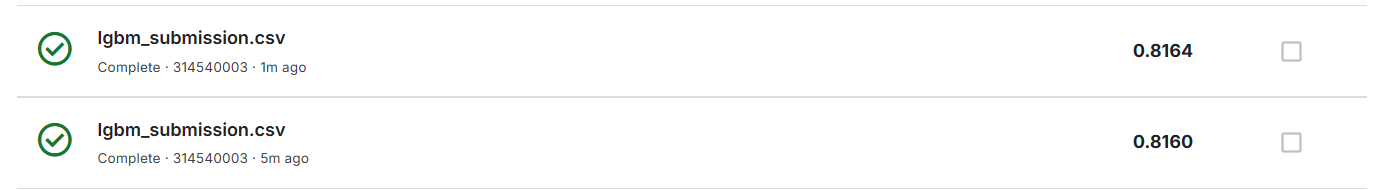

# LightGBM section overview

The LightGBM section implements a tabular replacement for the earlier TFT attempts. Instead of training a sequence model with synthetic decoder rows, it turns each weekly forecast origin into one feature row and trains five direct LightGBM regressors: one each for `pred_week1` through `pred_week5`.

The pipeline is written into `lgbm_drought_pipeline.py` from the `%%writefile` cell. It reloads `train.csv`, `test.csv`, and `sample_submission.csv` directly, parses synthetic dates with string slicing instead of `pd.to_datetime`, verifies region-local row order so it can skip an expensive full sort when safe, builds rolling weather and climatology features, trains a stage-1 nowcast model for recent unlabeled drought state, then trains the five horizon-specific forecast models.

Run order for this section:

1. Install LightGBM.
2. Run the `%%writefile lgbm_drought_pipeline.py` cell to materialize the current script.
3. Run the smoke-test cell first; it writes `lgbm_outputs/smoke/lgbm_submission_smoke.csv` and logs to `logs/lgbm_smoke_latest.log`.
4. Run the full-training cell; it writes models, feature importances, validation outputs, logs to `logs/lgbm_full_latest.log`, and final predictions to `lgbm_outputs/lgbm_submission.csv`.
5. Run the inspection cell to verify submission shape, prediction ranges, and validation MAE by horizon.

Important caveat: the first public score from this LightGBM setup was substantially better than the TFT submissions, but internal rolling validation was still too optimistic. A likely remaining mismatch is that the public test forecast origin can be many weeks after the last known training score for a region, while the current lag features and validation simulation still lean heavily on recent known-score proxies. Future improvements should make the score-lag and validation logic gap-aware before spending much effort on hyperparameter tuning.
